In [29]:
from escripts import edata, eMCMC, eplots
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import math
from matplotlib.ticker import MultipleLocator
from matplotlib.transforms import Bbox
from collections import OrderedDict
mpl.style.use(('/Users/eb35267/Desktop/code/mpl_style/pres_style.mplstyle', '/Users/eb35267/Desktop/code/mpl_style/estyle.mplstyle'))
import zeus21
import scipy
import corner
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D

In [3]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['HST data, Bouwens+21', 'JWST data, Donnan+24', r'Donnan+24 ultra high-$z$']
sorted_data = edata.get_sorted(file_names, data_labels)

In [210]:
params = eMCMC.build_param_data({'beta': {'fit': False, 'value': -1.49}, 'dbetadz':{'fit': False, 'value': 0.22}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [211]:
just_HST = [0.48, -0.04, 11.72, -0.03, -1.38, -0.13, 0.07, -0.14, -0.25, 0.68]

In [212]:
def age_of_universe(z, H0=70.0, Omega_m=0.3):
    """
    Age of the universe at redshift z in Gyr (flat LCDM).
    
    Parameters
    ----------
    z : float or array
    H0 : float
        Hubble constant in km/s/Mpc
    Omega_m : float
        Matter density parameter (Omega_L = 1 - Omega_m)
    """
    Omega_L = 1.0 - Omega_m
    
    # H0 in s^-1
    H0_si = H0 * (1e3) / (3.085677581e22)
    
    # Prefactor in seconds
    t0 = 2.0 / (3.0 * H0_si * np.sqrt(Omega_L))
    
    a = 1.0 / (1.0 + z)
    
    # Analytic solution
    arg = np.sqrt(Omega_L / Omega_m) * a**(3/2)
    t = t0 * np.arcsinh(arg)
    
    # convert to Gyr
    return t / (3600 * 24 * 365.25 * 1e9)

In [270]:
def evolving_UVLF_fit(my_UVLF, backend_file = None, z_plot = None, z_errs = None, plot_from_chain = True, nsamples = 100, 
                      
                      comparison_fits = [], comparison_labels = [], 
                      ncols = 3, burn_in = None, show_chi2 = True, data_fmt = None, fit_colors = None):
    """
    Plot the UVLF at different redshifts
    Inputs:
        my_UVLF: eMCMC UVLF object
        backend_file [str]: .h5 file containing previously saved chain
        z_plot [list of floats]: redshifts to plot, or None if you want to plot all the redshifts for which there exists data
        z_errs [list of floats]: the uncertainty in redshift, or None if you want to use the uncertainty that corresponds to the data.
                                If you provide redshifts to plot but no redshift error, it will default to 0.5.
        plot_from_chain [bool]: whether or not to plot the best fit and samples from the chain stored in my_UVLF. If False, only comparison_fits
                             parameter values will be plotted (so you can quickly check different fits this way).
        nsamples [int]: number of samples from the MCMC chain you want to appear in addition to the best fit
        comparison_fits [list of lists]: lists of parameter values that will be used to create comparison UVLFs
        comparison_labels [list of strs]: labels that correspond to the parameter values in comparison_fits, for the legend
        ncols [int]: number of columns to plot
        burn_in [int]: number of samples to discard as burnin. If None, the default value will be used (see UVLF.get_fit())
        show_chi2 [bool]: whether or not to show the chi squared of the fit(s). Does not apply if plot_from_chain is True
        data_fmt [list]: list of scatter plot styles
        fit_colors [list]: list of colors for the different models
    Outputs:
        Figure showing the UVLF at different redshfits
    """

    data_z = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the input data

    if z_plot is None:
        z_plot = data_z
        z_errs = [dat[1] for dat in my_UVLF.data]
        dat = my_UVLF.data
    else:
        if z_errs is None:
            z_errs = np.full_like(z_plot, 0.5, dtype = float)
        if type(z_plot) == list:
            z_plot = np.array(z_plot)
        if type(z_errs) == list:
            z_errs = np.array(z_errs)

        idxs = np.concatenate([np.where(np.abs(data_z - z) < z_err)[0] for z, z_err in zip(z_plot, z_errs)])
        dat = [my_UVLF.data[i] for i in idxs]
    

    if len(comparison_fits) > 0:
        assert len(comparison_labels) > 0, 'If specifying comparison fits you must also give their labels'

    # Figure out how many subplots to make
    nz = len(z_plot)
    fig = plt.figure()
    gs = GridSpec(math.ceil((nz+1)/ncols), ncols, figure=fig)
    plt.subplots_adjust(wspace = 0.2, hspace = 0.7)
    
   
    # Get samples & best fit
    if plot_from_chain:
        samples, best_fit, _, _= my_UVLF.get_fit(backend_file = backend_file, exclude_unfit = True, burn_in = burn_in)
        print(best_fit)
    
    chi2_comparison = [-2*my_UVLF.log_like(fit, dat) for fit in comparison_fits]

    # Set the same y limits for all the plots
    # Flatten all ydat values from sorted_data
    all_ydat = np.concatenate([np.concatenate([ds[3] for ds in z_separated])  # ds[3] is ydat
                               for z_separated in my_UVLF.sorted_data])
    

    ylo, yhi = np.log10(all_ydat.min()) - 1, np.log10(all_ydat.max()+0.1)


    # Flatten all xdat and xerr across all redshifts and datasets
    MUVcenters, MUVwidths = my_UVLF.get_all_MUV_bins()

    # Plotting details
    if data_fmt is None:
        data_fmt = ['o','s', 'D', '^', 'P']
    if fit_colors is None:
        fit_colors = [turquoise, yellow, orange, green]

    axs = []
    for i, (z, z_err) in enumerate(zip(z_plot, z_errs)): 

        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)

        if plot_from_chain:
            # Choose random samples from the MCMC chain
            inds = np.random.randint(len(samples), size=nsamples) # Choose nsamples from the chain

            # Plot each sample from the chain
            for ind in inds: 
                sample = samples[ind]
                ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err, MUVcenters, MUVwidths,sample)), alpha=6/max(nsamples, 6), 
                           color = red, linestyle = '-', zorder = 0)
    
            # Plot best fit
            chi2 = -2* my_UVLF.log_like(best_fit, alt_data = dat)

            ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z, z_err, MUVcenters, MUVwidths, best_fit)), color = red, linestyle = '-', 
                                           zorder = 0, label = fr'best fit, $\chi^2 = {chi2:.0f}$')
            
            ax.plot([0], [0], color = red, alpha = 0.1, label = f'{nsamples} samples from chain', linestyle = '-') # Create the label for the samples

        # Plot comparison fits
        for fit, chi2_fit, label, color, ls in zip(comparison_fits, chi2_comparison, comparison_labels, fit_colors, 
                                        ['solid', 'dashdot', 'dashed', 'dotted', 'solid']):
            if show_chi2:
                fit_label = fr'{label}, $\chi^2 = {chi2_fit:.0f}$'
            else:
                fit_label = f'{label}'
            ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err,MUVcenters, MUVwidths,fit)), color = color, 
                       label = fit_label, linestyle = ls, zorder = 1)
        
        # Plot data
        all_dat_z = [dat[0][0] for dat in my_UVLF.sorted_data]
        idx = np.where(np.abs(all_dat_z - z) <= z_err)[0]
        if len(idx) > 0:
            for zbin in [my_UVLF.sorted_data[idx_i] for idx_i in idx]:
            #zbin = my_UVLF.sorted_data[idx[0]]

                for dat_z, fmt in zip(zbin, data_fmt): 
                    xdat, ydat, yerr_upper, yerr_lower, xerr, upper_lim_bool = dat_z[2], dat_z[3], dat_z[4], dat_z[5], dat_z[6], dat_z[7].astype('bool')
                    ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)
                    
                    # Show upper limits with a unique plotting style
                    for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                        ax.vlines(x, np.log10(y)-0.75, np.log10(y), ls = '-', colors = eplots.navy, linewidth = 5, alpha = 0.5)
                        ax.scatter(x-0.015, np.log10(y)-0.75, marker = 'v', c = eplots.navy, s = 65) # down arrow

                    if dat_z[-1]: # This indicates whether the data was used in the MCMC likelihood or not
                        for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)
                        for x, y in zip(xdat[np.invert(upper_lim_bool)], ydat[np.invert(upper_lim_bool)]): # Account for the fact that upper limits cannot currently be included in the MCMC likelihood
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], c = eplots.navy, s = 400)
                    else: 
                        ax.scatter(xdat, np.log10(ydat), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)

        ax.invert_xaxis() 

        ax.xaxis.set_major_locator(MultipleLocator(2))         
        ax.yaxis.set_major_locator(MultipleLocator(2))                                                                
        
        ax.set_title(fr'$z \simeq {z}$, $t \simeq {int(round(age_of_universe(z)*1000, -1))}$ Myr', pad = 9, fontsize = 40)


    # Text & labels
    ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
    xlabel = r'$M_{\rm{UV}}$ [mag]'

    # Formatting, labels
    multicol(gs, axs, xlabel, ylabel, xlims = (np.max(MUVcenters)+0.25, np.min(MUVcenters)-0.25), ylims = (ylo, yhi), include_legend = True)
    
    return fig

In [267]:
def multicol(gs, axs, xlabel = '', ylabel = '', xlims = None, ylims = None, include_legend = False):
    """
    Helper function for formatting multi-column plots.
    
    :param gs: matplotlib GridSpec object
    :param axs: list of axes in the figure
    :param xlabel: x axis label text
    :param ylabel: y axis label text
    :param xlims: tuple with the upper and lower x limit to be imposed for each subplot
    :param ylims: tuple with the upper and lower y limit to be imposed for each subplot. 
    :param include_legend: boolean-- whether or not to include a legend. Relies on there being labels in the axes within axs
    """
    
    N = len(axs)
    if include_legend:
        N_inc_leg = N+1
    else:
        N_inc_leg = N

    # Sizing & spacing
    fig = gs.figure
    fig.set_size_inches(18, 10)

    # Formatting axis ticks
    for i, ax in enumerate(axs): 
        if xlims is not None:
            ax.set_xlim(*xlims)
        if ylims is not None:
            ax.set_ylim(*ylims)                                                                       
            if i%gs.ncols != 0:
                ax.axes.yaxis.set_ticklabels([]) # Only include y axis tick labels on the furthest left side if all axes will have the same y limits

    # Text & labels
    bbox = Bbox.union([ax.get_position() for ax in axs]) # Define the positions of all the axes
    xcenter = bbox.x0 + bbox.width / 2
    ycenter = bbox.y0 + bbox.height / 2
    fig.text(xcenter, bbox.y0 - gs.ncols*0.02 , xlabel, ha='center', va='top', fontsize = 40)
    fig.text(bbox.x0 - 0.1 + (gs.ncols/75), ycenter, ylabel, ha='center', va='center', rotation='vertical', fontsize = 40)

    # Create legend & place it outside the axes
    if include_legend:
        legend = OrderedDict() # Avoids duplicates & ensures that the legend is in order of what people will see first
        for ax in axs:
            for h, l in zip(*ax.get_legend_handles_labels()):
                legend.setdefault(l, h)
        handles, labels = list(legend.values()), list(legend.keys())

        # Placement
        fig_ax = fig.add_subplot(gs[math.floor((N)/gs.ncols), (N)%gs.ncols])
        fig_ax.axis("off")  
        fig_ax.legend(handles, labels, loc=(0.1, 0.5))
    
    

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_34842/712305914.py:123: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_34842/712305914.py:123: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)


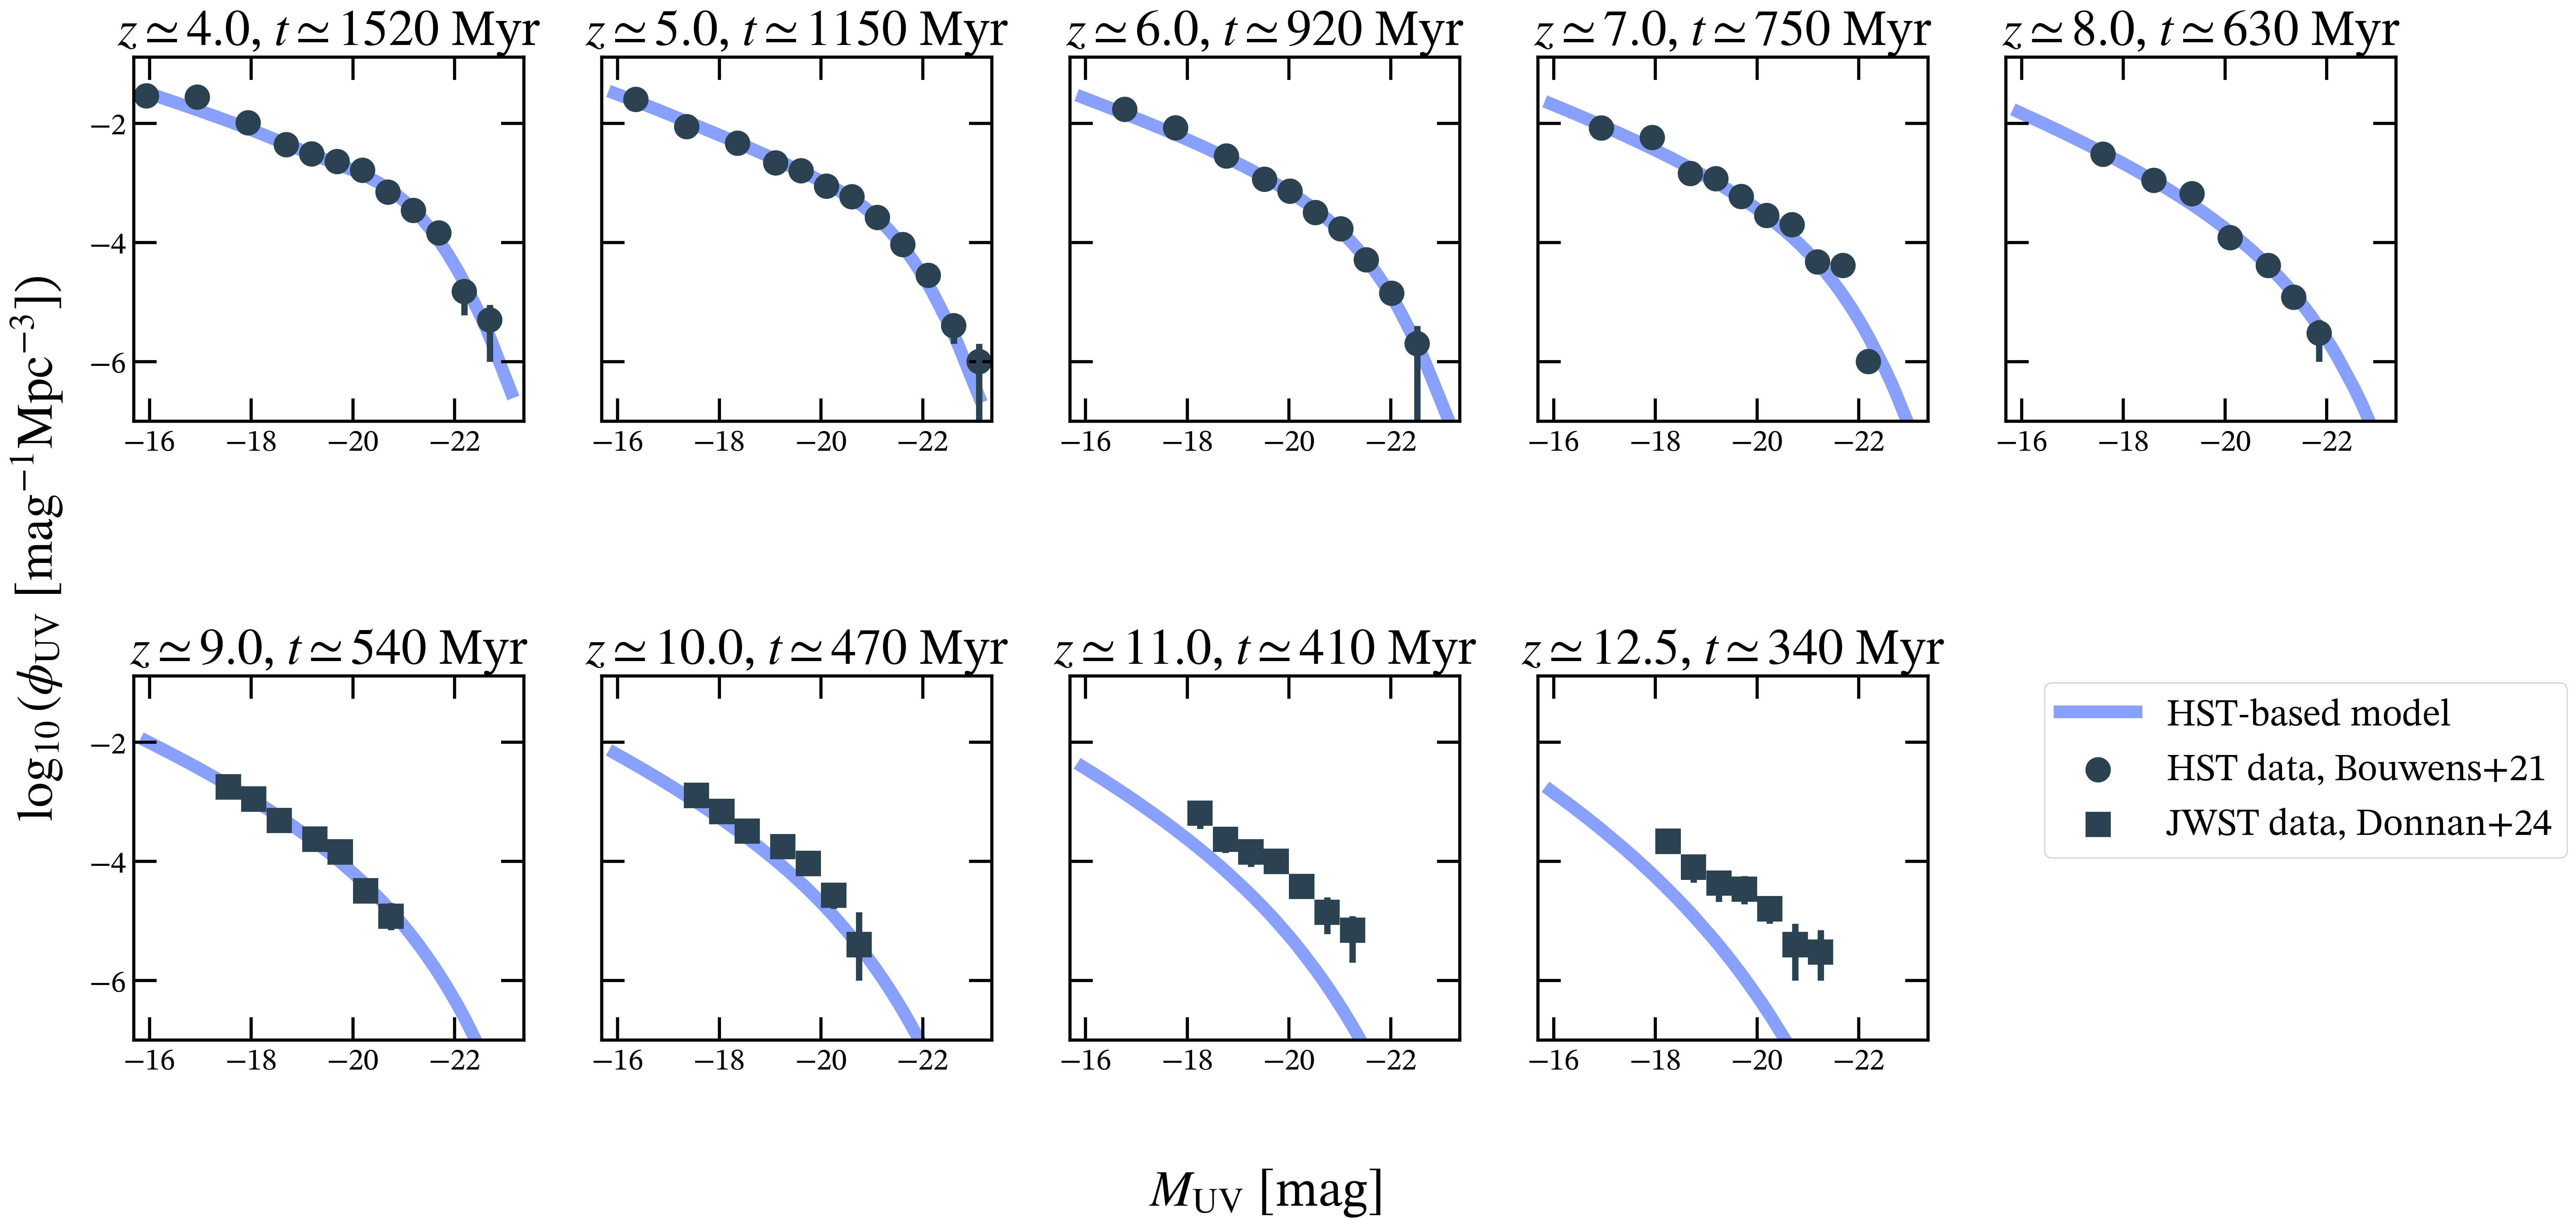

In [278]:
HST_vs_JWST = evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [just_HST], 
                                comparison_labels = [r'HST-based model'], ncols = 5, 
                                fit_colors = [eplots.periwinkle],z_plot = [4, 5, 6, 7, 8, 9, 10, 11, 12.5], show_chi2 = False)

HST_vs_JWST.set_size_inches(32, 14)
    
# HST_vs_JWST.savefig(f'/Users/eb35267/Desktop/figures/Qual_26/Talk/JWST_UVLF.png', dpi = 300)

In [279]:
HST_vs_JWST.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/all_UVLF.png', dpi = 300)

In [162]:
FIRE_bursty = np.array([0.21875000000000044, -1.9725675675675678,
0.31250000000000044, -1.4859290540540533,
0.40625000000000044, -1.3236148648648642,
0.5000000000000004, -0.820760135135135,
0.5937500000000004, -0.7557432432432432,
0.7187500000000004, -1.1122972972972978,
0.8125000000000004, -0.7067398648648653,
0.9062500000000004, -0.9336148648648646,
1.0625000000000004, -0.7063344594594598,
1.0937500000000004, -0.4306081081081077,
1.2187500000000004, -0.625,
1.3125000000000004, -0.3816047297297298,
1.40625, -0.39766891891891865,
1.5, -0.31643581081081074,
1.59375, -0.0892567567567566,
1.65625, -0.33239864864864854,
1.71875, -0.5268918918918919,
1.8125, -0.34836148648648635,
1.875, 0.12201013513513503,
1.90625, 0.4788175675675679,
2, -0.12103040540540544,
2.09375, 0.07371621621621616,
2.1875, 0.1549493243243245,
2.3125, 0.39839527027027,
2.40625, 0.17152027027027028,
2.5, 0.6095101351351357,
2.59375, 0.7393918918918923,
2.6875, -0.39559121621621607,
2.8125, 0.3181250000000002,
2.90625, 0.13989864864864865,
3.03125, 0.25361486486486484,
3.09375, 0.38344594594594605,
3.21875, 0.23770270270270233,
3.3125, 0.7243412162162164,
3.40625, 0.059628378378378866,
3.5, 0.17329391891891888,
3.59375, 0.38425675675675697,
3.71875, 0.15743243243243255,
3.8125, 0.2873141891891895,
3.875, 0.3522804054054056,
4, 0.38491554054054067,
4.09375, 0.36885135135135094,
4.21875, 0.40148648648648644,
4.3125, 0.7259628378378378,
4.5, 0.09383445945946,
4.59375, 0.4669594594594595,
4.71875, 0.48337837837837894,
4.78125, 0.48347972972972997,
4.90625, 0.9863851351351354,
5, 0.09464527027027048,
5.09375, 0.7758783783783789,
5.187499999999999, 0.3057601351351349,
5.312499999999999, 0.8735304054054058,
5.406249999999999, -0.09929054054054065,
5.499999999999999, 0.6630236486486489,
5.593749999999999, -0.2935810810810806,
5.812499999999999, 0.5662331081081082,
5.906249999999999, 0.6798986486486487,
5.999999999999999, -0.09832770270270252,
6.093749999999999, 0.5180405405405404,
6.218749999999999, 0.5668918918918919,
6.312499999999999, 0.9238006756756758,
6.406249999999999, 0.5023310810810808,
6.499999999999999, 0.6159966216216222,
6.593749999999999, 0.22695945945945972,
6.687499999999999, 0.4703547297297299,
6.781249999999999, 0.4218581081081081,
6.906249999999999, 0.40584459459459454,
6.968749999999999, 0.7140540540540541,
7.093749999999999, 0.7629054054054056,
7.187499999999999, 0.3252195945945946,
7.281249999999999, 0.6496959459459464,
7.406249999999999, 0.3093581081081078,
7.499999999999999, 0.877077702702703,
7.593749999999999, 0.06641891891891927,
7.687499999999999, 0.601706081081081,
7.812499999999999, 0.4559628378378382,
7.968749999999999, 0.9102702702702707,
8.09375, 0.16452702702702693,
8.21875, 0.9917567567567569,
8.281249999999996, 0.3107770270270267,
8.406249999999996, 0.31097972972972965,
8.5, 0.6841047297297296,
8.59375, 0.4247972972972973,
8.6875, 0.6033277027027029,
8.781249999999996, 0.7332094594594594,
8.906249999999996, 0.4577364864864868,
9, 0.5551858108108108,
9.09375, 0.7499324324324328,
9.1875, 1.009543918918919,
9.281249999999996, 0.620506756756757,
9.406249999999996, 0.5071959459459454,
9.5, 0.8154560810810811,
9.59375, 0.6534459459459465,
9.6875, 0.9779222972972974,
9.781249999999996, 0.5888851351351354,
9.906249999999996, 0.670168918918919,
10, 0.24869932432432407,
10.0625, 0.6866385135135133,
10.09375, 0.9461486486486486,
10.281249999999996, 0.3140202702702699,
10.406249999999996, 0.7520608108108111,
10.5, 0.6549155405405407,
10.59375, 0.7361486486486486,
10.6875, 0.42819256756756774,
10.781249999999996, 0.8337500000000002,
10.875, 0.7366047297297298,
11, 0.7530236486486488,
11.09375, 0.8018243243243246,
11.1875, 0.6884628378378377,
11.281249999999996, 0.8183445945945946,
11.375, 0.8347128378378379,
11.46875, 0.77,
11.59375, 0.7702027027027025,
11.6875, 0.8514358108108109,
11.781249999999996, 0.7380743243243244,
11.906249999999996, 0.7707094594594595,
11.96875, 0.8518918918918921,
12.125, 0.7872804054054057,
12.1875, 0.8035979729729732,
12.3125, 0.7713682432432432,
12.4375, 0.7715709459459461,
12.59375, 0.8042567567567569,
12.6875, 0.7557601351351355,
12.781249999999996, 0.7883445945945948,
12.874999999999996, 0.7560641891891895,
13.062499999999996, 0.740152027027027,
13.187499999999996, 0.772787162162162,
13.312499999999996, 0.7243412162162164,
13.406249999999996, 0.6758445945945946,
13.437499999999996, 0.7083277027027028]).reshape(-1,2)

Illustris = np.array([0.3335033146353905, -1.9729729729729728,
0.36681964983851856, -1.794594594594595,
0.46591874893761753, -1.3405405405405402,
0.49957504674485875, -1.1297297297297293,
0.5962944076151633, -0.9027027027027028,
0.6612272650008508, -0.7081081081081084,
0.9167091619921814, -0.33513513513513526,
1.1069182389937113, -0.18918918918918948,
1.518612952575217, 0.08648648648648649,
2.118816930137685, 0.34594594594594597,
2.2447730749617545, 0.362162162162162,
2.3081761006289305, 0.4108108108108106,
2.9070202277749457, 0.5405405405405403,
3.2218255991840907, 0.5729729729729729,
3.410674825769166, 0.5891891891891889,
3.6624171341152483, 0.6054054054054054,
3.8512663607003237, 0.6216216216216215,
3.9144994050654436, 0.654054054054054,
4.008499065102838, 0.6216216216216215,
4.102838687744349, 0.6216216216216215,
4.197348291687915, 0.6378378378378375,
4.323134455209927, 0.6378378378378375,
4.669046404895463, 0.6378378378378375,
4.889172191058984, 0.6378378378378375,
5.172191058983513, 0.6378378378378375,
5.423763386027537, 0.6378378378378375,
5.612612612612613, 0.654054054054054,
5.832568417474079, 0.6378378378378375,
5.927078021417644, 0.654054054054054,
6.021247662757098, 0.6378378378378375,
6.115757266700664, 0.654054054054054,
6.209926908040117, 0.6378378378378375,
6.335883052864185, 0.654054054054054,
6.870134285228625, 0.6216216216216215,
7.058813530511644, 0.6216216216216215,
7.341662417134117, 0.6054054054054054,
7.436172021077681, 0.6216216216216215,
7.530341662417134, 0.6054054054054054,
7.687744348121706, 0.6216216216216215,
7.8135305116437195, 0.6216216216216215,
7.907870134285227, 0.6216216216216215,
8.065102838687745, 0.6216216216216215,
8.159272480027196, 0.6054054054054054,
8.28505864354921, 0.6054054054054054,
8.379568247492776, 0.6216216216216215,
8.505184429712733, 0.6054054054054054,
8.6311405745368, 0.6216216216216215,
8.725310215876254, 0.6054054054054054,
8.88254292027877, 0.6054054054054054,
9.102498725140237, 0.5891891891891889,
9.385517593064764, 0.5891891891891889,
9.7314295427503, 0.5891891891891889,
10.171851096379399, 0.6054054054054054,
10.234404215536292, 0.5729729729729729,
10.29763725990141, 0.6054054054054054,
10.454530001699814, 0.5729729729729729,
10.674655787863335, 0.5729729729729729,
10.863505014448412, 0.5891891891891889,
10.989121196668368, 0.5729729729729729,
11.11490736019038, 0.5729729729729729,
11.30341662417134, 0.5567567567567564,
11.554988951215366, 0.5567567567567564,
11.64915859255482, 0.5405405405405403,
11.743668196498387, 0.5567567567567564,
11.837837837837839, 0.5405405405405403,
12.278089410164881, 0.5405405405405403,
12.498215196328404, 0.5405405405405403,
12.718340982491927, 0.5405405405405403,
12.875403705592387, 0.5243243243243239,
13.22131565527792, 0.5243243243243239,
13.283868774434811, 0.4918918918918913,
13.31565527791943, 0.5243243243243239,
13.598334183239842, 0.4918918918918913]).reshape(-1,2)

Text(0.975, 0.05, '$M_{\\star} \\approx 10^{10.5}\\rm{M}_{\\odot}$ at $z = 0$')

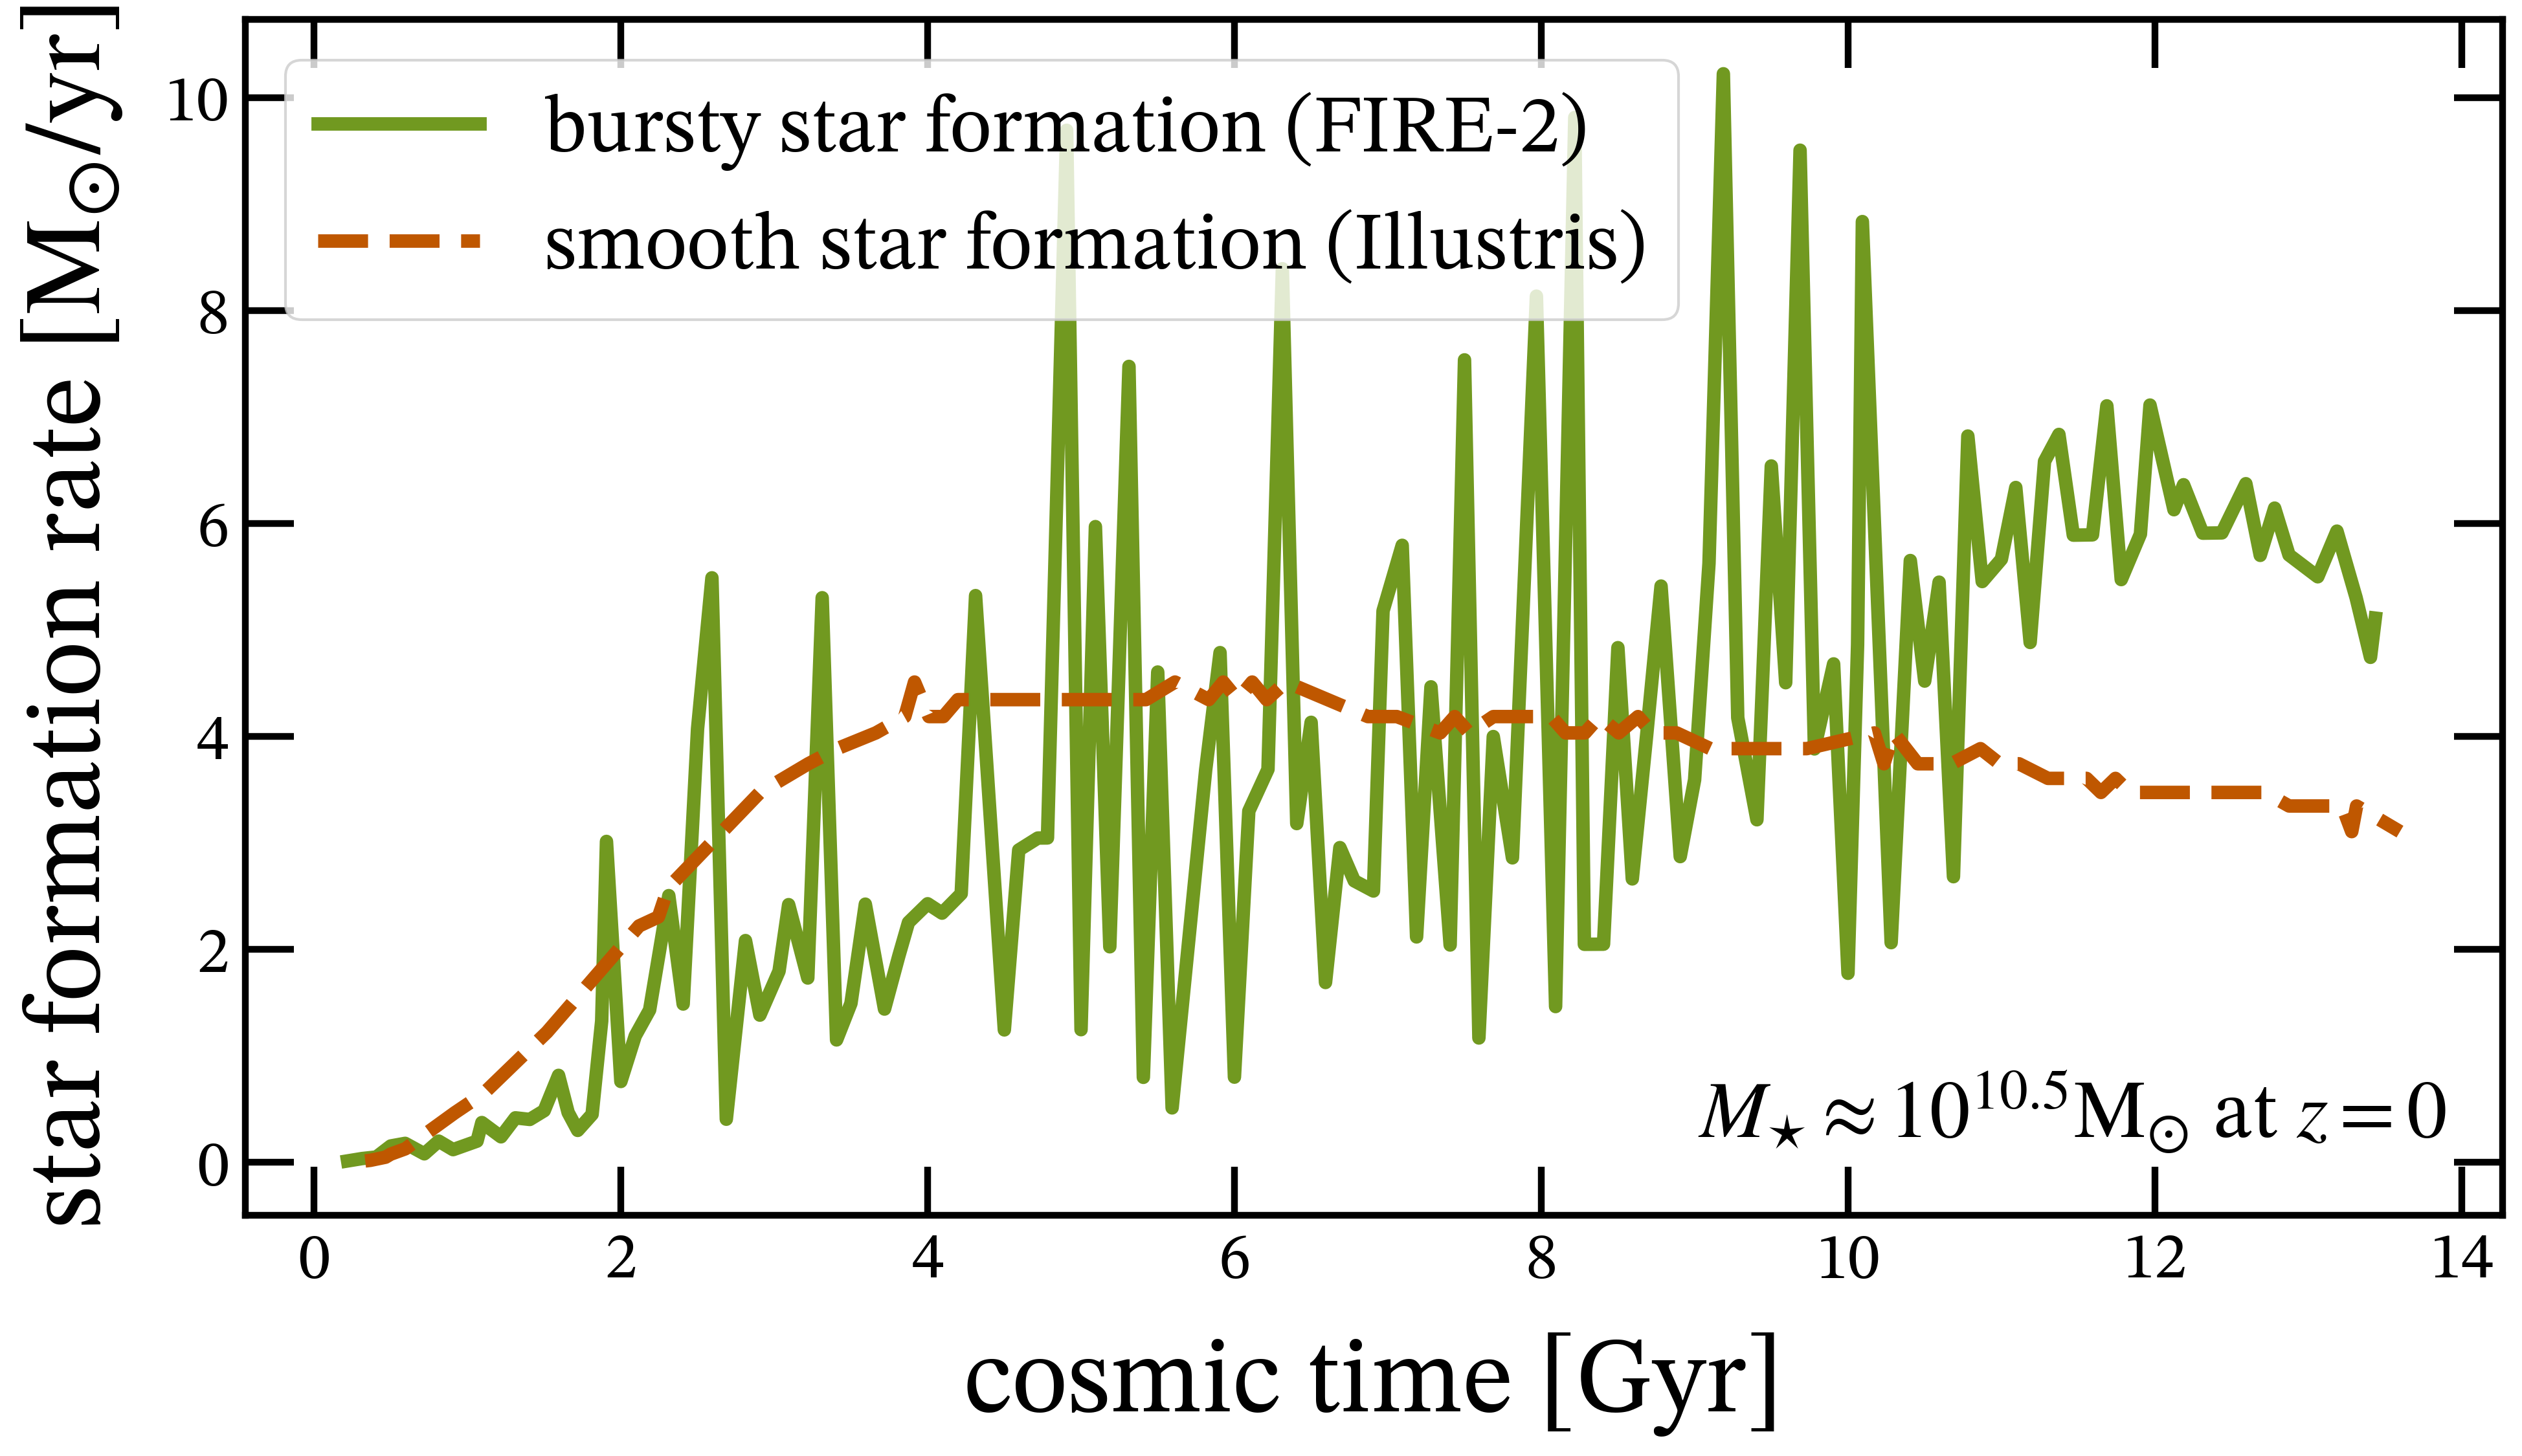

In [168]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 8)
ax.plot(FIRE_bursty[:,0], 10**FIRE_bursty[:,1], label = 'bursty star formation (FIRE-2)', color = eplots.green, 
        lw = 5)
ax.plot(Illustris[:,0], 10**Illustris[:,1], label = 'smooth star formation (Illustris)', color = '#bf5700', 
        lw = 5)
ax.legend(loc = 'upper left')
ax.set_ylabel(r'star formation rate [$\rm{M}_{\odot} / \rm{yr}$]')
ax.set_xlabel('cosmic time [Gyr]')
plt.text(0.975, 0.05, r'$M_{\star} \approx 10^{10.5}\rm{M}_{\odot}$ at $z = 0$', transform=plt.gca().transAxes, verticalalignment='bottom', 
         horizontalalignment='right')

In [169]:
fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/burstySF.png', dpi = 300)

In [192]:
params = eMCMC.build_param_data({})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [193]:
my_UVLF.param_data

,fit,value,lower,upper,label
alpha,True,0.6,0,2.5,$\alpha$
dalphadz,True,0,-0.5,0.5,$d\alpha/dz$
beta,True,-0.5,-2,0,$\beta$
dbetadz,True,0,-0.5,0.5,$d\beta/dz$
logMc,True,12,10,14,$\log(M_c)$
dlogMcdz,True,0,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-3,0,$\log(\epsilon_{\star})$
dlogedz,True,0,-0.5,0.5,$d\log(\epsilon_{\star})/dz$
sig,True,0,0,5,"$\sigma_{\rm{UV}, M_c}$"
dsigdz,True,0,-0.75,1,$d\sigma_{\rm{UV}}/dz$


In [194]:
def sfe_shape_diff_z(my_UVLF, param_values, Mhtab, z):

    fig = plt.figure(figsize=(12, 8))
    ax_rect  = [0.10, 0.12, 0.78, 0.80]       # left, bottom, width, height (0-1)
    ax = fig.add_axes(ax_rect)
    
    # Calculate parameters at this z
    params = my_UVLF.time_evolution(param_values, z)
    Astro_Parameters = my_UVLF.param_wrapper(params)
    # Calculate SFE
    SFEs = my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB * zeus21.sfrd.fstarofz(
        Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mhtab)
    ax.axvline(Mhtab[np.where(SFEs == max(SFEs))[0]], color = eplots.navy, lw = 7, ls = 'dashed')
    ax.axhline(max(SFEs)+0.0003, color = eplots.navy, ls='dashed', lw = 7)
    plt.plot(Mhtab, SFEs, color = eplots.yellow, ls = '-', zorder = 0)

    lm_fit, _ = scipy.optimize.curve_fit(f, Mhtab[10:50], SFEs[10:50])
    a, b = lm_fit
    ax.plot(Mhtab[10:50], f(Mhtab[10:50], a + 0.005, b), lw = 7, ls = 'dashed', color = eplots.navy)

    hm_fit, _ = scipy.optimize.curve_fit(f, Mhtab[175:], SFEs[175:])
    a, b = hm_fit
    ax.plot(Mhtab[175:], f(Mhtab[175:], a + 0.005, b), lw = 7, ls = 'dashed', color = eplots.navy)

    # Labels
    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$f_{\star} = \dot M_\star / \dot M_{\rm{gas}}$')
    ax.set_yscale('log')
        
        
    return fig, ax

def f(x, a, b):
    return 10**((a*x)+b)

In [195]:
vanilla_model = [0.5, 0.01, -0.4, 0, 12, 0.1, -1.8, 0.1, 0.3, 0, 0, 0.3]

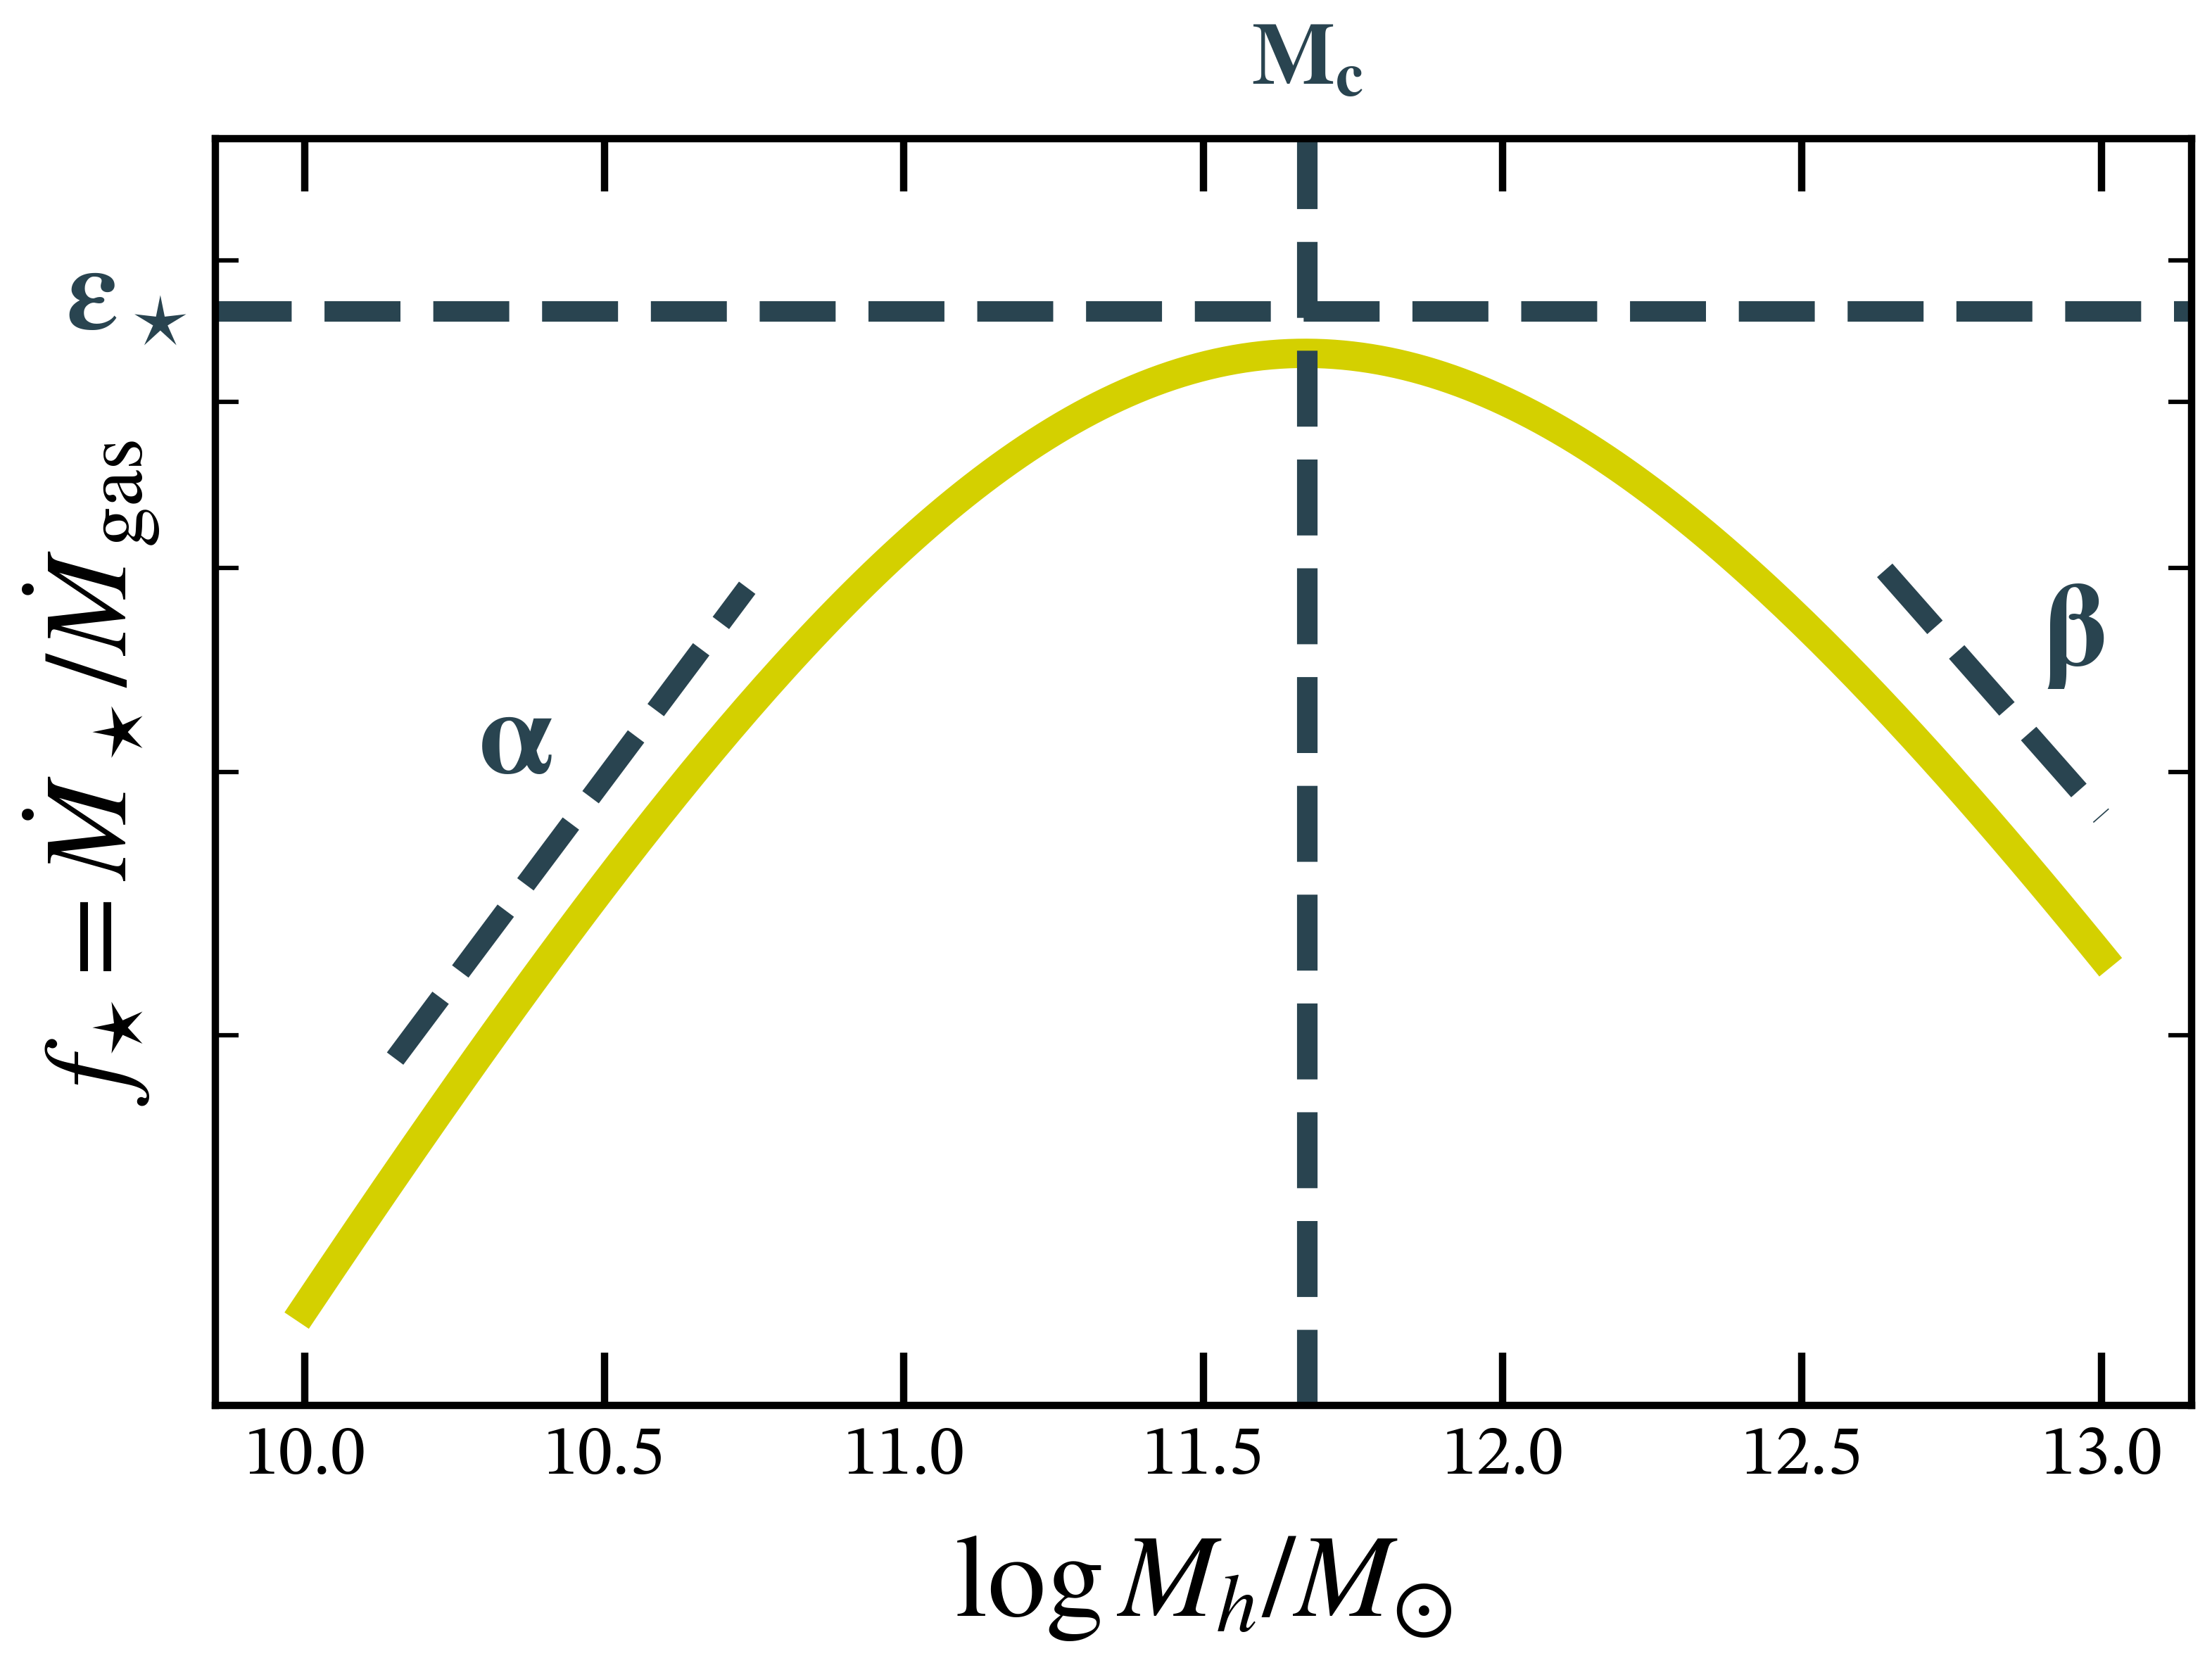

In [207]:
sfe_fig, ax = sfe_shape_diff_z(my_UVLF, vanilla_model, Mhtab = np.linspace(10, 13, 200),
                             z = 4)
ax.set_ylim(2e-3, 8e-3)
ax.text(10.29, 4e-3, r'$\mathbf{\alpha}$', color = eplots.navy, fontsize = 40)
ax.text(9.6, 6.5e-3, r'$\mathbf{\epsilon}_\star$', color = eplots.navy, fontsize = 40)
ax.text(12.9, 4.5e-3, r'$\mathbf{\beta}$', color = eplots.navy, fontsize = 40)
ax.text(11.58, 8.5e-3, r'$\mathbf{M_c}$', color = eplots.navy)

sfe_fig.set_size_inches(12, 7.5)


In [208]:
sfe_fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/sfe_all.png', dpi = 300)

In [366]:
params = eMCMC.build_param_data({'beta': {'fit': False, 'value': -1.49}, 'dbetadz':{'fit': False, 'value': 0.22}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [371]:
mass_dependent = [0.818, -0.032, 11.995, 0.05, -1.373, -0.138, 0.992,
0, -0.796, 0.677]

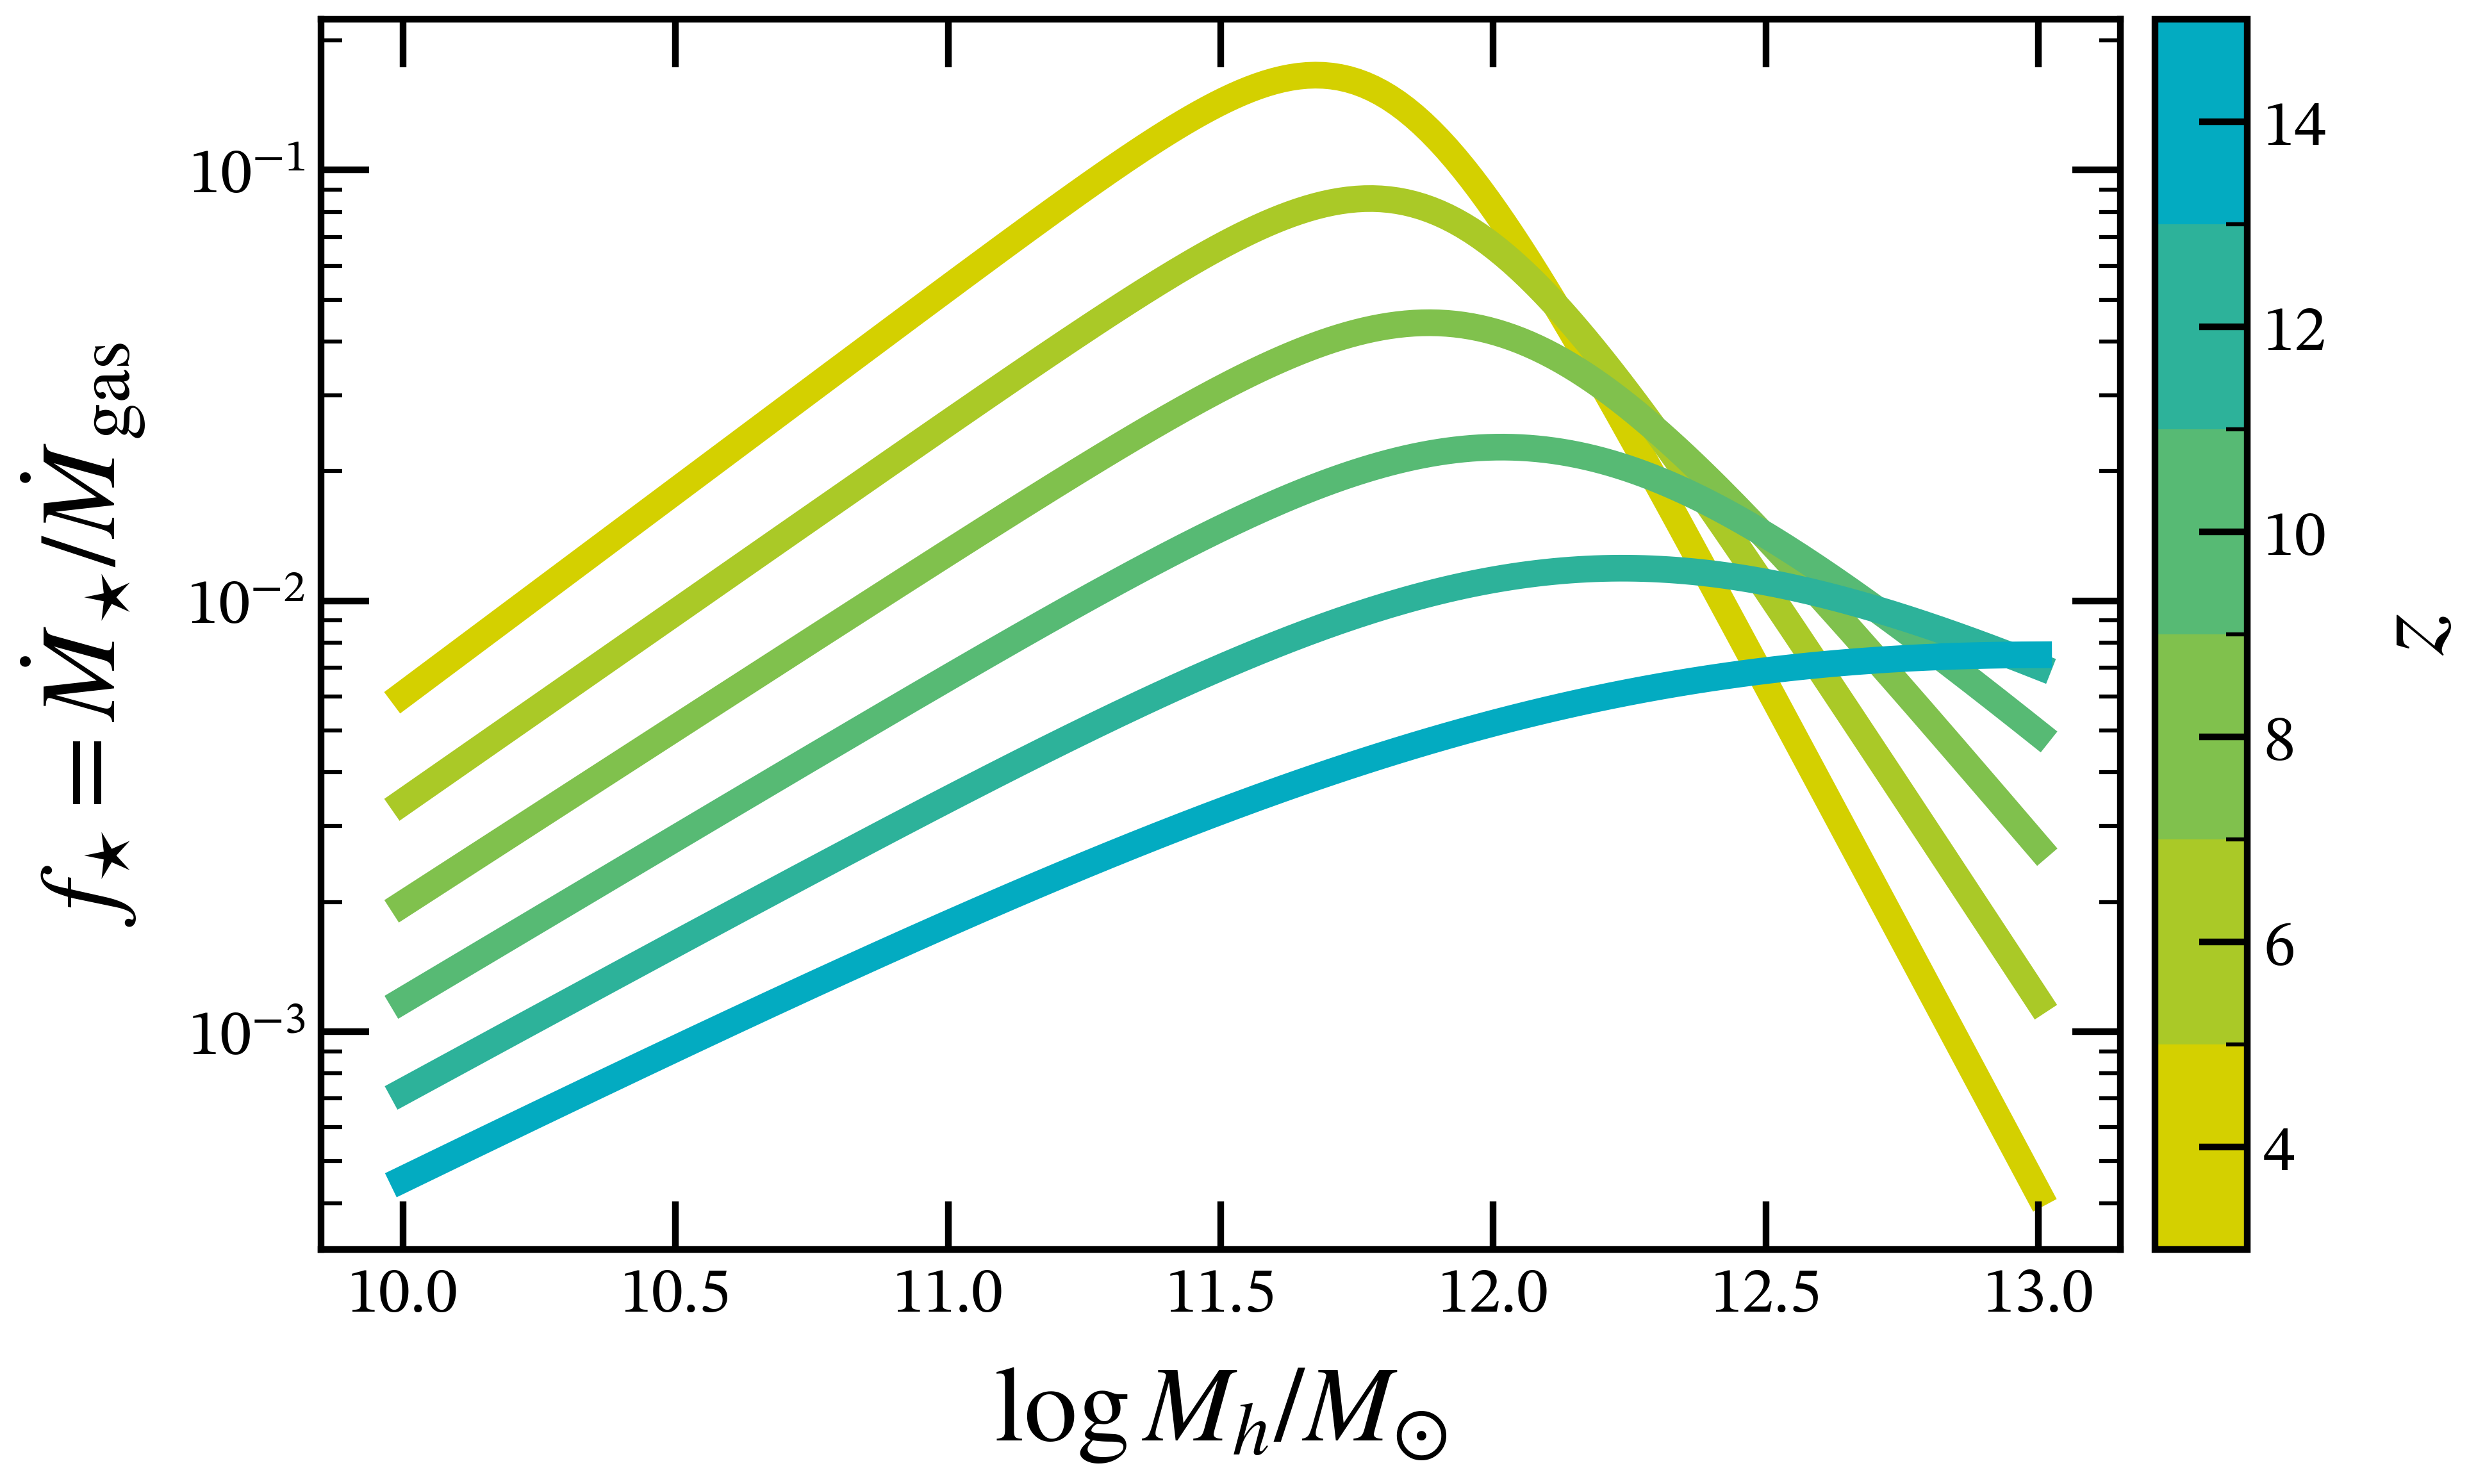

In [372]:
sfe_over_time, ax = eplots.sfe_shape_diff_z(my_UVLF, mass_dependent, Mhtab = np.linspace(10, 13, 200))
sfe_over_time.set_size_inches(12, 8)

In [373]:
sfe_over_time.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/sfe_over_time.png', dpi = 300)

In [20]:
low_sigma = [0.54, 0.02, 12, -0.07, -1.01, -0.05, 0.3, 0, 0, 0.3]

In [6]:
params = eMCMC.build_param_data({'beta': {'fit': False, 'value': -1.49}, 'dbetadz':{'fit': False, 'value': 0.22}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [87]:
def evolving_UVLF_fit(my_UVLF, backend_file = None, z_plot = None, z_errs = None, plot_from_chain = True, nsamples = 100, 
                      
                      comparison_fits = [], comparison_labels = [], 
                      ncols = 3, burn_in = None, show_chi2 = True, data_fmt = None, fit_colors = None):
    """
    Plot the UVLF at different redshifts
    Inputs:
        my_UVLF: eMCMC UVLF object
        backend_file [str]: .h5 file containing previously saved chain
        z_plot [list of floats]: redshifts to plot, or None if you want to plot all the redshifts for which there exists data
        z_errs [list of floats]: the uncertainty in redshift, or None if you want to use the uncertainty that corresponds to the data.
                                If you provide redshifts to plot but no redshift error, it will default to 0.5.
        plot_from_chain [bool]: whether or not to plot the best fit and samples from the chain stored in my_UVLF. If False, only comparison_fits
                             parameter values will be plotted (so you can quickly check different fits this way).
        nsamples [int]: number of samples from the MCMC chain you want to appear in addition to the best fit
        comparison_fits [list of lists]: lists of parameter values that will be used to create comparison UVLFs
        comparison_labels [list of strs]: labels that correspond to the parameter values in comparison_fits, for the legend
        ncols [int]: number of columns to plot
        burn_in [int]: number of samples to discard as burnin. If None, the default value will be used (see UVLF.get_fit())
        show_chi2 [bool]: whether or not to show the chi squared of the fit(s). Does not apply if plot_from_chain is True
        data_fmt [list]: list of scatter plot styles
        fit_colors [list]: list of colors for the different models
    Outputs:
        Figure showing the UVLF at different redshfits
    """

    data_z = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the input data

    if z_plot is None:
        z_plot = data_z
        z_errs = [dat[1] for dat in my_UVLF.data]
        dat = my_UVLF.data
    else:
        if z_errs is None:
            z_errs = np.full_like(z_plot, 0.5, dtype = float)
        if type(z_plot) == list:
            z_plot = np.array(z_plot)
        if type(z_errs) == list:
            z_errs = np.array(z_errs)

        idxs = np.concatenate([np.where(np.abs(data_z - z) < z_err)[0] for z, z_err in zip(z_plot, z_errs)])
        dat = [my_UVLF.data[i] for i in idxs]
    

    if len(comparison_fits) > 0:
        assert len(comparison_labels) > 0, 'If specifying comparison fits you must also give their labels'

    # Figure out how many subplots to make
    nz = len(z_plot)
    fig = plt.figure()
    gs = GridSpec(math.ceil((nz+1)/ncols), ncols, figure=fig)
    plt.subplots_adjust(wspace = 0.2, hspace = 0.4)
    
   
    # Get samples & best fit
    if plot_from_chain:
        samples, best_fit, _, _= my_UVLF.get_fit(backend_file = backend_file, exclude_unfit = True, burn_in = burn_in)
        print(best_fit)
    
    chi2_comparison = [-2*my_UVLF.log_like(fit, dat) for fit in comparison_fits]

    # Set the same y limits for all the plots
    # Flatten all ydat values from sorted_data
    all_ydat = np.concatenate([np.concatenate([ds[3] for ds in z_separated])  # ds[3] is ydat
                               for z_separated in my_UVLF.sorted_data])
    

    ylo, yhi = np.log10(all_ydat.min()) - 1, np.log10(all_ydat.max()+3)


    # Flatten all xdat and xerr across all redshifts and datasets
    MUVcenters, MUVwidths = my_UVLF.get_all_MUV_bins()

    # Plotting details
    if data_fmt is None:
        data_fmt = ['o','s', 'D', '^', 'P']
    if fit_colors is None:
        fit_colors = [turquoise, yellow, orange, green]

    axs = []
    for i, (z, z_err) in enumerate(zip(z_plot, z_errs)): 

        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)

        if plot_from_chain:
            # Choose random samples from the MCMC chain
            inds = np.random.randint(len(samples), size=nsamples) # Choose nsamples from the chain

            # Plot each sample from the chain
            for ind in inds: 
                sample = samples[ind]
                ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err, MUVcenters, MUVwidths,sample)), alpha=6/max(nsamples, 6), 
                           color = red, linestyle = '-', zorder = 0)
    
            # Plot best fit
            chi2 = -2* my_UVLF.log_like(best_fit, alt_data = dat)

            ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z, z_err, MUVcenters, MUVwidths, best_fit)), color = red, linestyle = '-', 
                                           zorder = 0, label = fr'best fit, $\chi^2 = {chi2:.0f}$')
            
            ax.plot([0], [0], color = red, alpha = 0.1, label = f'{nsamples} samples from chain', linestyle = '-') # Create the label for the samples

        # Plot comparison fits
        for fit, chi2_fit, label, color, ls in zip(comparison_fits, chi2_comparison, comparison_labels, fit_colors, 
                                        ['solid', 'dashdot', 'dashed', 'dotted', 'solid']):
            if show_chi2:
                fit_label = fr'{label}, $\chi^2 = {chi2_fit:.0f}$'
            else:
                fit_label = f'{label}'
            ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err,MUVcenters, MUVwidths,fit)), color = color, 
                       label = fit_label, linestyle = ls, zorder = 1)
        
        # Plot data
        all_dat_z = [dat[0][0] for dat in my_UVLF.sorted_data]
        idx = np.where(np.abs(all_dat_z - z) <= z_err)[0]
        if len(idx) > 0:
            for zbin in [my_UVLF.sorted_data[idx_i] for idx_i in idx]:
            #zbin = my_UVLF.sorted_data[idx[0]]

                for dat_z, fmt in zip(zbin, data_fmt): 
                    xdat, ydat, yerr_upper, yerr_lower, xerr, upper_lim_bool = dat_z[2], dat_z[3], dat_z[4], dat_z[5], dat_z[6], dat_z[7].astype('bool')
                    ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)
                    
                    # Show upper limits with a unique plotting style
                    for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                        ax.vlines(x, np.log10(y)-0.75, np.log10(y), ls = '-', colors = eplots.navy, linewidth = 5, alpha = 0.5)
                        ax.scatter(x-0.015, np.log10(y)-0.75, marker = 'v', c = eplots.navy, s = 65) # down arrow

                    if dat_z[-1]: # This indicates whether the data was used in the MCMC likelihood or not
                        for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)
                        for x, y in zip(xdat[np.invert(upper_lim_bool)], ydat[np.invert(upper_lim_bool)]): # Account for the fact that upper limits cannot currently be included in the MCMC likelihood
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], c = eplots.navy, s = 250)
                    else: 
                        ax.scatter(xdat, np.log10(ydat), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)

        ax.invert_xaxis() 

        ax.xaxis.set_major_locator(MultipleLocator(2))         
        ax.yaxis.set_major_locator(MultipleLocator(2))                                                                
        
        ax.set_title(fr'${round(z-z_err, 1)} \lesssim z \lesssim {round(z+z_err, 1)}$', pad = 8)


    # Text & labels
    ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
    xlabel = r'$M_{\rm{UV}}$ [mag]'

    # Formatting, labels
    multicol(gs, axs, xlabel, ylabel, xlims = (np.max(MUVcenters)+0.25, np.min(MUVcenters)-0.25), ylims = (ylo, yhi), include_legend = True)
    
    return fig

In [255]:
low_sigma_plot = evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [low_sigma], 
                               comparison_labels = [r'Low stochasticity model'], ncols = 4, 
                               fit_colors = [eplots.periwinkle],z_plot = [10, 11, 12.5], show_chi2 = False)

low_sigma_plot.set_size_inches(27, 6)


for ax in low_sigma_plot.axes:
    ax.set_ylim(-6, -2.5)
    ax.set_xlim(-17, -21)
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(MultipleLocator(1))

NameError: name 'low_sigma' is not defined

red: #b84557
turquoise: #03abc1
yellow: #d4d000
navy: #294450
orange: #bf5700
green: #719920
periwinkle: #8aa0ff


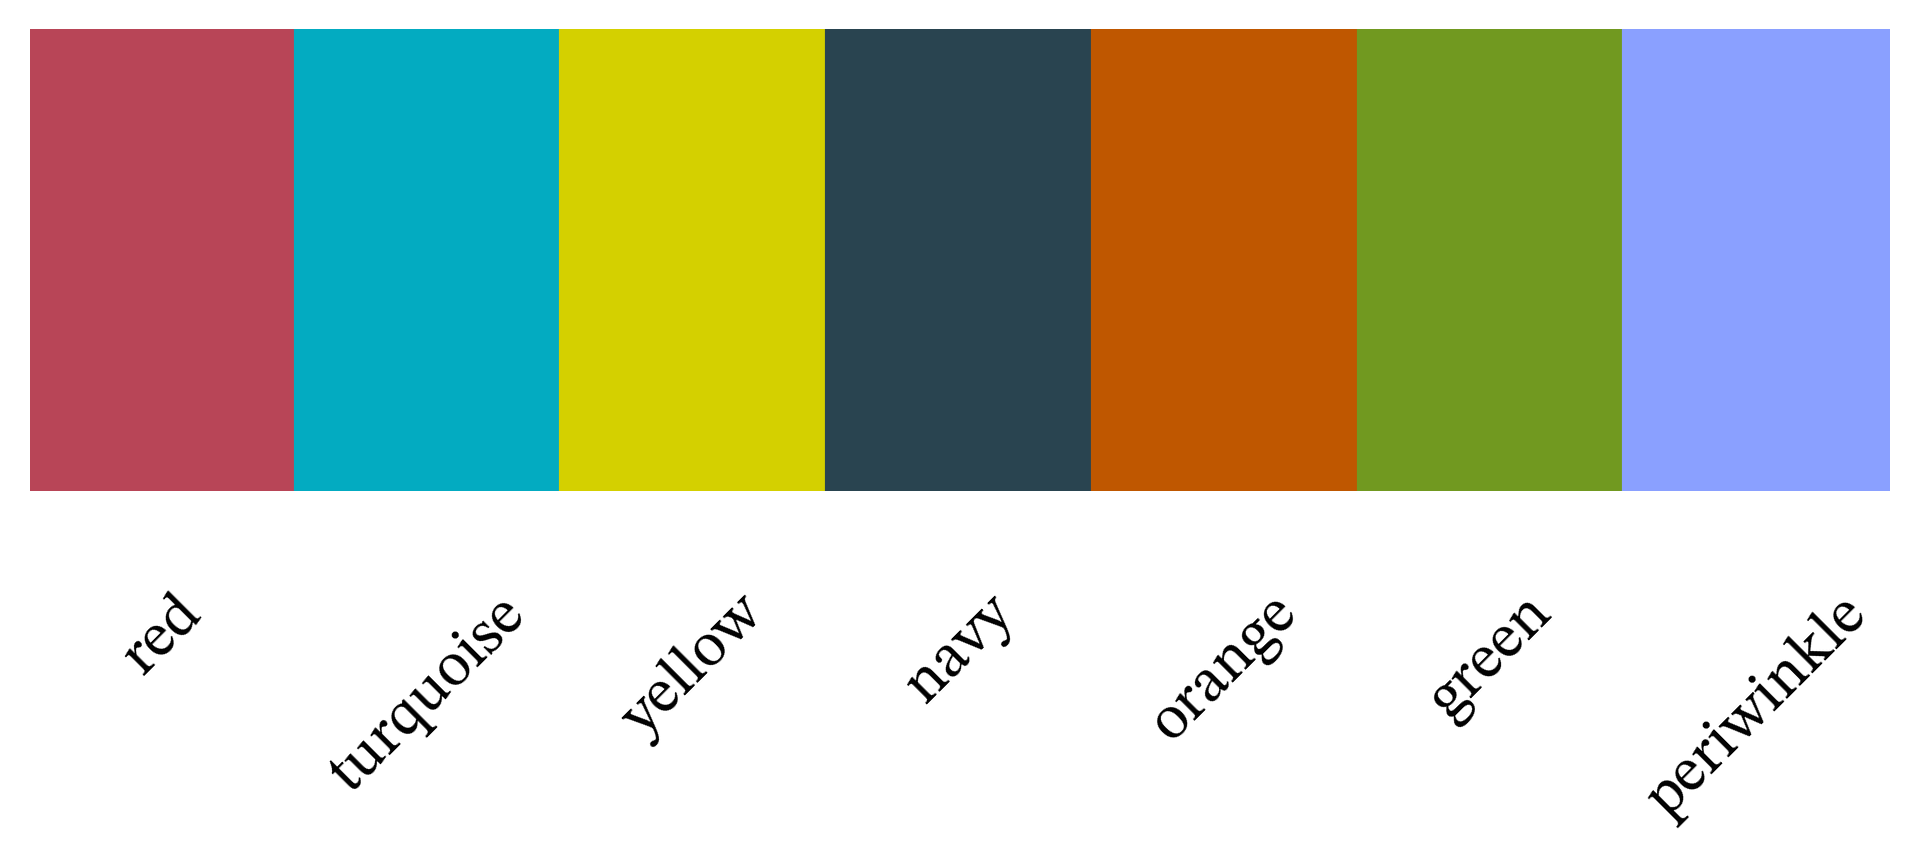

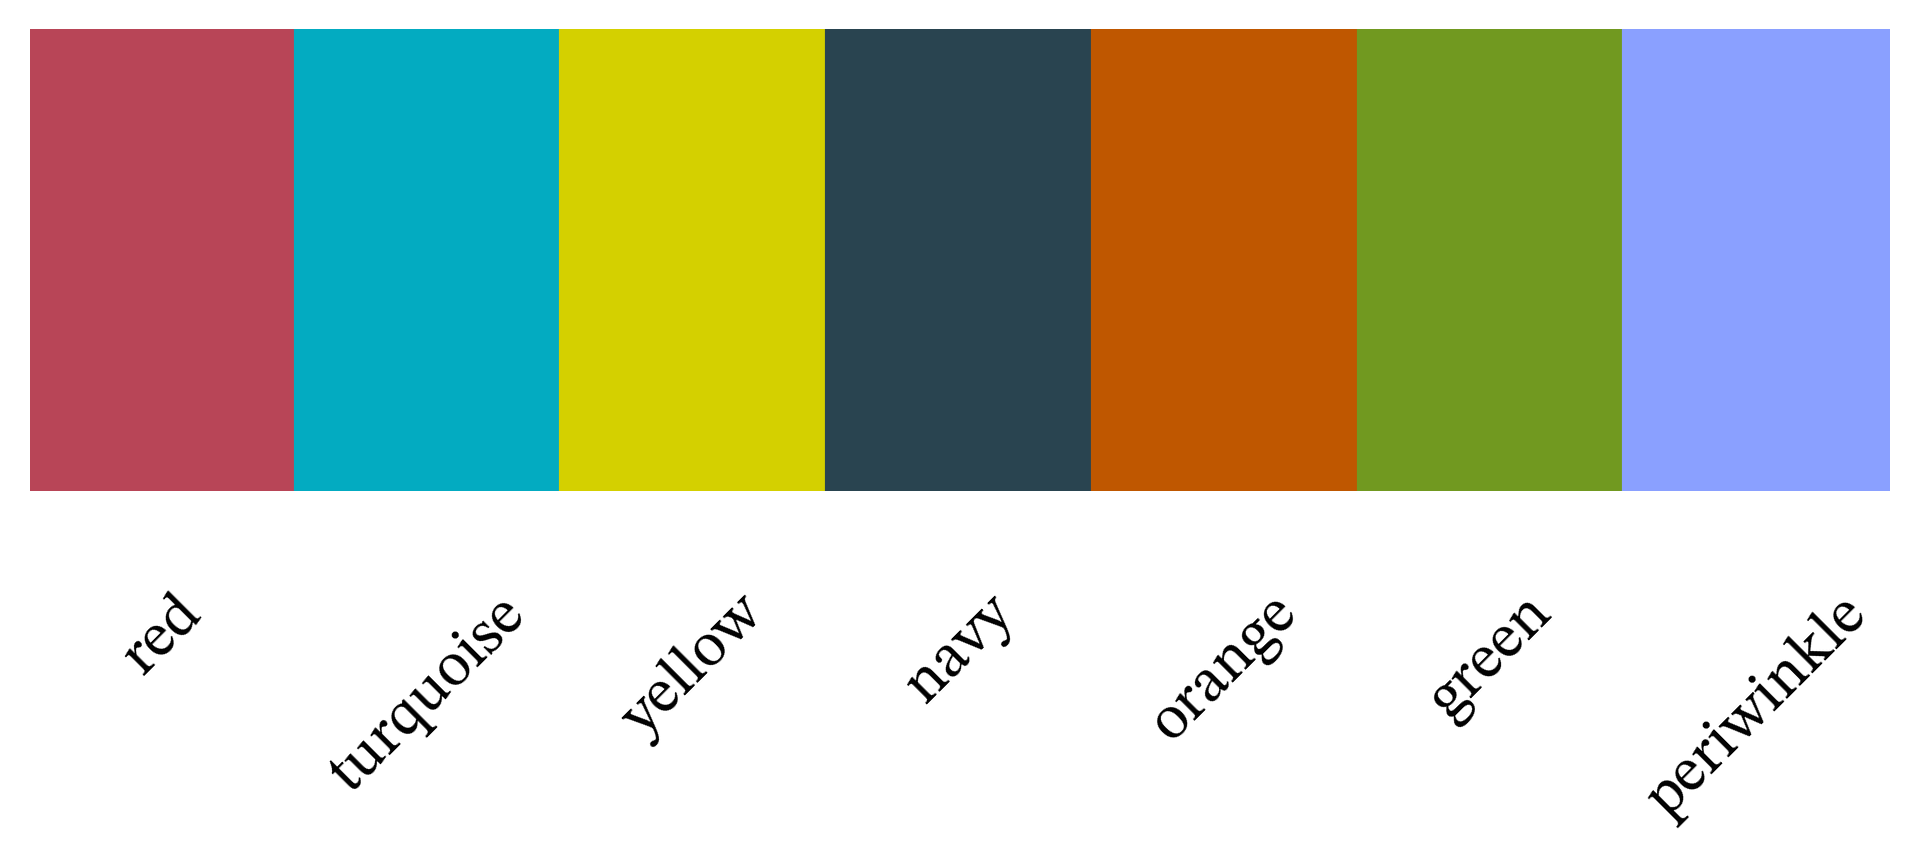

In [252]:
eplots.plot_colors()

In [211]:
low_sigma_plot.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/low_sigma_single_z.png', dpi = 300)

In [80]:
const_sig = [0.388, -0.075, 12.051, 0.083, -1.388, -0.127, 0.754, 0, 0, 0.3]

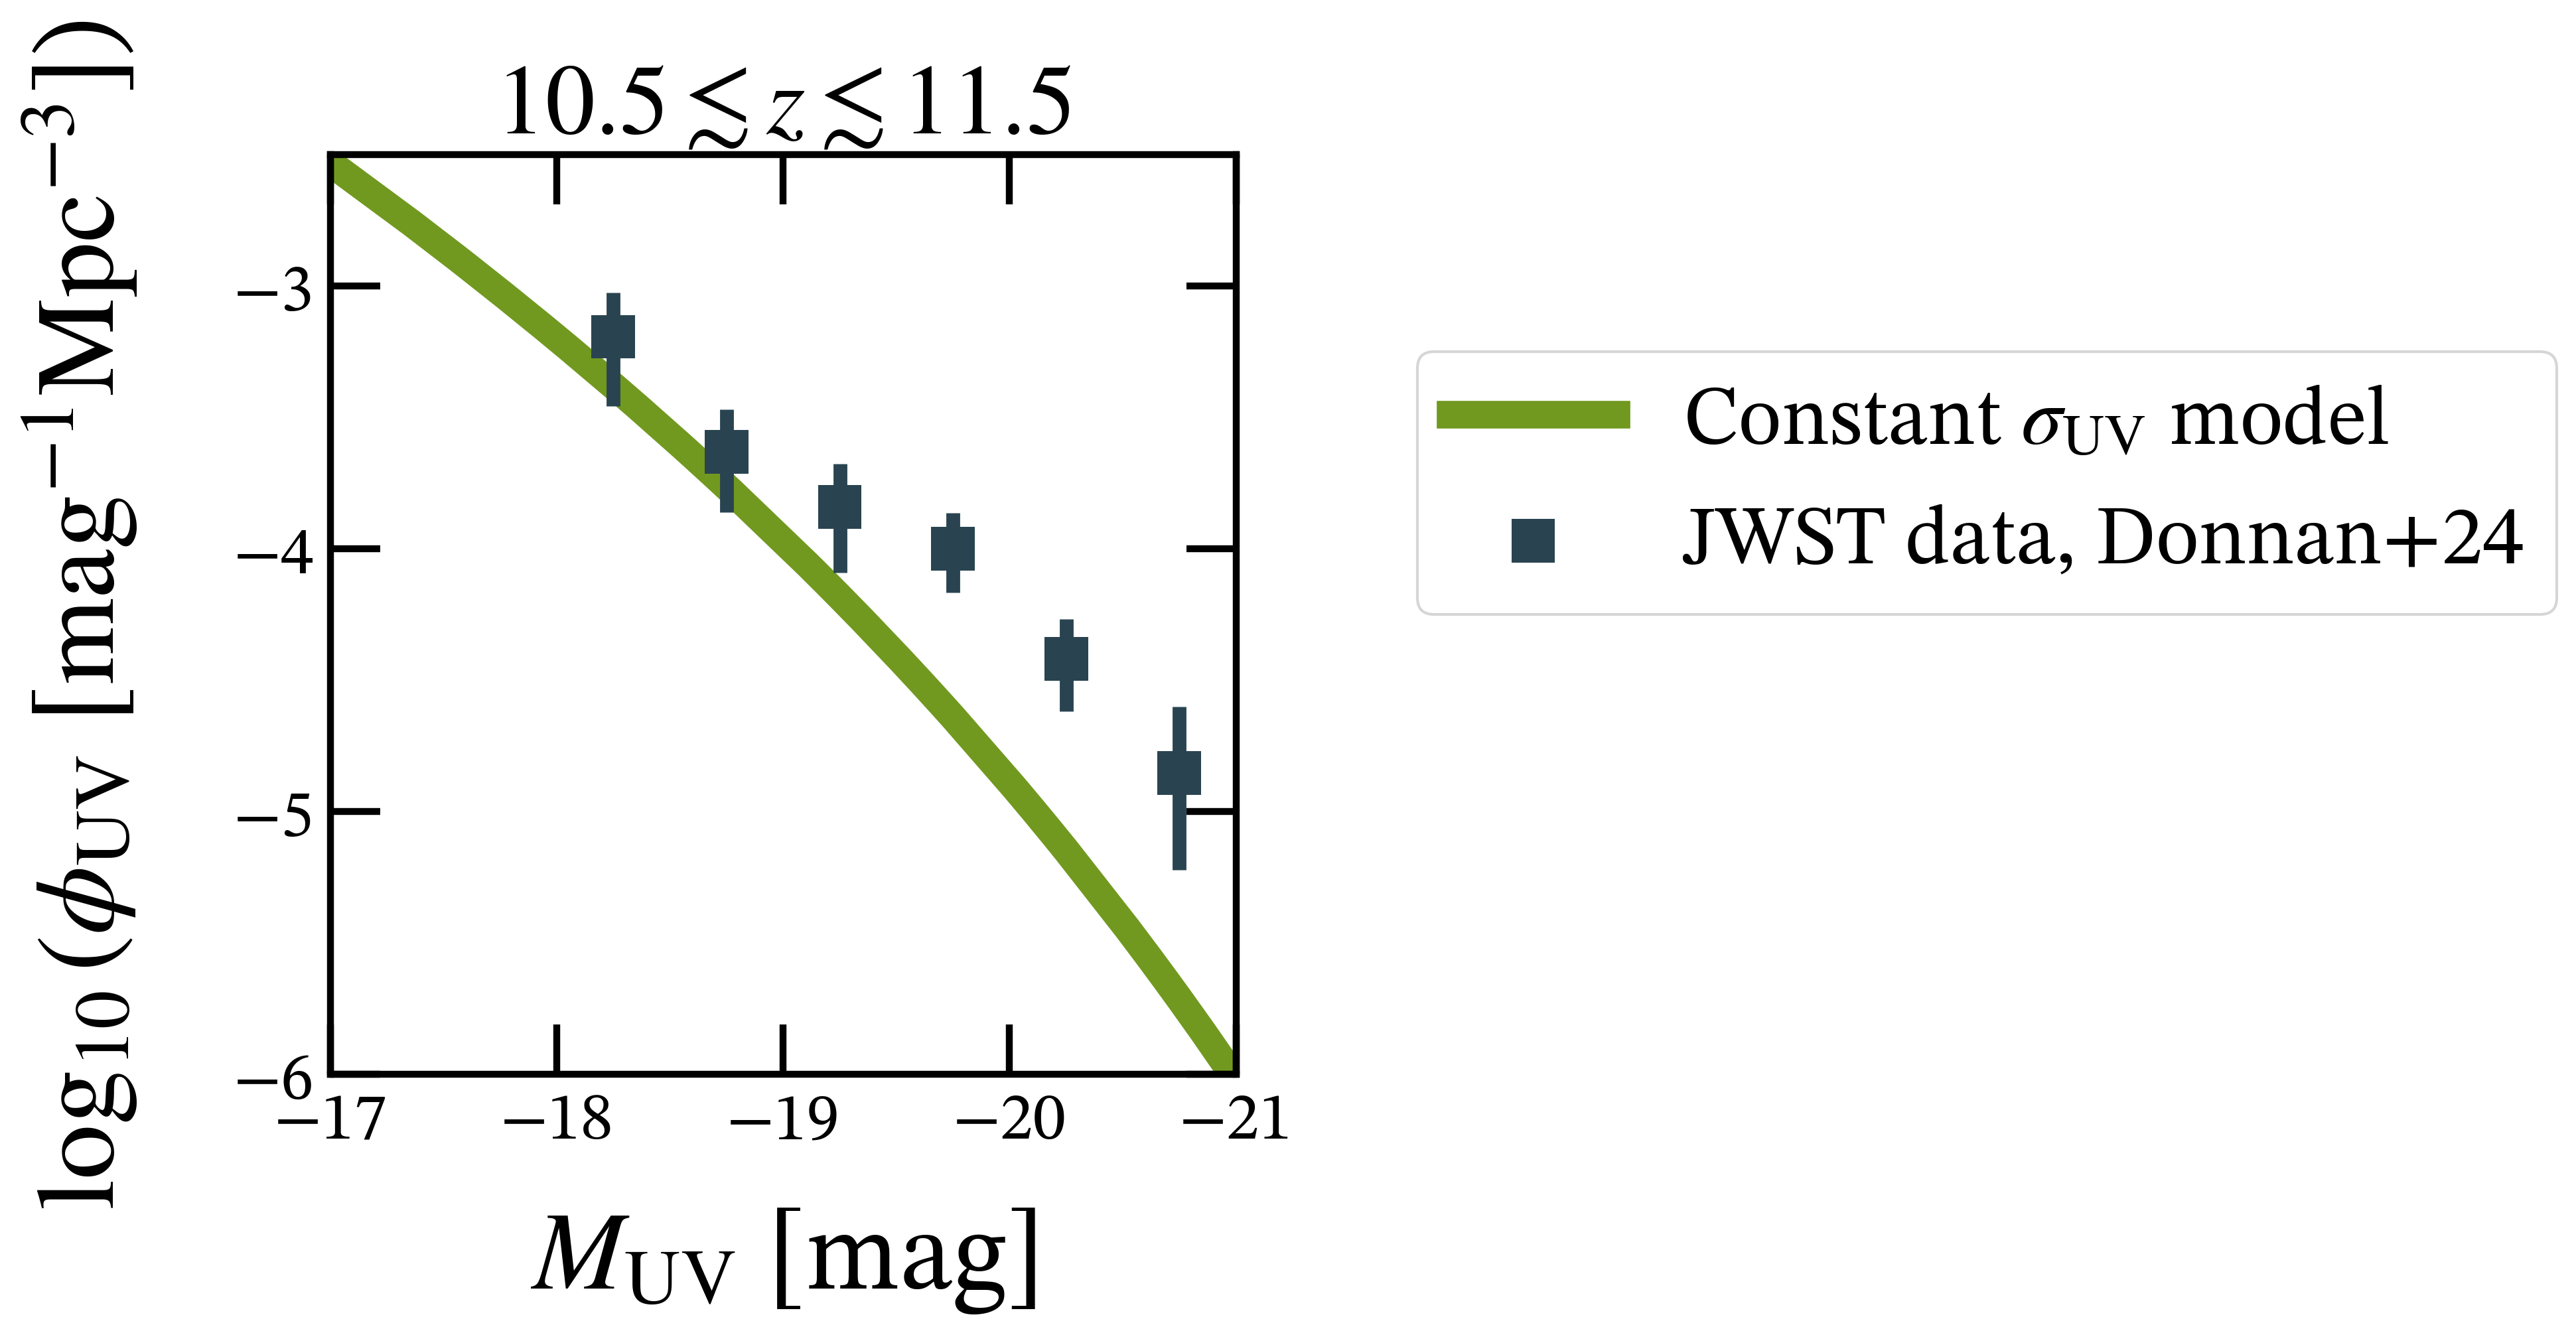

In [218]:
UVLF_plot = evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [const_sig], 
                               comparison_labels = [r'Constant $\sigma_{\rm{UV}}$ model'], ncols = 4, 
                               fit_colors = [eplots.green],z_plot = [11], show_chi2 = False)

UVLF_plot.set_size_inches(27, 6)


for ax in UVLF_plot.axes:
    ax.set_ylim(-6, -2.5)
    ax.set_xlim(-17, -21)
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(MultipleLocator(1))

In [219]:
UVLF_plot.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/const_sig_single_z.png', dpi = 300)

In [96]:
mass_dependent = [0.818, -0.032, 11.995, 0.05, -1.373, -0.138, 0.992,
0, -0.796, 0.677]

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


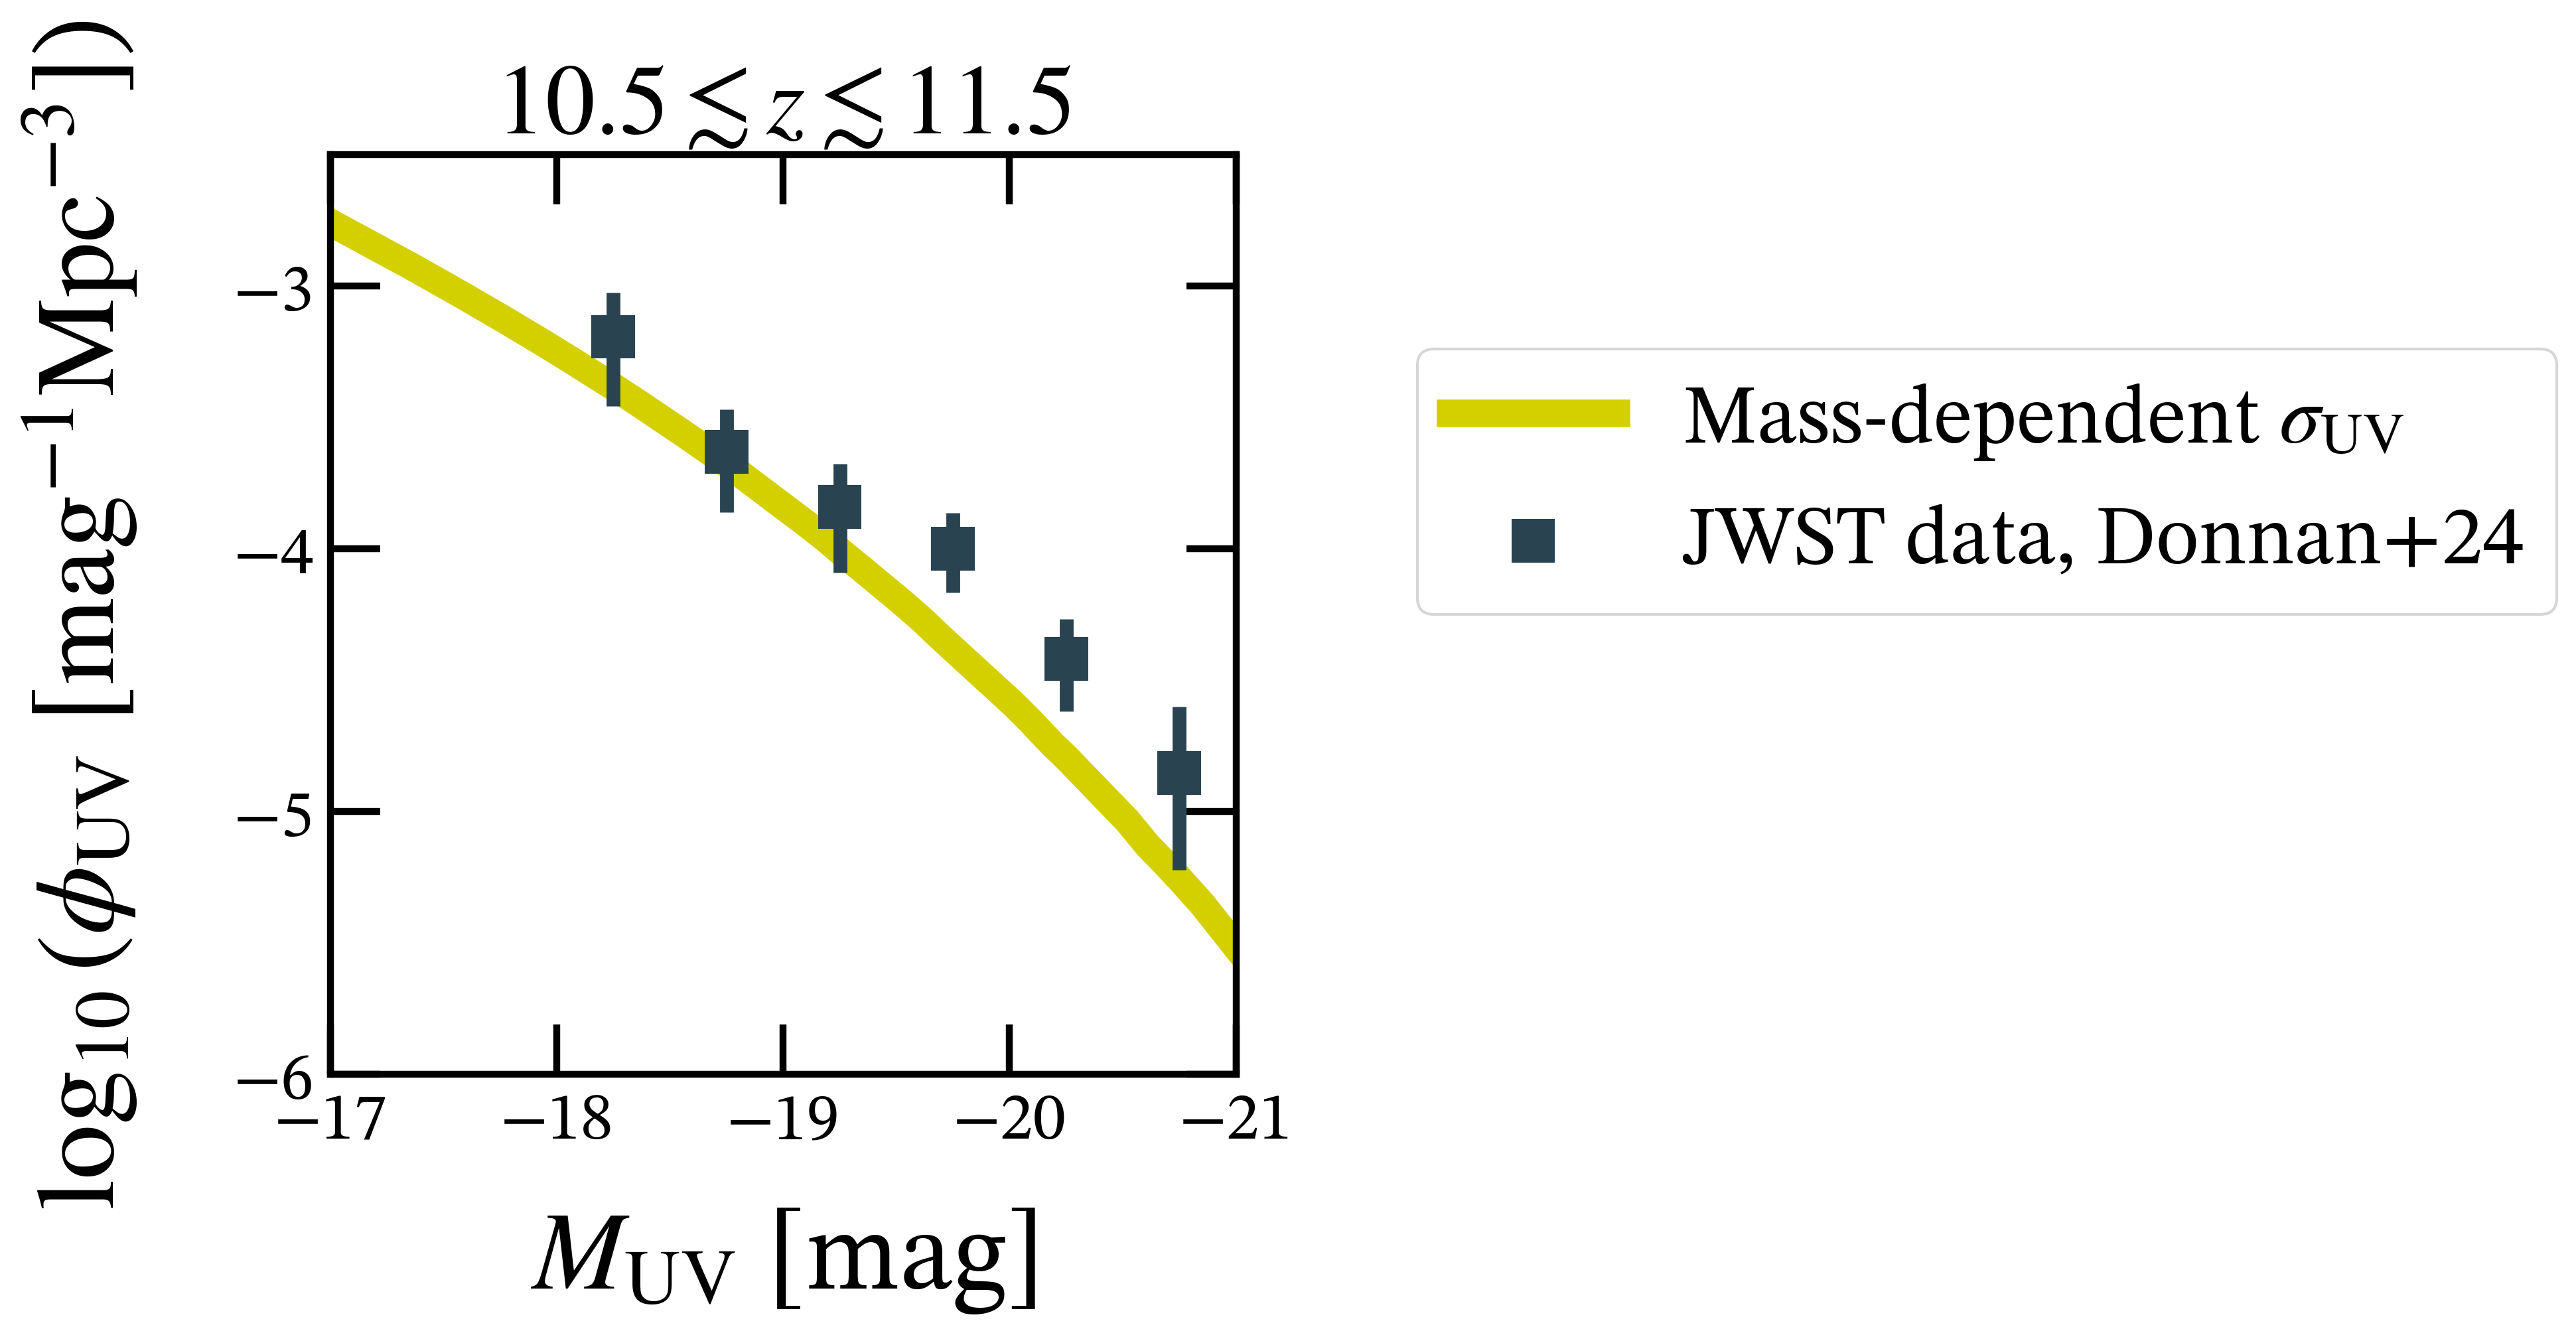

In [215]:
UVLF_plot = evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [mass_dependent], 
                               comparison_labels = [r'Mass-dependent $\sigma_{\rm{UV}}$'], ncols = 4, 
                               fit_colors = [eplots.yellow],z_plot = [11], show_chi2 = False)

UVLF_plot.set_size_inches(27, 6)


for ax in UVLF_plot.axes:
    ax.set_ylim(-6, -2.5)
    ax.set_xlim(-17, -21)
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(MultipleLocator(1))

In [216]:
UVLF_plot.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/mass_dependent_single_z.png', dpi = 300)

In [99]:
redshift_dependent = [0.49, -0.019, 11.757, -0.04, -1.344, -0.117, 0.527,
0.236, 0, 0.668]

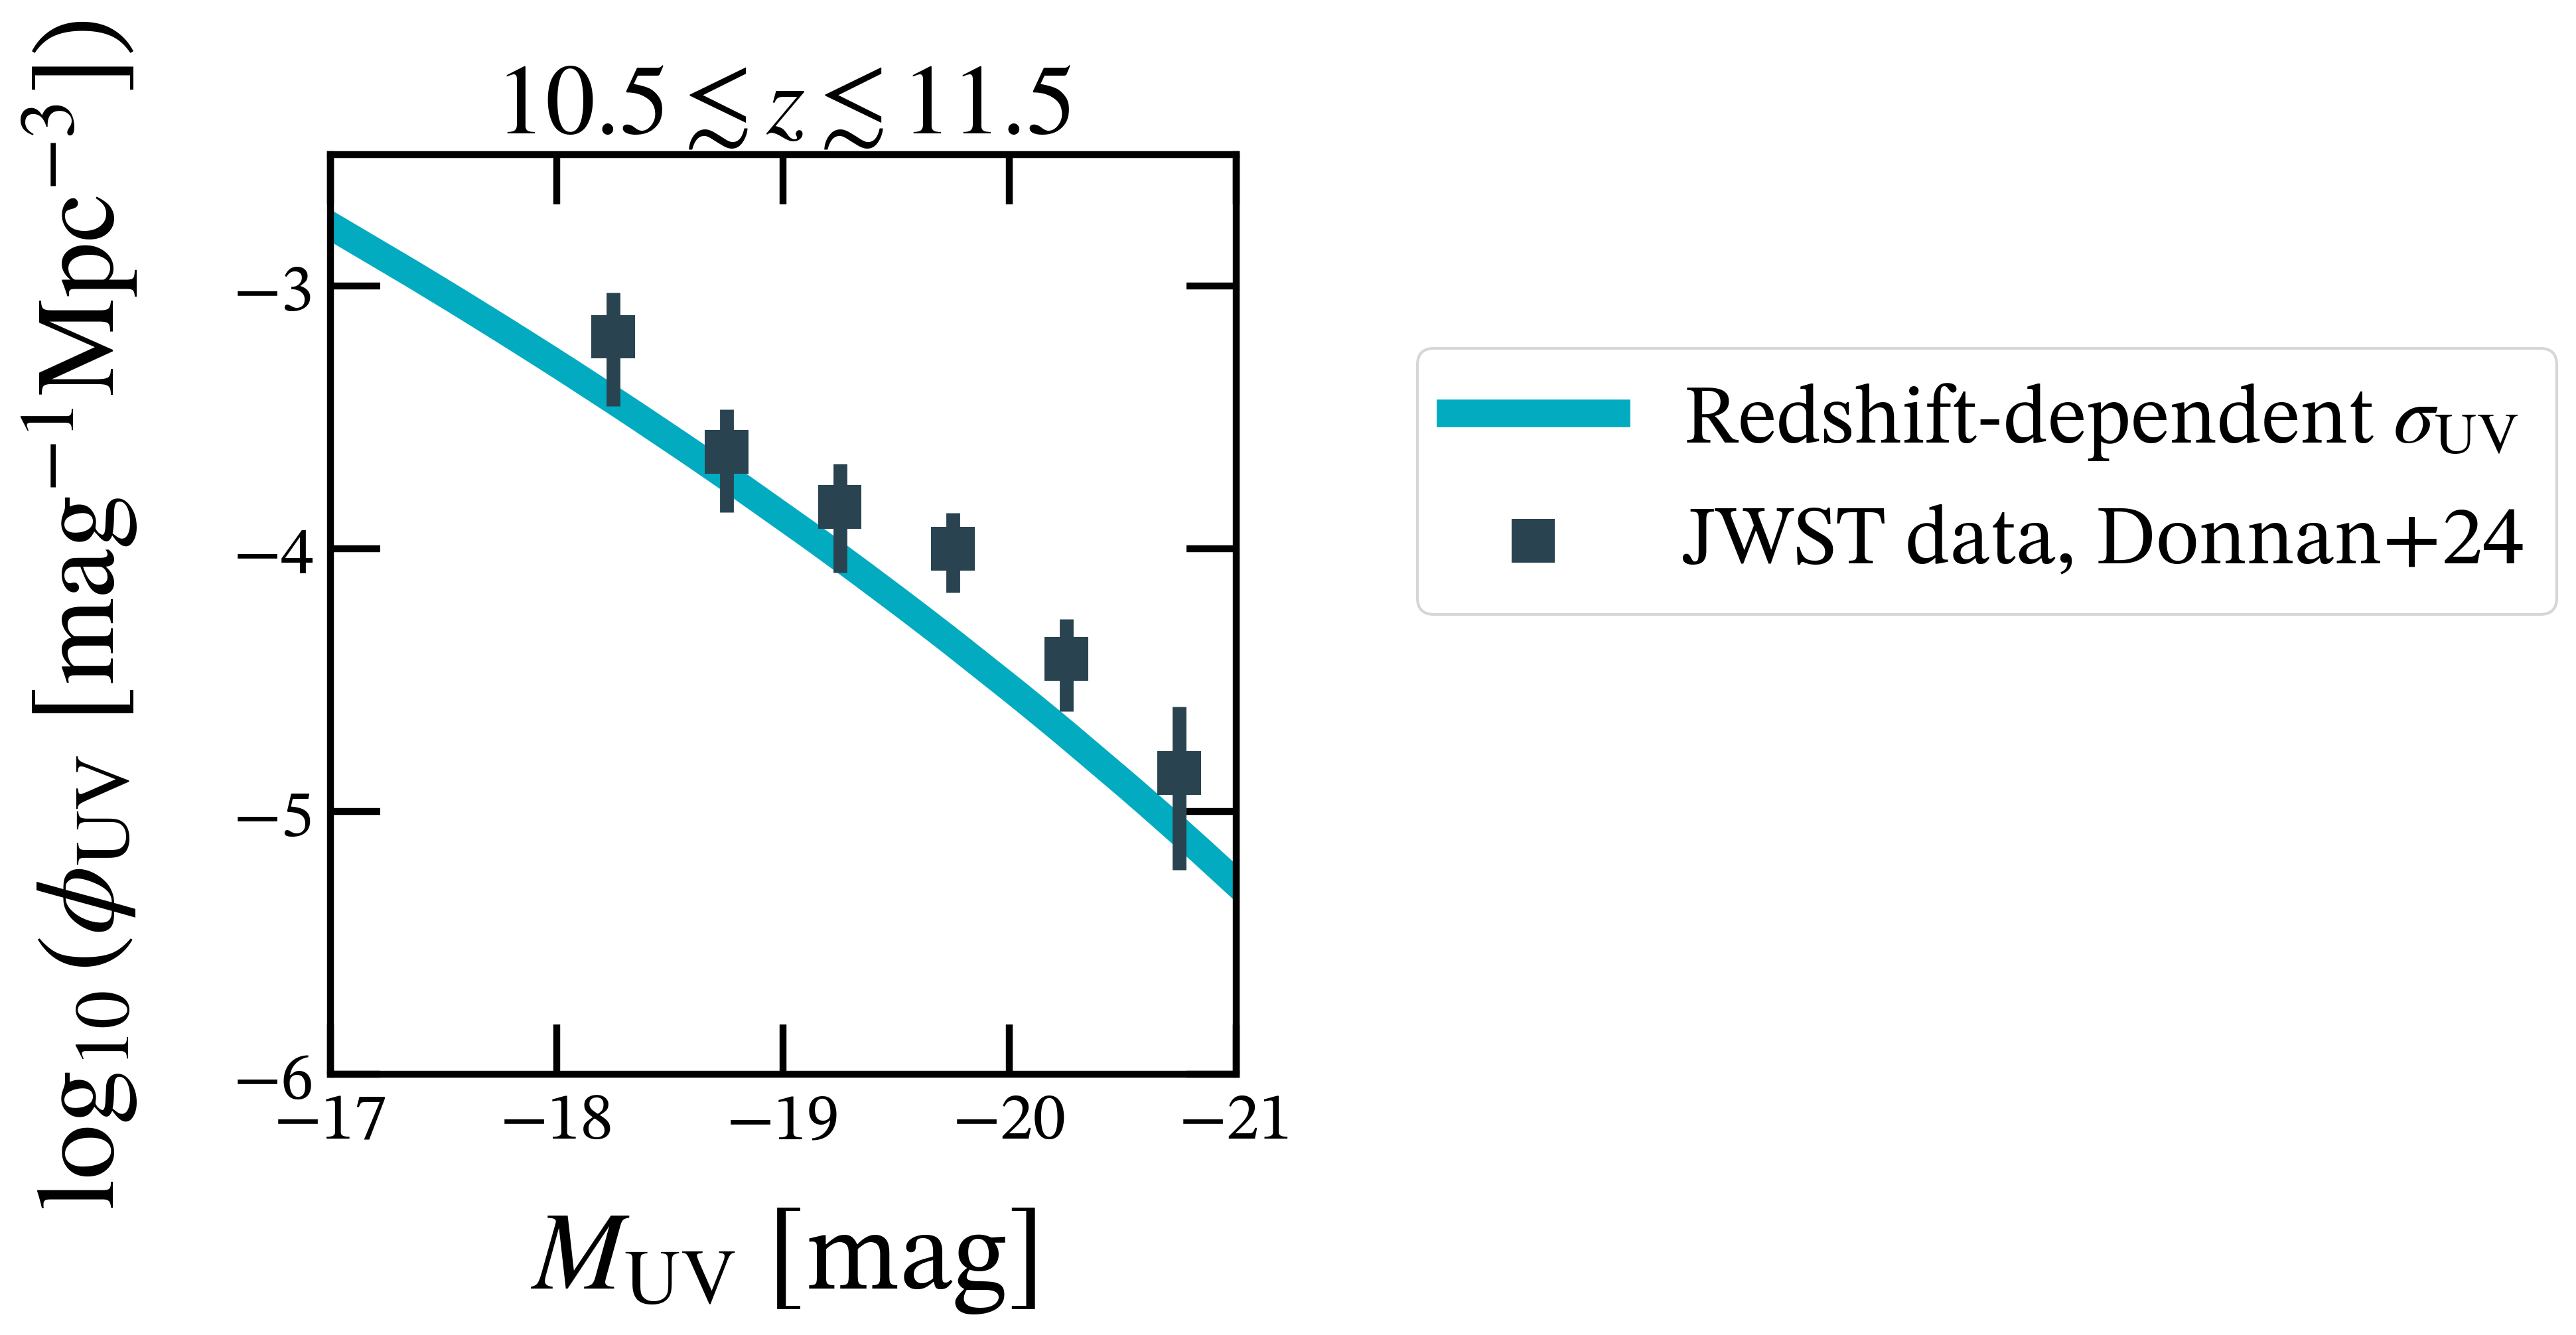

In [222]:
UVLF_plot = evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [redshift_dependent], 
                               comparison_labels = [r'Redshift-dependent $\sigma_{\rm{UV}}$'], ncols = 4, 
                               fit_colors = [eplots.turquoise],z_plot = [11], show_chi2 = False)

UVLF_plot.set_size_inches(27, 6)


for ax in UVLF_plot.axes:
    ax.set_ylim(-6, -2.5)
    ax.set_xlim(-17, -21)
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(MultipleLocator(1))

In [223]:
UVLF_plot.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/z_dependent_single_z.png', dpi = 300)

In [183]:
def normalize_by_data(my_UVLF, backend_file = None, z_plot = None, z_errs = None, plot_from_chain = True, nsamples = 100, 
                      
                      comparison_fits = [], comparison_labels = [], 
                      ncols = 3, burn_in = None, show_chi2 = True, data_fmt = None, fit_colors = None):
    """
    Plot the UVLF at different redshifts
    Inputs:
        my_UVLF: eMCMC UVLF object
        backend_file [str]: .h5 file containing previously saved chain
        z_plot [list of floats]: redshifts to plot, or None if you want to plot all the redshifts for which there exists data
        z_errs [list of floats]: the uncertainty in redshift, or None if you want to use the uncertainty that corresponds to the data.
                                If you provide redshifts to plot but no redshift error, it will default to 0.5.
        plot_from_chain [bool]: whether or not to plot the best fit and samples from the chain stored in my_UVLF. If False, only comparison_fits
                             parameter values will be plotted (so you can quickly check different fits this way).
        nsamples [int]: number of samples from the MCMC chain you want to appear in addition to the best fit
        comparison_fits [list of lists]: lists of parameter values that will be used to create comparison UVLFs
        comparison_labels [list of strs]: labels that correspond to the parameter values in comparison_fits, for the legend
        ncols [int]: number of columns to plot
        burn_in [int]: number of samples to discard as burnin. If None, the default value will be used (see UVLF.get_fit())
        show_chi2 [bool]: whether or not to show the chi squared of the fit(s). Does not apply if plot_from_chain is True
        data_fmt [list]: list of scatter plot styles
        fit_colors [list]: list of colors for the different models
    Outputs:
        Figure showing the UVLF at different redshfits
    """

    data_z = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the input data

    if z_plot is None:
        z_plot = data_z
        z_errs = [dat[1] for dat in my_UVLF.data]
        dat = my_UVLF.data
    else:
        if z_errs is None:
            z_errs = np.full_like(z_plot, 0.5, dtype = float)
        if type(z_plot) == list:
            z_plot = np.array(z_plot)
        if type(z_errs) == list:
            z_errs = np.array(z_errs)

        idxs = np.concatenate([np.where(np.abs(data_z - z) < z_err)[0] for z, z_err in zip(z_plot, z_errs)])
        dat = [my_UVLF.data[i] for i in idxs]


    if len(comparison_fits) > 0:
        assert len(comparison_labels) > 0, 'If specifying comparison fits you must also give their labels'

    # Figure out how many subplots to make
    nz = len(z_plot)
    fig = plt.figure()
    gs = GridSpec(math.ceil((nz+1)/ncols), ncols, figure=fig)
    plt.subplots_adjust(wspace = 0.2, hspace = 0.4)
    
   
    # Get samples & best fit
    if plot_from_chain:
        samples, best_fit, _, _= my_UVLF.get_fit(backend_file = backend_file, exclude_unfit = True, burn_in = burn_in)
        print(best_fit)
    
    chi2_comparison = [-2*my_UVLF.log_like(fit, dat) for fit in comparison_fits]

    # Plotting details
    if data_fmt is None:
        data_fmt = ['o','s', 'D', '^', 'P']
    if fit_colors is None:
        fit_colors = [turquoise, yellow, orange, green]

    axs = []
    for i, (z, z_err) in enumerate(zip(z_plot, z_errs)): 

        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)
        
        # Plot data
        all_dat_z = [dat[0][0] for dat in my_UVLF.sorted_data]
        idx = np.where(np.abs(all_dat_z - z) <= z_err)[0]
        if len(idx) > 0:
            for zbin in [my_UVLF.sorted_data[idx_i] for idx_i in idx]:
            #zbin = my_UVLF.sorted_data[idx[0]]

                for dat_z, fmt in zip(zbin, data_fmt): 
                    xdat, ydat, yerr_upper, yerr_lower, xerr, upper_lim_bool = dat_z[2], dat_z[3], dat_z[4], dat_z[5], dat_z[6], dat_z[7].astype('bool')
                    ax.vlines(xdat, -yerr_lower/ydat, yerr_upper/ydat, ls = '-', colors = eplots.navy, linewidth =5, zorder = 2)
                    ax.scatter(xdat, np.zeros_like(xdat), marker = fmt, s = 125, facecolor = eplots.navy, zorder = 2)

                    for fit, chi2_fit, label, color, ls in zip(comparison_fits, chi2_comparison, comparison_labels, fit_colors, 
                                                    ['solid', 'dashdot', 'dashed', 'dotted', 'solid']):
                        if show_chi2:
                            fit_label = fr'{label}, $\chi^2 = {chi2_fit:.0f}$'
                        else:
                            fit_label = f'{label}'
                        UVLF_data = my_UVLF.UVLF_wrapper(z, z_err, xdat, np.full_like(xdat, 0.5),fit)
                        ax.axhline(0, color = eplots.navy, zorder = 0, linewidth = 2, ls = 'dotted')
                        ax.plot(xdat, (UVLF_data-ydat)/ydat, color = color, 
                                label = fit_label, linestyle = ls, zorder = 1)

        ax.invert_xaxis() 

        ax.set_title(fr'${round(z-z_err, 1)} \lesssim z \lesssim {round(z+z_err, 1)}$', pad = 8)


    # Text & labels
    ylabel = 'Percent difference'
    xlabel = r'$M_{\rm{UV}}$ [mag]'

    # Formatting, labels
    multicol(gs, axs, xlabel, ylabel, include_legend = True)
    
    return fig

In [5]:
# norm = normalize_by_data(my_UVLF, plot_from_chain = False, comparison_fits = [redshift_dependent, mass_dependent], 
#                                comparison_labels = [r'Redshift-dependent $\sigma_{\rm{UV}}$', 'mass dependent'], ncols = 4, 
#                                fit_colors = [eplots.turquoise, eplots.yellow], show_chi2 = False)

# # norm.set_size_inches(27, 6)


# for ax in norm.axes:
#     ax.set_ylim(-1, 1)
#     ax.xaxis.set_major_locator(MultipleLocator(2))

In [207]:
redshift_dependent

[0.49, -0.019, 11.757, -0.04, -1.344, -0.117, 0.527, 0.236, 0, 0.668]

In [204]:
len(samples[0])

10

In [226]:
lowers = np.array([0.04, 0.03, 0.05, 0.07, 0.1, 0.12, 0.1, 0.08, 0.08])
uppers = np.array([0.04, 0.03, 0.03, 0.04, 0.06, 0.07, 0.05, 0.05, 0.05])

yerr = np.vstack((lowers, uppers))

piecewise = [0.51, -0.02, 11.74, -0.04, -1.33, -0.12, [0.64, 0.67, 0.65, 0.69, 0.6, 0.69, 1.05, 1.46, 1.56], 0, 0, 0.3]

In [235]:
redshift_dependent

[0.49, -0.019, 11.757, -0.04, -1.344, -0.117, 0.527, 0.236, 0, 0.668]

(0.5, 1.65)

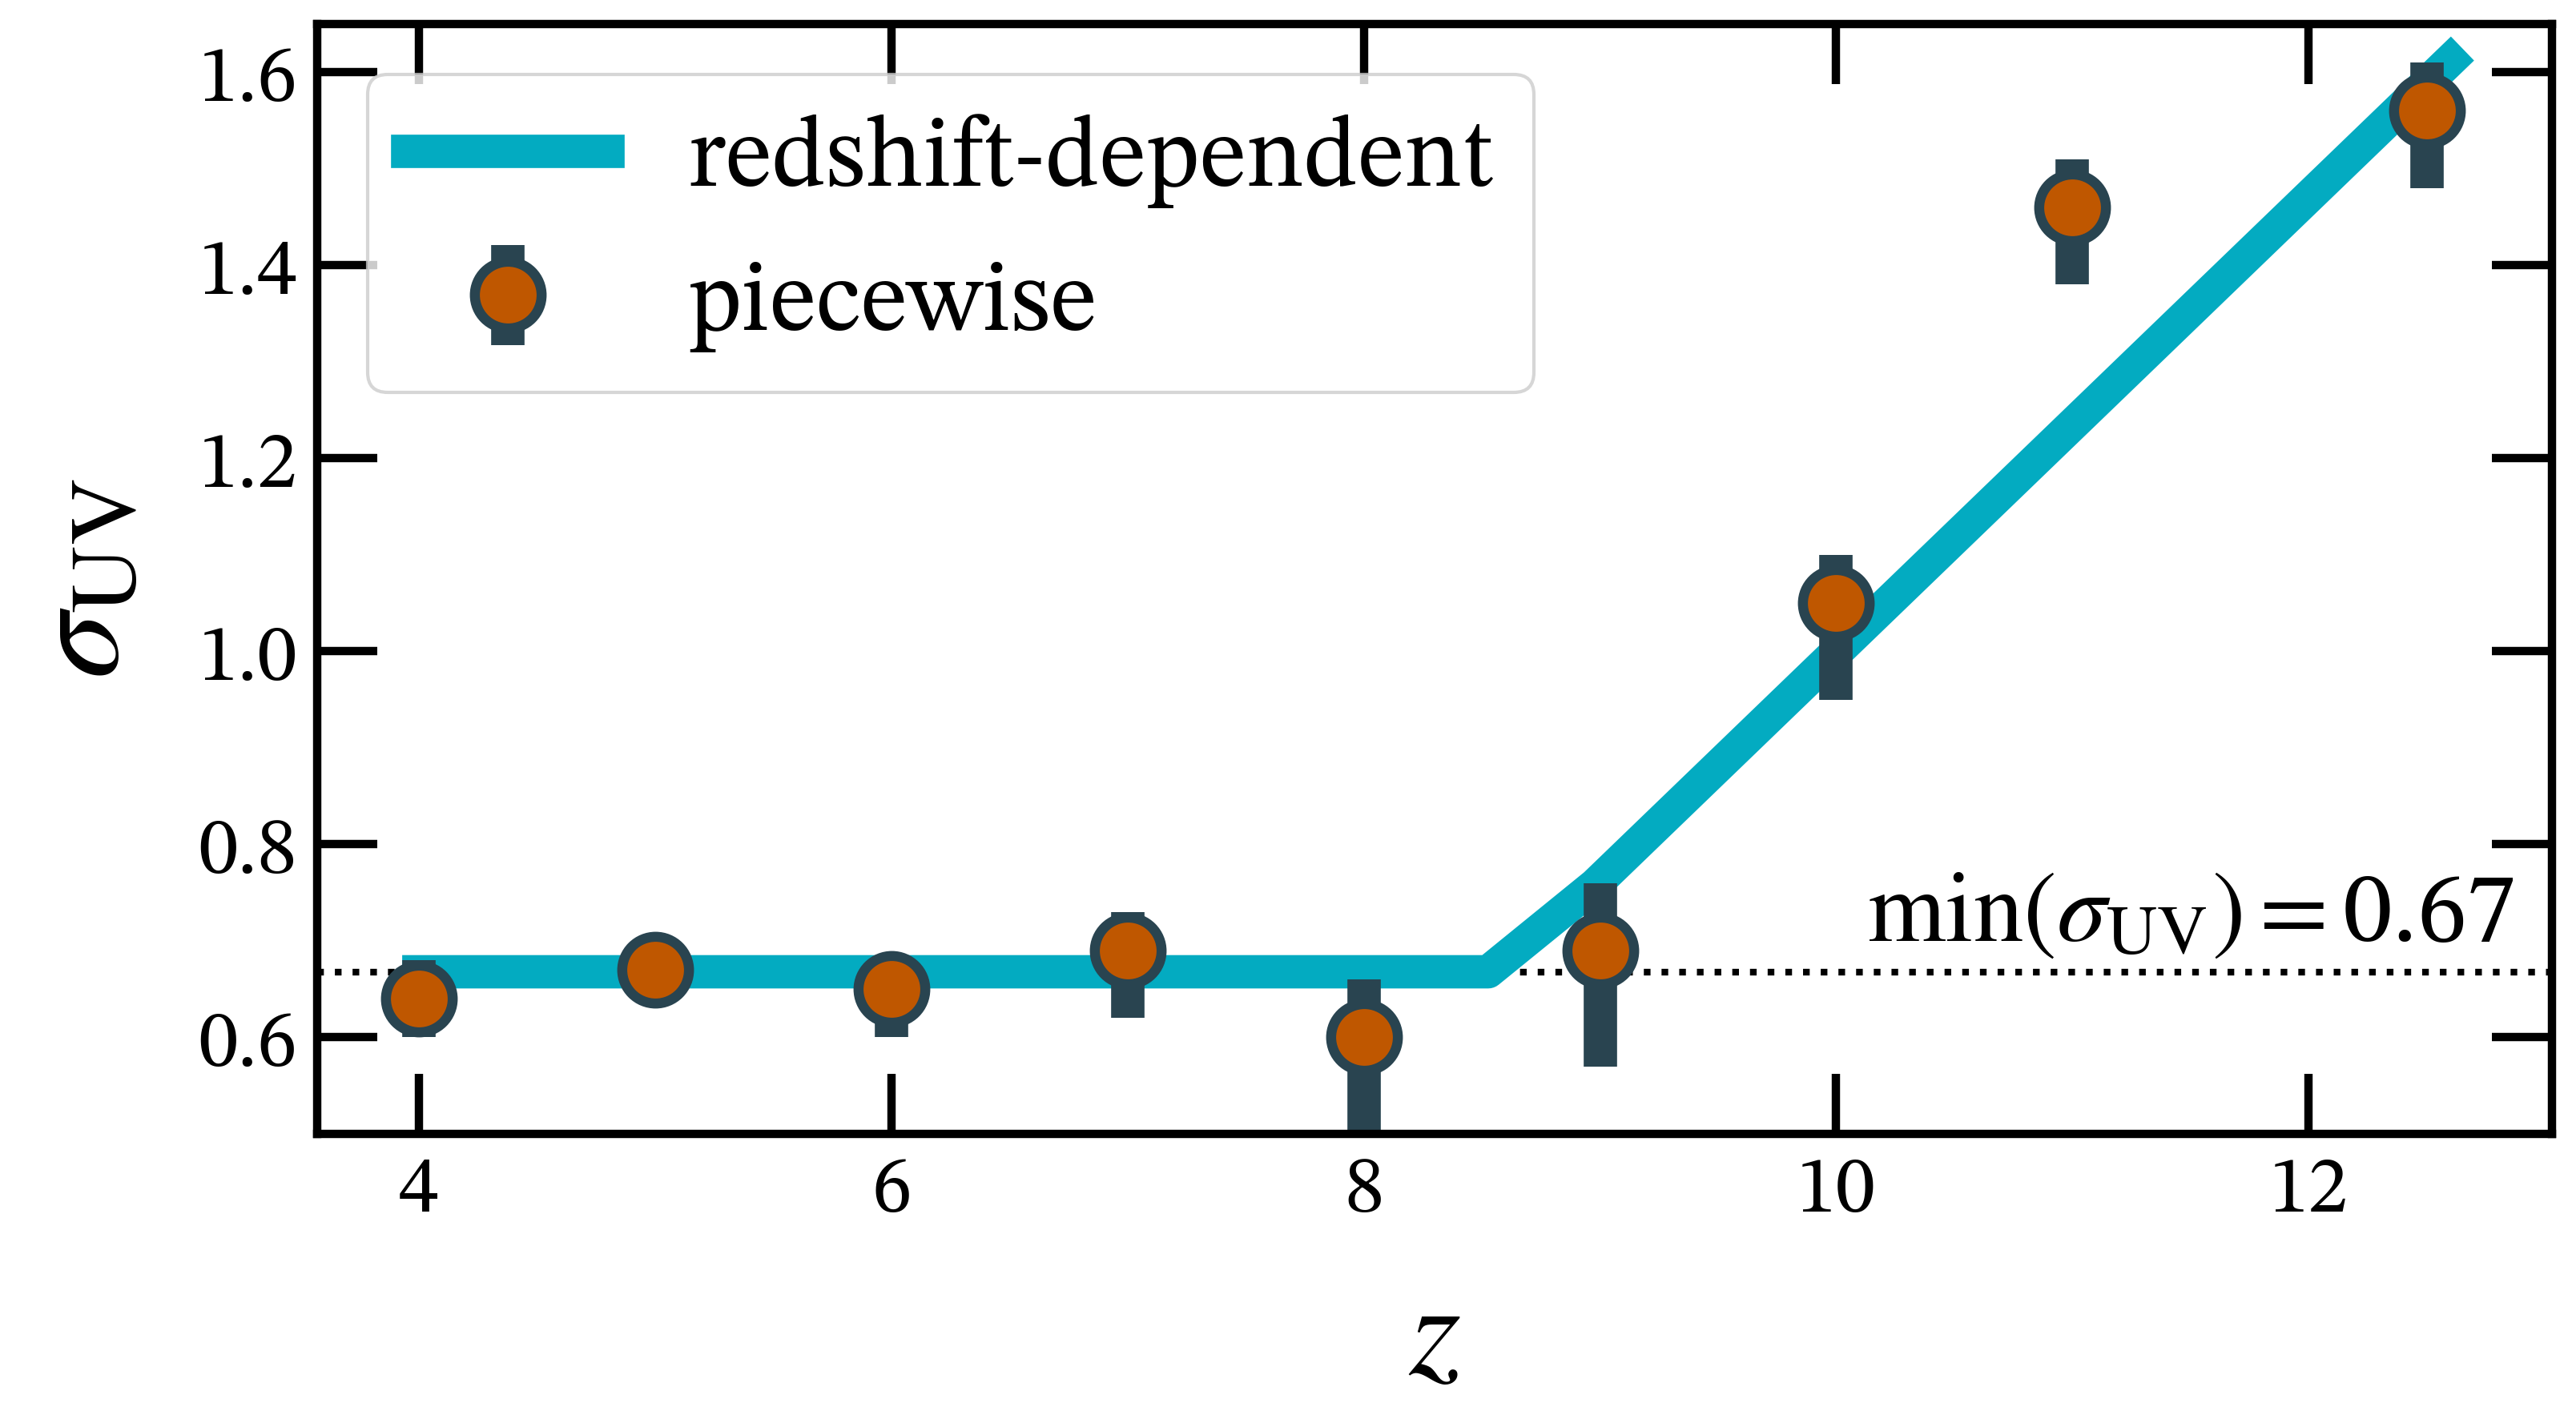

In [246]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
zs = np.linspace(4, 12.6, 20)
sig_lin = [my_UVLF.time_evolution(redshift_dependent, z)[-1][-1] for z in zs]
ax.plot(zs, sig_lin, color = eplots.turquoise, label = 'redshift-dependent')
ax.errorbar(my_UVLF.zs, piecewise[-4], fmt = 'o', color = eplots.orange, yerr = yerr, ecolor = eplots.navy, 
            label = f'piecewise', markeredgecolor = eplots.navy, markeredgewidth=3)

ax.axhline(redshift_dependent[-1], zorder = 0, ls = 'dotted', color = 'black', lw = 2)
ax.text(11.5, 0.7, r'$\min(\sigma_{\rm{UV}}) = $' + f'{round(redshift_dependent[-1], 2)}', ha = 'center')

ax.set_ylabel(r'$\sigma_{\rm{UV}}$')
ax.set_xlabel(r'$z$')
ax.legend()

ax.set_ylim(0.5, 1.65)

In [247]:
fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/redshift_dependent_evolution_with_piecewise.png', dpi = 300)

In [288]:
np.log10(0.46+0.36) - np.log10(0.46)

0.2510560207021426

In [289]:
np.log10(0.46-0.29) - np.log10(0.46)

-0.4323089103033001

In [298]:
np.log10(0.46)

-0.3372421683184259

In [357]:
fiducial = [0.531, -0.001, 11.712, -0.057, -1.338, -0.113, 0.486, 0.229,
-0.152, 0.678]

(3.5, 13.0)

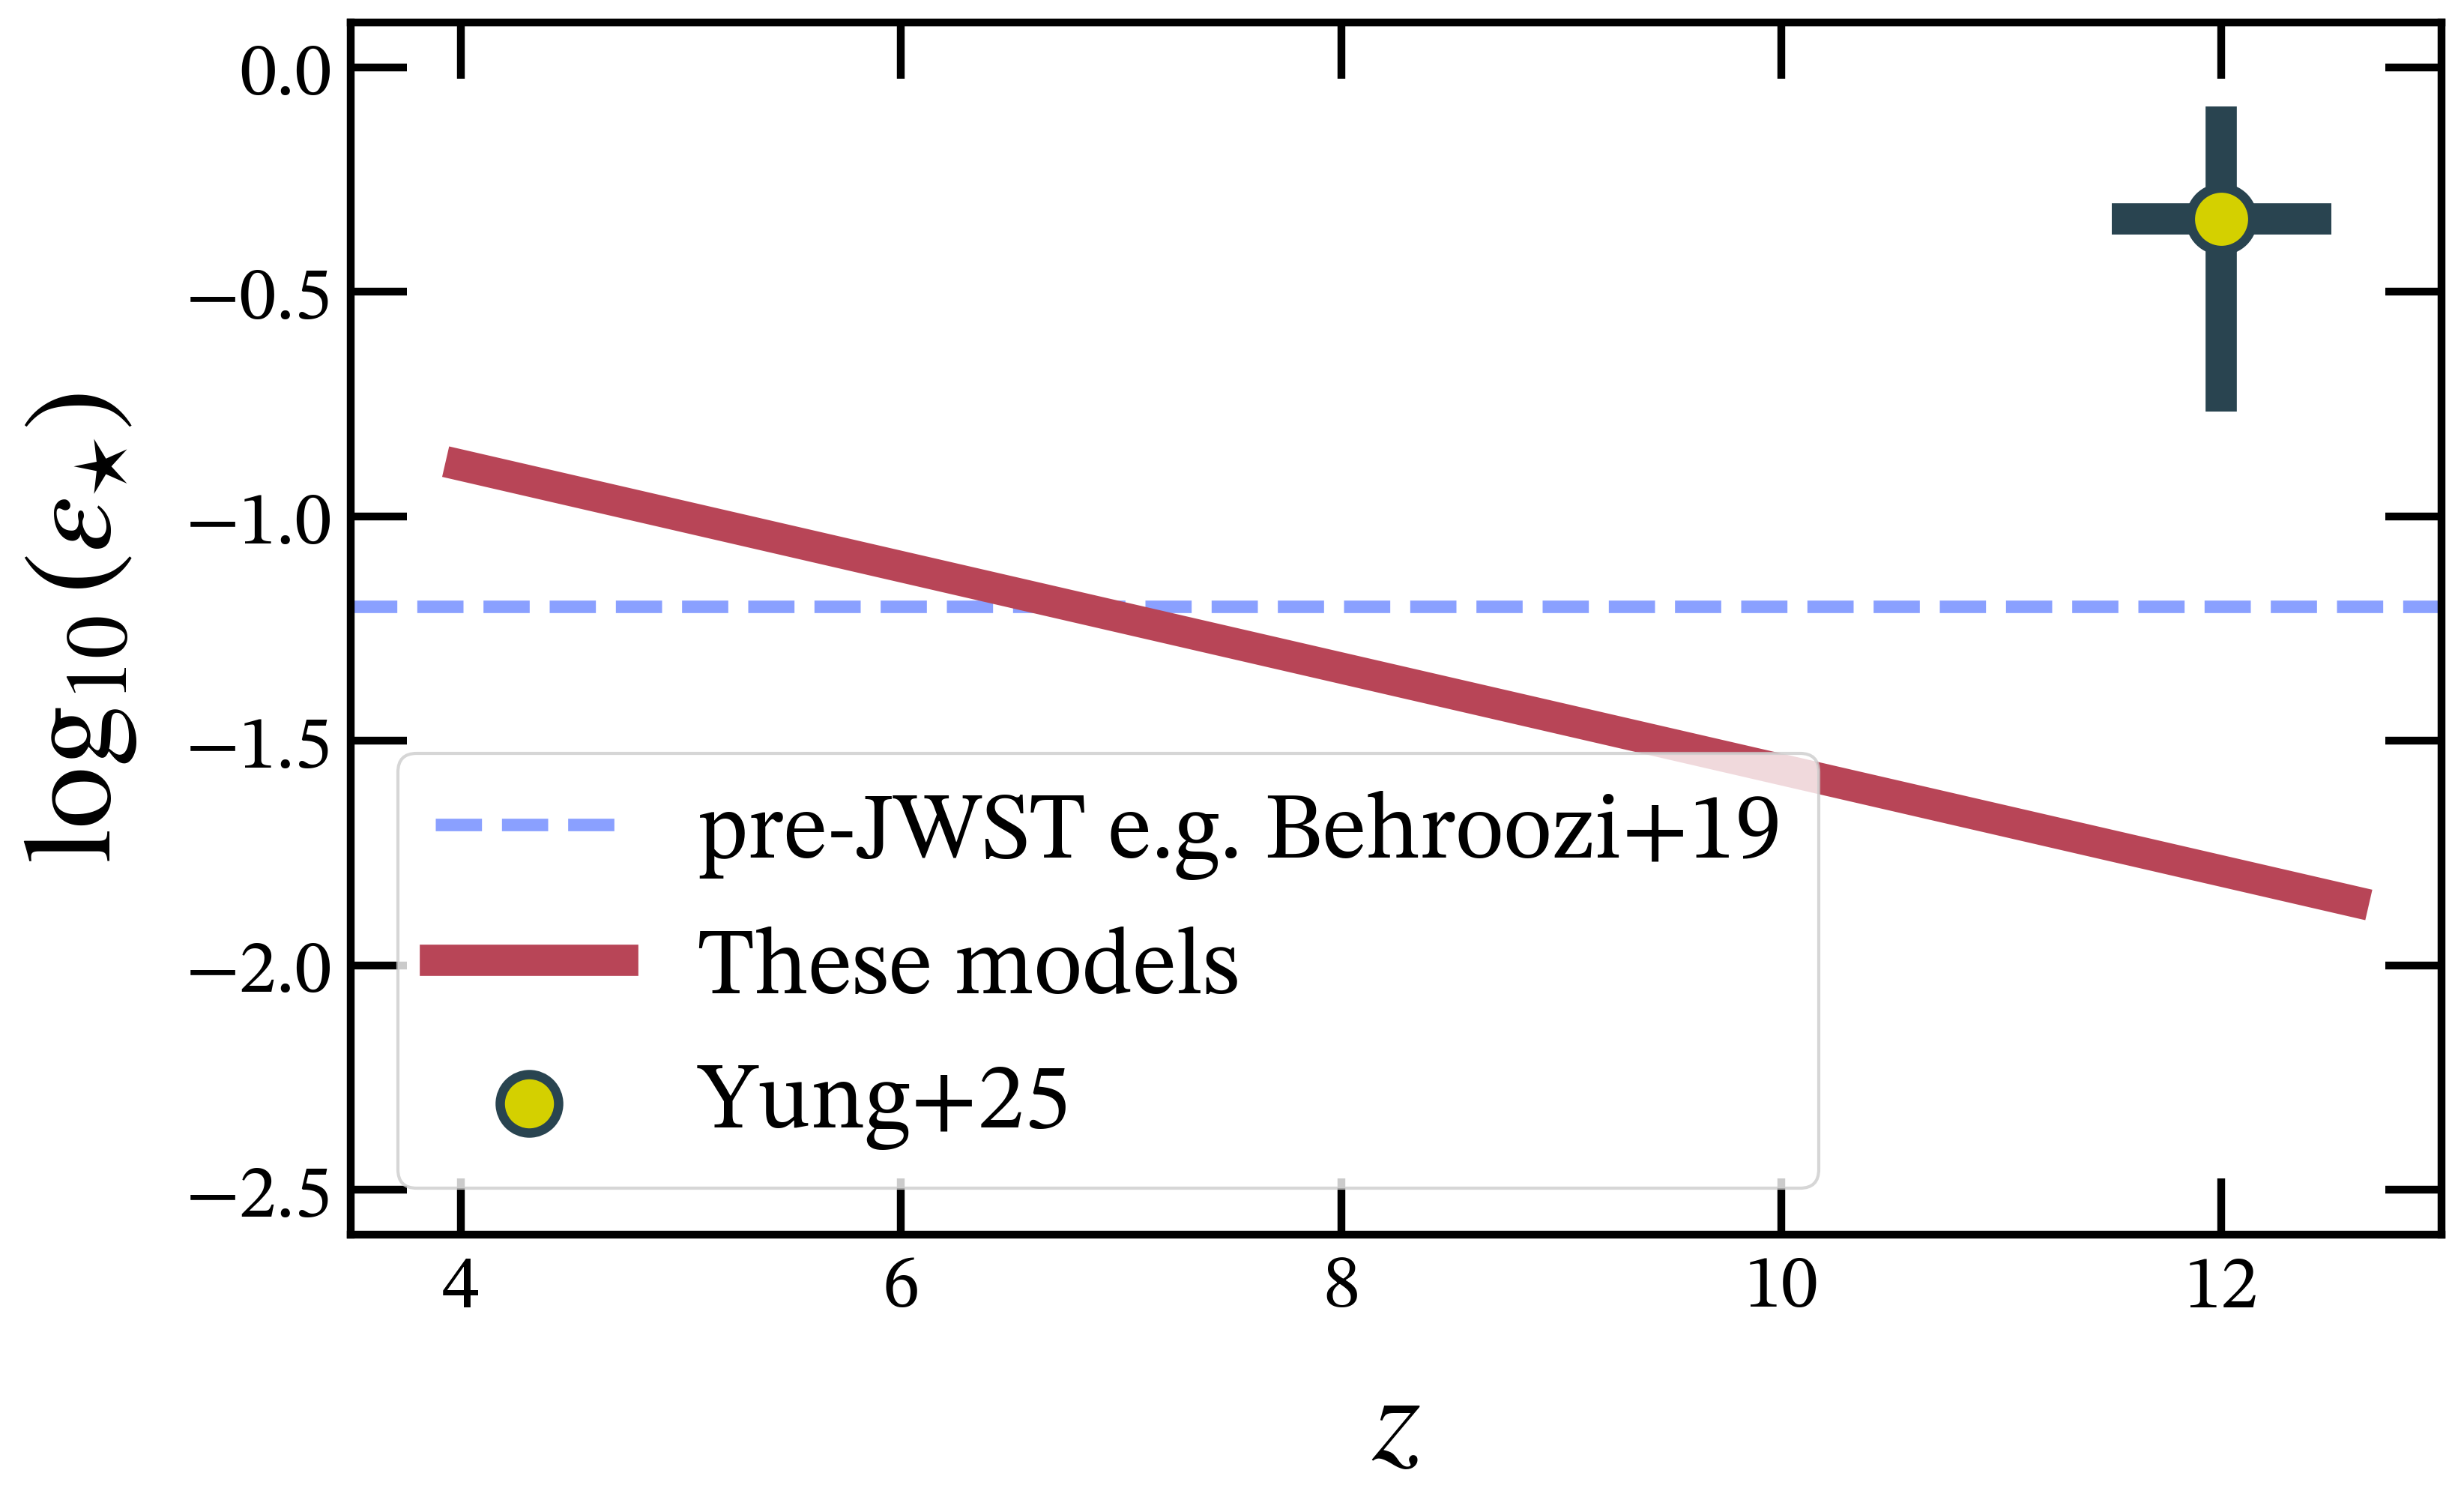

In [372]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 7)
zs = np.linspace(4, 12.6, 20)
eps_lin = [my_UVLF.time_evolution(fiducial, z)[-2] for z in zs]
sig_eps = np.array([my_UVLF.time_evolution(redshift_dependent, z)[-1][-1] for z in zs])/2.5

ax.axhline(-1.2, label = 'pre-JWST e.g. Behroozi+19', zorder = 1, lw = 4, ls = 'dashed', color = eplots.periwinkle)
ax.errorbar(12, np.log10(0.46), yerr = [[0.43], [0.25]], xerr = 0.5, marker = 'o', ls = 'solid', color = eplots.yellow, ecolor = eplots.navy, 
            markeredgecolor = eplots.navy, markeredgewidth=3)
ax.plot(zs, eps_lin, color = eplots.red, label = 'These models')
# ax.fill_between(zs, eps_lin-sig_eps, eps_lin+sig_eps, color = eplots.turquoise, alpha = 0.2, zorder = 0)

ax.set_ylabel(r'$\log_{10}(\epsilon_{\star})$')
ax.set_xlabel(r'$z$')

ax.scatter(0, 0, marker = 'o', s = 350, color=eplots.yellow, edgecolors = eplots.navy, linewidths=3, label = 'Yung+25')
ax.legend(loc = 'lower left', numpoints = 1)

ax.set_ylim(-2.6, 0.1)
ax.set_xlim(3.5, 13)

In [373]:
fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/eps_3.png', dpi = 300)

In [88]:
def age_of_universe(z, H0=70.0, Omega_m=0.3):
    """
    Age of the universe at redshift z in Gyr (flat LCDM).
    
    Parameters
    ----------
    z : float or array
    H0 : float
        Hubble constant in km/s/Mpc
    Omega_m : float
        Matter density parameter (Omega_L = 1 - Omega_m)
    """
    Omega_L = 1.0 - Omega_m
    
    # H0 in s^-1
    H0_si = H0 * (1e3) / (3.085677581e22)
    
    # Prefactor in seconds
    t0 = 2.0 / (3.0 * H0_si * np.sqrt(Omega_L))
    
    a = 1.0 / (1.0 + z)
    
    # Analytic solution
    arg = np.sqrt(Omega_L / Omega_m) * a**(3/2)
    t = t0 * np.arcsinh(arg)
    
    # convert to Gyr
    return t / (3600 * 24 * 365.25 * 1e9)

In [374]:
def evolving_UVLF_fit(my_UVLF, backend_file = None, z_plot = None, z_errs = None, plot_from_chain = True, nsamples = 100, 
                      
                      comparison_fits = [], comparison_labels = [], 
                      ncols = 3, burn_in = None, show_chi2 = True, data_fmt = None, fit_colors = None):
    """
    Plot the UVLF at different redshifts
    Inputs:
        my_UVLF: eMCMC UVLF object
        backend_file [str]: .h5 file containing previously saved chain
        z_plot [list of floats]: redshifts to plot, or None if you want to plot all the redshifts for which there exists data
        z_errs [list of floats]: the uncertainty in redshift, or None if you want to use the uncertainty that corresponds to the data.
                                If you provide redshifts to plot but no redshift error, it will default to 0.5.
        plot_from_chain [bool]: whether or not to plot the best fit and samples from the chain stored in my_UVLF. If False, only comparison_fits
                             parameter values will be plotted (so you can quickly check different fits this way).
        nsamples [int]: number of samples from the MCMC chain you want to appear in addition to the best fit
        comparison_fits [list of lists]: lists of parameter values that will be used to create comparison UVLFs
        comparison_labels [list of strs]: labels that correspond to the parameter values in comparison_fits, for the legend
        ncols [int]: number of columns to plot
        burn_in [int]: number of samples to discard as burnin. If None, the default value will be used (see UVLF.get_fit())
        show_chi2 [bool]: whether or not to show the chi squared of the fit(s). Does not apply if plot_from_chain is True
        data_fmt [list]: list of scatter plot styles
        fit_colors [list]: list of colors for the different models
    Outputs:
        Figure showing the UVLF at different redshfits
    """

    data_z = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the input data

    if z_plot is None:
        z_plot = data_z
        z_errs = [dat[1] for dat in my_UVLF.data]
        dat = my_UVLF.data
    else:
        if z_errs is None:
            z_errs = np.full_like(z_plot, 0.5, dtype = float)
        if type(z_plot) == list:
            z_plot = np.array(z_plot)
        if type(z_errs) == list:
            z_errs = np.array(z_errs)

        idxs = np.concatenate([np.where(np.abs(data_z - z) < z_err)[0] for z, z_err in zip(z_plot, z_errs)])
        dat = [my_UVLF.data[i] for i in idxs]
    

    if len(comparison_fits) > 0:
        assert len(comparison_labels) > 0, 'If specifying comparison fits you must also give their labels'

    # Figure out how many subplots to make
    nz = len(z_plot)
    fig = plt.figure()
    gs = GridSpec(math.ceil((nz+1)/ncols), ncols, figure=fig)
    plt.subplots_adjust(wspace = 0.2, hspace = 0.4)
    
   
    # Get samples & best fit
    if plot_from_chain:
        samples, best_fit, _, _= my_UVLF.get_fit(backend_file = backend_file, exclude_unfit = True, burn_in = burn_in)
        print(best_fit)
    
    chi2_comparison = [-2*my_UVLF.log_like(fit, dat) for fit in comparison_fits]

    # Set the same y limits for all the plots
    # Flatten all ydat values from sorted_data
    all_ydat = np.concatenate([np.concatenate([ds[3] for ds in z_separated])  # ds[3] is ydat
                               for z_separated in my_UVLF.sorted_data])
    

    ylo, yhi = np.log10(all_ydat.min()) - 1, np.log10(all_ydat.max()+3)


    # Flatten all xdat and xerr across all redshifts and datasets
    MUVcenters, MUVwidths = my_UVLF.get_all_MUV_bins()

    # Plotting details
    if data_fmt is None:
        data_fmt = ['o','s', 'D', '^', 'P']
    if fit_colors is None:
        fit_colors = [turquoise, yellow, orange, green]

    axs = []
    for i, (z, z_err) in enumerate(zip(z_plot, z_errs)): 

        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)

        if plot_from_chain:
            # Choose random samples from the MCMC chain
            inds = np.random.randint(len(samples), size=nsamples) # Choose nsamples from the chain

            # Plot each sample from the chain
            for ind in inds: 
                sample = samples[ind]
                ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err, MUVcenters, MUVwidths,sample)), alpha=6/max(nsamples, 6), 
                           color = red, linestyle = '-', zorder = 0)
    
            # Plot best fit
            chi2 = -2* my_UVLF.log_like(best_fit, alt_data = dat)

            ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z, z_err, MUVcenters, MUVwidths, best_fit)), color = red, linestyle = '-', 
                                           zorder = 0, label = fr'best fit, $\chi^2 = {chi2:.0f}$')
            
            ax.plot([0], [0], color = red, alpha = 0.1, label = f'{nsamples} samples from chain', linestyle = '-') # Create the label for the samples

        # Plot comparison fits
        for fit, chi2_fit, label, color, ls in zip(comparison_fits, chi2_comparison, comparison_labels, fit_colors, 
                                        ['solid', 'dashdot', 'dashed', 'dotted', 'solid']):
            if show_chi2:
                fit_label = fr'{label}, $\chi^2 = {chi2_fit:.0f}$'
            else:
                fit_label = f'{label}'
            ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err,MUVcenters, MUVwidths,fit)), color = color, 
                       label = fit_label, linestyle = ls, zorder = 1)
        
        # Plot data
        all_dat_z = [dat[0][0] for dat in my_UVLF.sorted_data]
        idx = np.where(np.abs(all_dat_z - z) <= z_err)[0]
        if len(idx) > 0:
            for zbin in [my_UVLF.sorted_data[idx_i] for idx_i in idx]:
            #zbin = my_UVLF.sorted_data[idx[0]]

                for dat_z, fmt in zip(zbin, data_fmt): 
                    xdat, ydat, yerr_upper, yerr_lower, xerr, upper_lim_bool = dat_z[2], dat_z[3], dat_z[4], dat_z[5], dat_z[6], dat_z[7].astype('bool')
                    ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)
                    
                    # Show upper limits with a unique plotting style
                    for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                        ax.vlines(x, np.log10(y)-0.75, np.log10(y), ls = '-', colors = eplots.navy, linewidth = 5, alpha = 0.5)
                        ax.scatter(x-0.015, np.log10(y)-0.75, marker = 'v', c = eplots.navy, s = 65) # down arrow

                    if dat_z[-1]: # This indicates whether the data was used in the MCMC likelihood or not
                        for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)
                        for x, y in zip(xdat[np.invert(upper_lim_bool)], ydat[np.invert(upper_lim_bool)]): # Account for the fact that upper limits cannot currently be included in the MCMC likelihood
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], c = eplots.navy, s = 250)
                    else: 
                        ax.scatter(xdat, np.log10(ydat), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)

        ax.invert_xaxis() 

        ax.xaxis.set_major_locator(MultipleLocator(2))         
        ax.yaxis.set_major_locator(MultipleLocator(2))                                                                
        
        ax.set_title(fr'${round(z-z_err, 1)} \lesssim z \lesssim {round(z+z_err, 1)}$', pad = 8)


    # Text & labels
    ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
    xlabel = r'$M_{\rm{UV}}$ [mag]'

    # Formatting, labels
    multicol(gs, axs, xlabel, ylabel, xlims = (np.max(MUVcenters)+0.25, np.min(MUVcenters)-0.25), ylims = (ylo, yhi), include_legend = True)
    
    return fig

In [424]:
fiducial

[0.531, -0.001, 11.712, -0.057, -1.338, -0.113, 0.486, 0.229, -0.152, 0.678]

In [450]:
def sigma(M, sig0, dsig):
    return sig0 + dsig*(M-11)

(10.1, 11.9)

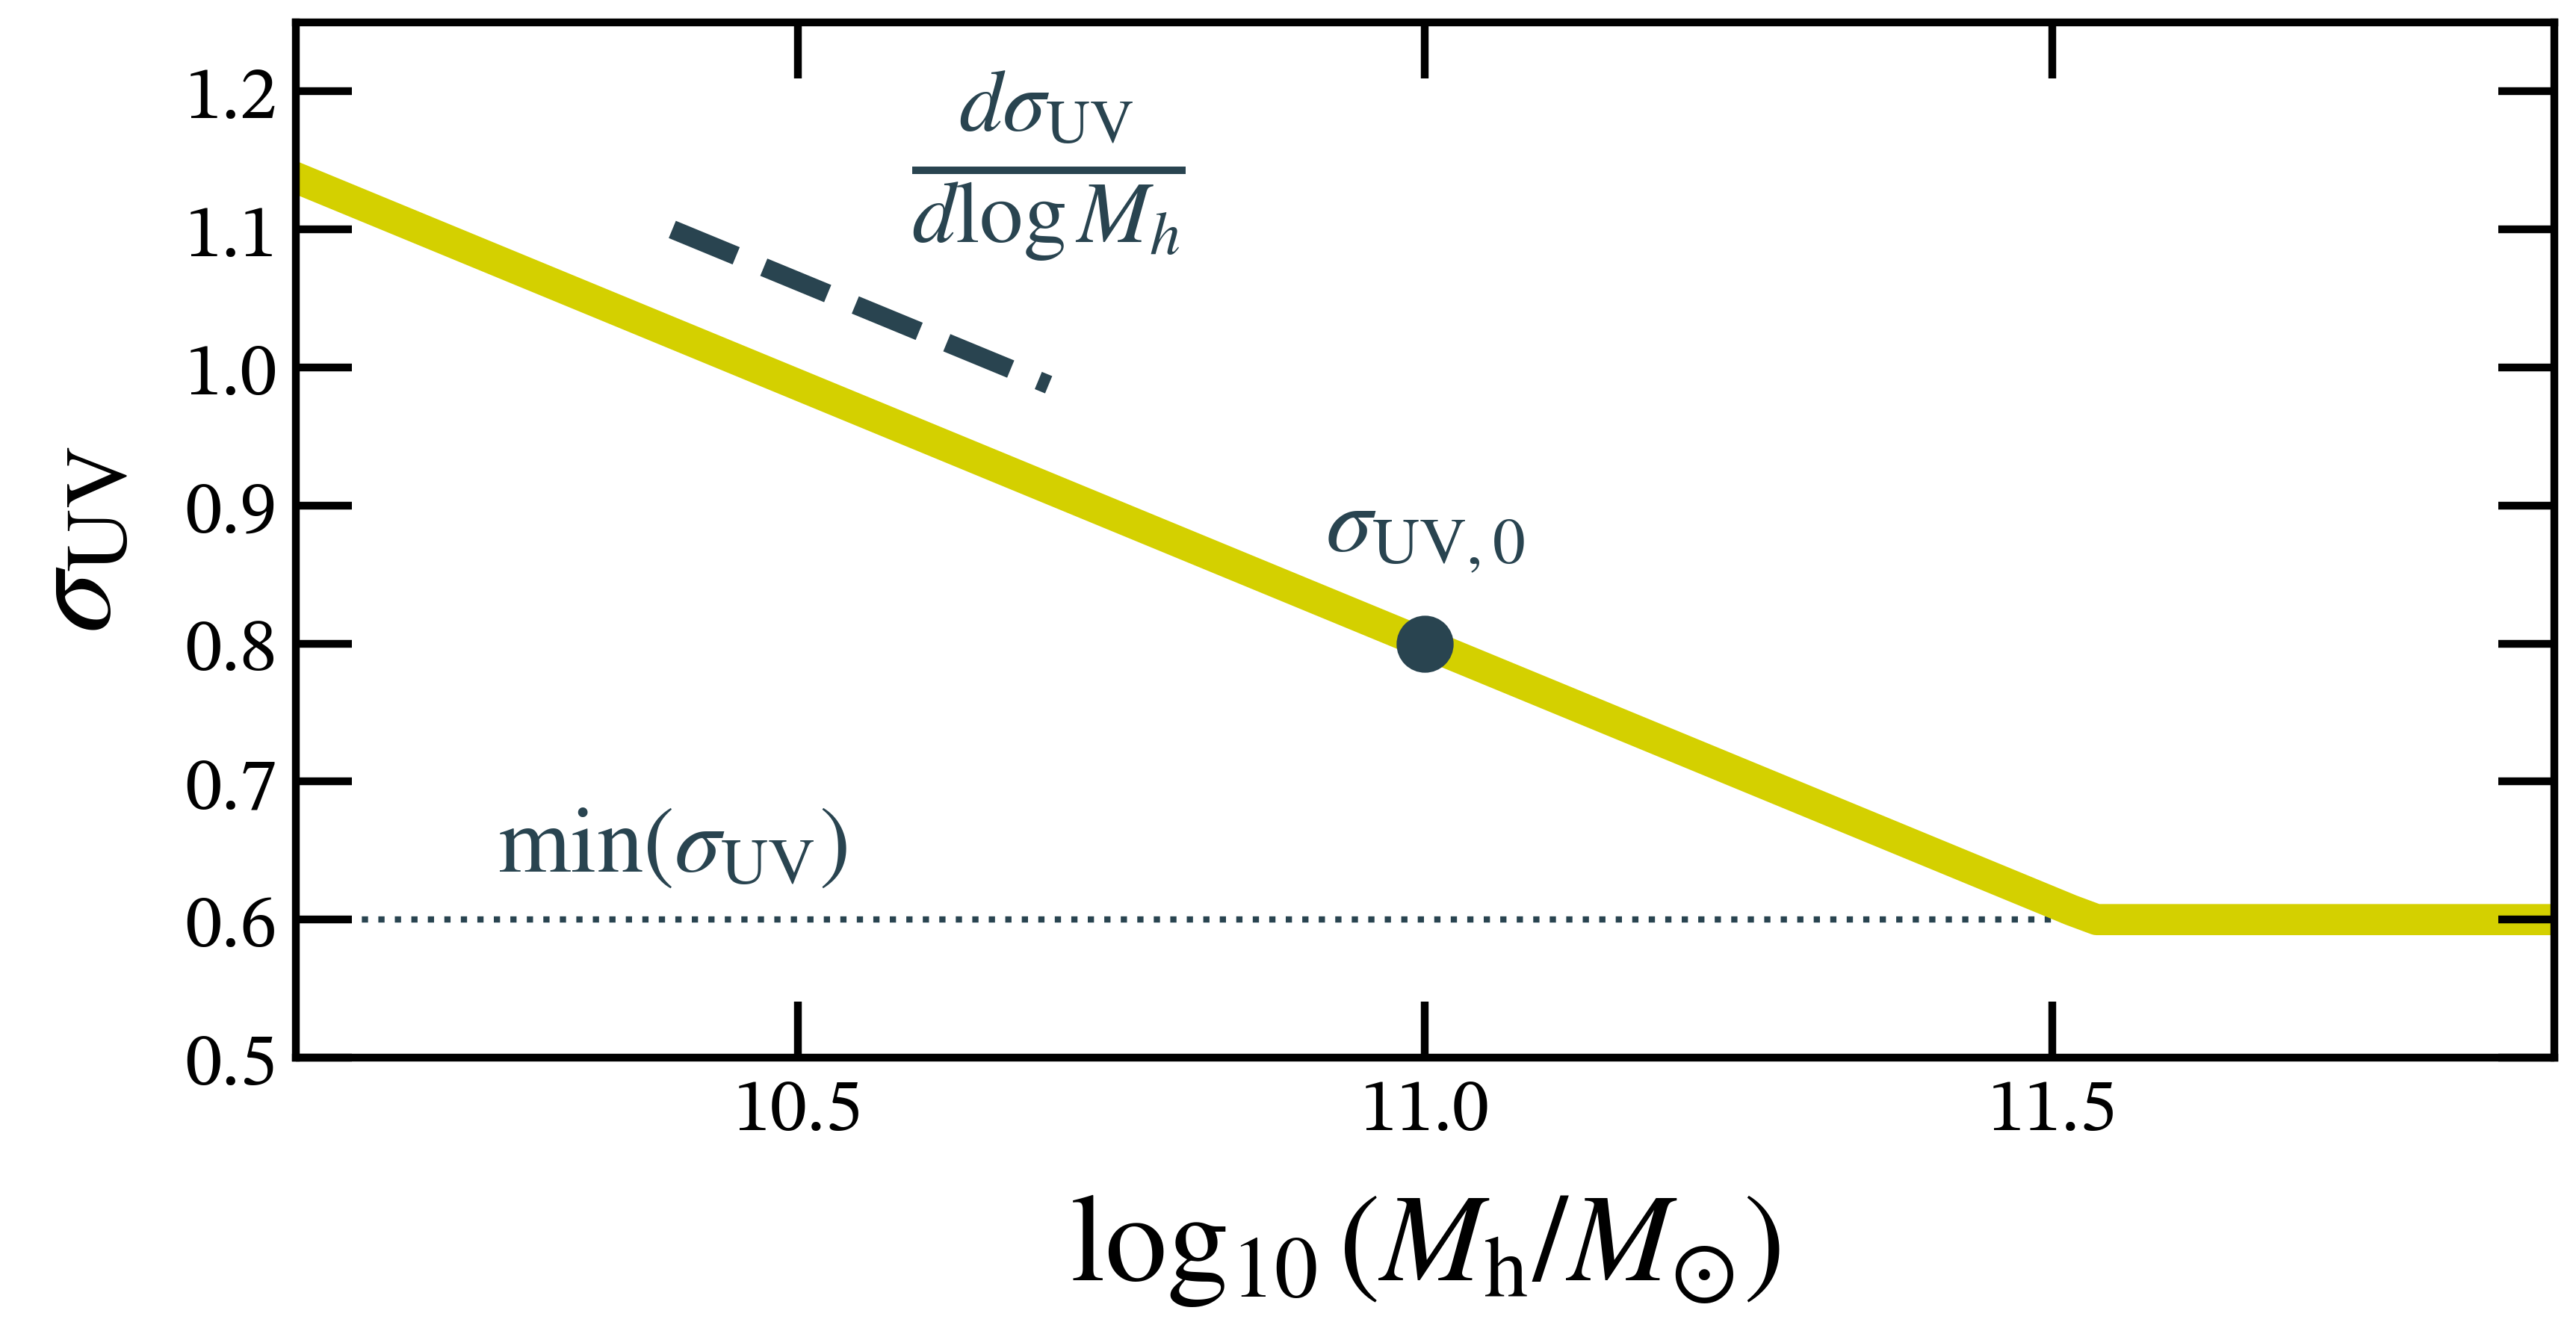

In [523]:
fig, ax = plt.subplots()
fig.set_size_inches(13, 6)
ax.set_ylabel(r'$\sigma_{\rm{UV}}$')
ax.set_xlabel(r'$\log_{10}(M_{\rm{h}}/M_{\odot})$')

sig0 = 0.8
dsigdM = -0.375
min_sig = 0.6

ax.scatter(11, sig0, color = eplots.navy, s= 300, zorder = 2)
# ax.axhline(sig0, color = eplots.navy, lw = 2, ls = 'dotted')
ax.text(11, sig0+0.05, r'$\sigma_{\rm{UV}, 0}$', color = eplots.navy, ha = 'center', va = 'bottom')

M = np.linspace(10, 12, 100)
ax.plot(M, np.clip(sigma(M, sig0, dsigdM), a_min= min_sig, a_max = None), zorder = 1, color = eplots.yellow)
# ax.plot(M, sigma(M, sig0, dsigdM), zorder = 1, color = eplots.yellow)
M_reduced = np.array([10.4, 10.7])
ax.plot(M_reduced, sigma(M_reduced, sig0, dsigdM)+0.075, lw = 6, color = eplots.navy)
ax.text(10.7, 1.075, r'$\frac{d\sigma_{\rm{UV}}}{d\log M_h}$', color = eplots.navy, ha = 'center', va = 'bottom', fontsize = 40)


ax.axhline(min_sig, lw = 2, ls = 'dotted', color = eplots.navy, zorder = 0)
ax.text(10.4, min_sig+0.02, r'$\min(\sigma_{\rm{UV}})$', color = eplots.navy, ha = 'center', va = 'bottom')

ax.set_ylim(0.5, 1.25)
ax.set_xlim(10.1, 11.9)

In [518]:
fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/sigma(Mh)_3.png', dpi = 300)

In [524]:
def sig(z, sig0, dsig):
    return sig0 + dsig*(z-8)

(4.0, 12.5)

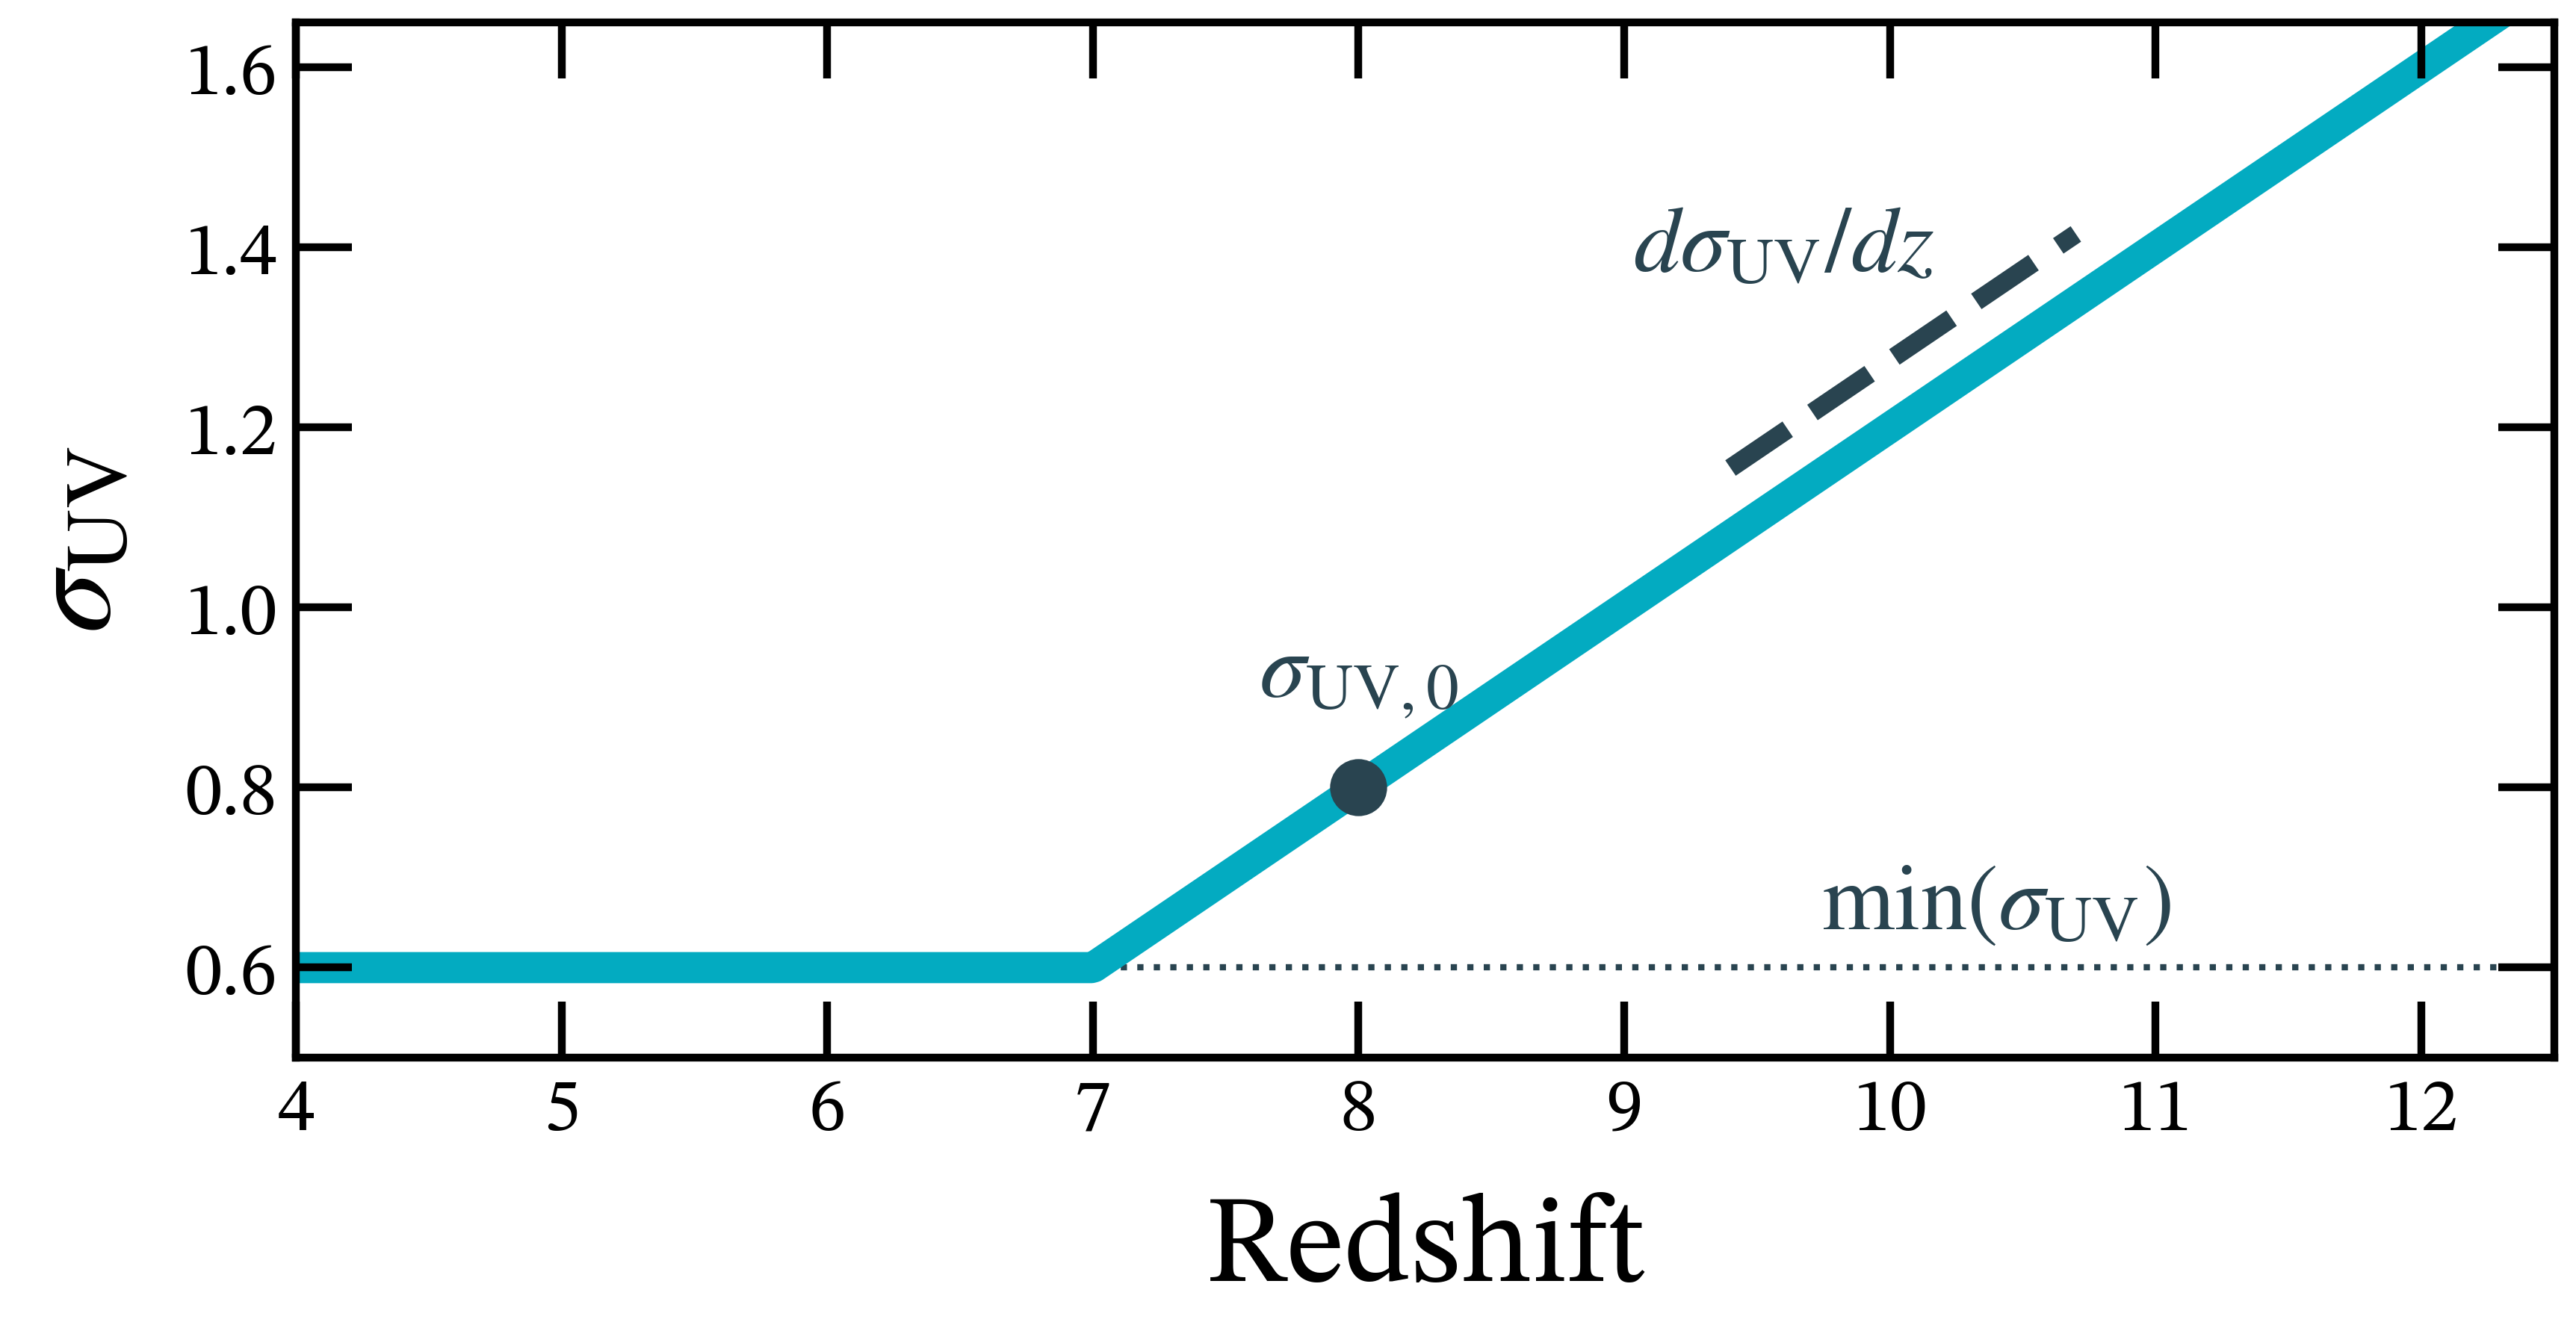

In [558]:
fig, ax = plt.subplots()
fig.set_size_inches(13, 6)
ax.set_ylabel(r'$\sigma_{\rm{UV}}$')
ax.set_xlabel('Redshift')

sig0 = 0.8
dsigdz = 0.2
min_sig = 0.6

ax.scatter(8, sig0, color = eplots.navy, s= 300, zorder = 2)
# ax.axhline(sig0, color = eplots.navy, lw = 2, ls = 'dotted')
ax.text(8, sig0+0.075, r'$\sigma_{\rm{UV}, 0}$', color = eplots.navy, ha = 'center', va = 'bottom')

z = np.linspace(3, 13, 1000)
ax.plot(z, np.clip(sig(z, sig0, dsigdz), a_min = min_sig, a_max = None), zorder = 1, color = eplots.turquoise)
z_reduced = np.array([9.4, 10.7])
ax.plot(z_reduced, sig(z_reduced, sig0, dsigdz)+0.075, lw = 6, color = eplots.navy)
ax.text(9.6, 1.35, r'$d\sigma_{\rm{UV}}/dz$', color = eplots.navy, ha = 'center', va = 'bottom')


ax.axhline(min_sig, lw = 2, ls = 'dotted', color = eplots.navy, zorder = 0)
ax.text(10.4, min_sig+0.02, r'$\min(\sigma_{\rm{UV}})$', color = eplots.navy, ha = 'center', va = 'bottom')

ax.set_ylim(0.5, 1.65)
ax.set_xlim(4, 12.5)

In [ ]:
fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/sigma(z)_3.png', dpi = 300)

In [6]:
FIRE_z8 = np.array([9.201342281879194, 1.4024390243902438,
9.29530201342282, 1.3455284552845526,
9.375838926174497, 1.2723577235772354,
9.536912751677852, 1.215447154471545,
9.604026845637584, 1.2235772357723573,
9.711409395973154, 1.1097560975609753,
9.805369127516778, 0.98780487804878,
9.912751677852349, 1.0040650406504064,
9.993288590604028, 1.0365853658536581,
10.221476510067113, 0.98780487804878,
10.409395973154362, 0.9715447154471546,
10.59731543624161, 0.98780487804878,
10.798657718120804, 0.7520325203252032,
11, 0.5650406504065035,
11.093959731543624, 0.6219512195121952,
11.201342281879194, 0.7601626016260159]).reshape(-1,2)

FIRE_z10 = np.array([9.496644295302012, 1.3048780487804876,
9.577181208053691, 1.1585365853658534,
9.791946308724832, 1.0203252032520327,
10.006711409395972, 1.1829268292682924,
10.181208053691275, 1.0040650406504064,
10.59731543624161, 0.7764227642276422,
10.691275167785236, 0.678861788617886,
10.798657718120804, 0.6056910569105689,
10.919463087248321, 0.6382113821138207,
10.986577181208052, 0.6707317073170733,
11.120805369127517, 0.6626016260162597,
11.201342281879194, 0.630081300813008,
9.402684563758388, 1.434959349593496,
9.281879194630871, 1.5,
9.187919463087248, 1.5325203252032522]).reshape(-1,2)
FIRE_z10=FIRE_z10[np.argsort(FIRE_z10[:,0])]

FIRE_z12=np.array([9.201342281879194, 1.5325203252032522,
9.308724832214764, 1.5162601626016259,
9.389261744966444, 1.3943089430894307,
9.496644295302012, 1.3292682926829267,
9.590604026845638, 1.2967479674796745,
9.765100671140939, 1.142276422764228,
9.939597315436242, 1.0203252032520327,
10.006711409395972, 0.9715447154471546,
10.12751677852349, 0.9796747967479673,
10.194630872483222, 0.98780487804878,
10.315436241610737, 0.9065040650406502,
10.409395973154362, 0.8414634146341466,
10.59731543624161, 0.46747967479674735,
10.78523489932886, 0.296747967479674,
10.892617449664428, 0.16666666666666696]).reshape(-1,2)

In [7]:
line = np.array([8.006711409395972, 1.74390243902439,
12.48993288590604, 0.19918699186991873]).reshape(-1,2)

(['#d4d000', '#6cbe60', '#03abc1'], <Figure size 3600x600 with 1 Axes>)

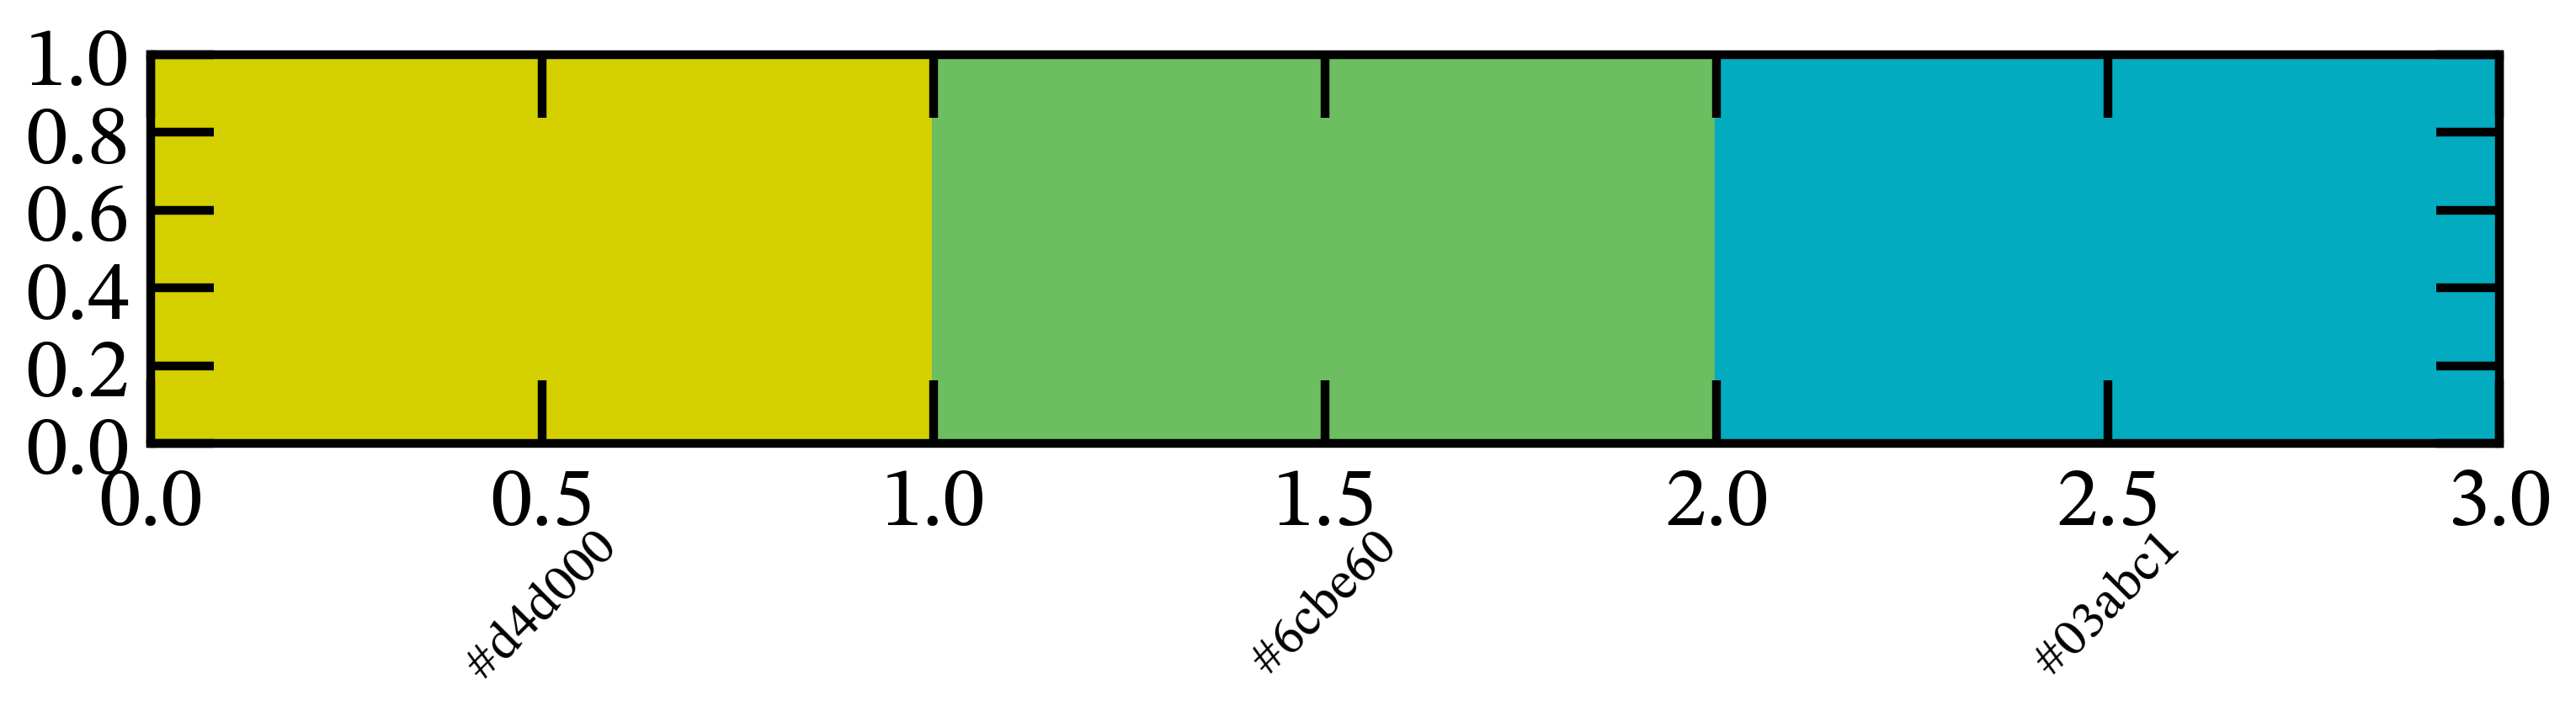

In [10]:
eplots.interpolate_colors([eplots.yellow, eplots.turquoise], 3)

In [38]:
class HandlerStackedLine(HandlerLine2D): # Inherits from the HandlerLine2D class in matplotlib
    """
    Creates multiple horizontal lines to represent a single label in an axis. Initiate with a list of colors you want to include lines for
    """
    def __init__(self, colors, *args, **kwargs):
        self.colors = colors[::-1] # Fix the ordering for the way we plot later
        super().__init__(*args, **kwargs)
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        # Override the typical create_artists function in HandlerLine2D; use this one instead
        return [Line2D([xdescent, xdescent + width], [ydescent + (i-0.3) * 12] * 2, color=self.colors[i], transform=trans)
                for i in range(len(self.colors))]

Text(0.5, 0, '$\\log_{10}(M_{\\rm{h}}/M_{\\odot})$')

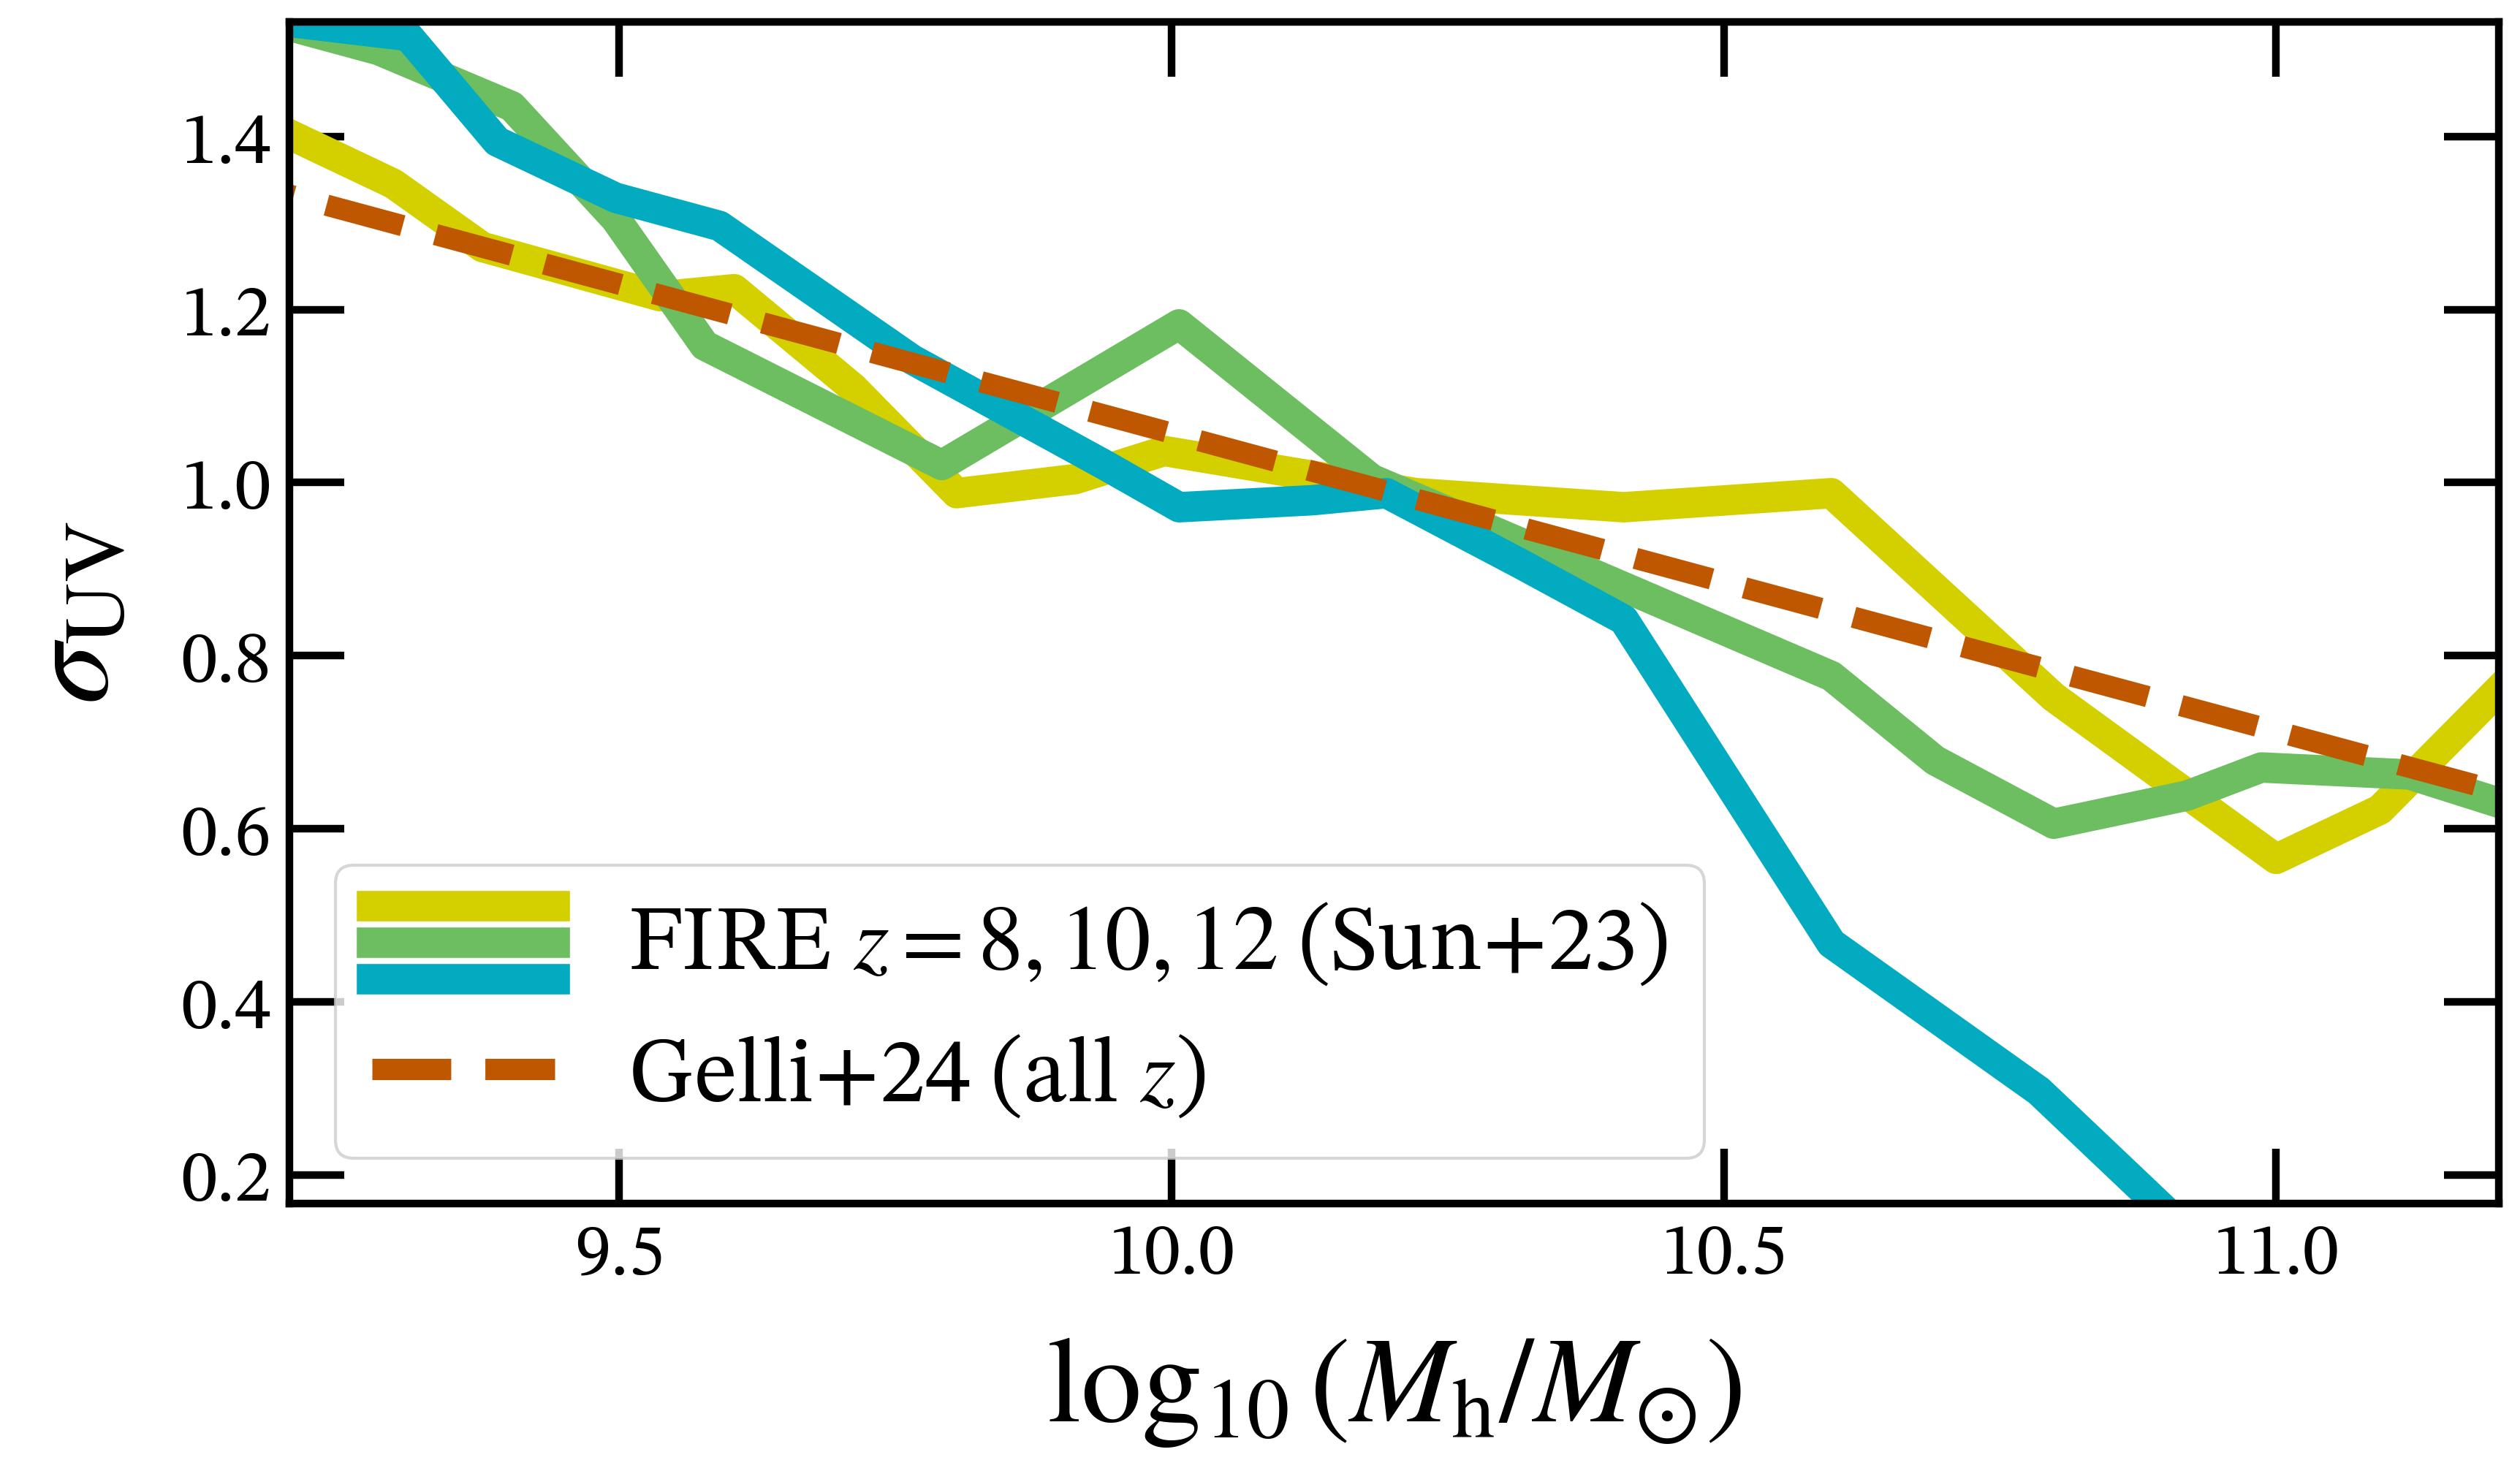

In [61]:
fig, ax = plt.subplots()
fig.set_size_inches(13, 7)
FIRE_colors = [eplots.yellow, '#6cbe60', eplots.turquoise]
Gelli_color = eplots.orange
ax.plot(FIRE_z8[:,0], FIRE_z8[:,1], color=FIRE_colors[0], label = r'FIRE $z=8$', linestyle = '-')
ax.plot(FIRE_z10[:,0], FIRE_z10[:,1], color = FIRE_colors[1], label = r'FIRE $z=10$', linestyle = '-')
ax.plot(FIRE_z12[:,0], FIRE_z12[:,1], color = FIRE_colors[2], label = r'FIRE $z=12$', linestyle = '-')
ax.plot(line[:,0], line[:,1], color = Gelli_color, label = r'Gelli+24 (all $z$)', linestyle = '--', lw = 7)
ax.set_xlim((FIRE_z8[:,0][0], FIRE_z8[:,0][-1]))
ax.set_ylim((FIRE_z12[:,1][-1], FIRE_z12[:,1][0]))

FIRE_lines = Line2D([], [])
Gelli_line = Line2D([0], [0], color=Gelli_color, linestyle = '--', lw = 7)
ax.legend(
    [FIRE_lines, Gelli_line],  # Legend handles
    [r'FIRE $z=8, 10, 12$ (Sun+23)', r'Gelli+24 (all $z$)'], # Corresponding labels
    handler_map={FIRE_lines: HandlerStackedLine(FIRE_colors)},  # Applying custom handler only to Line2D,
    loc = 'lower left'
)

ax.set_ylabel(r'$\sigma_{\rm{UV}}$')
ax.set_xlabel(r'$\log_{10}(M_{\rm{h}}/M_{\odot})$')

In [62]:
fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/mass_depenedence_2.png', dpi = 300)

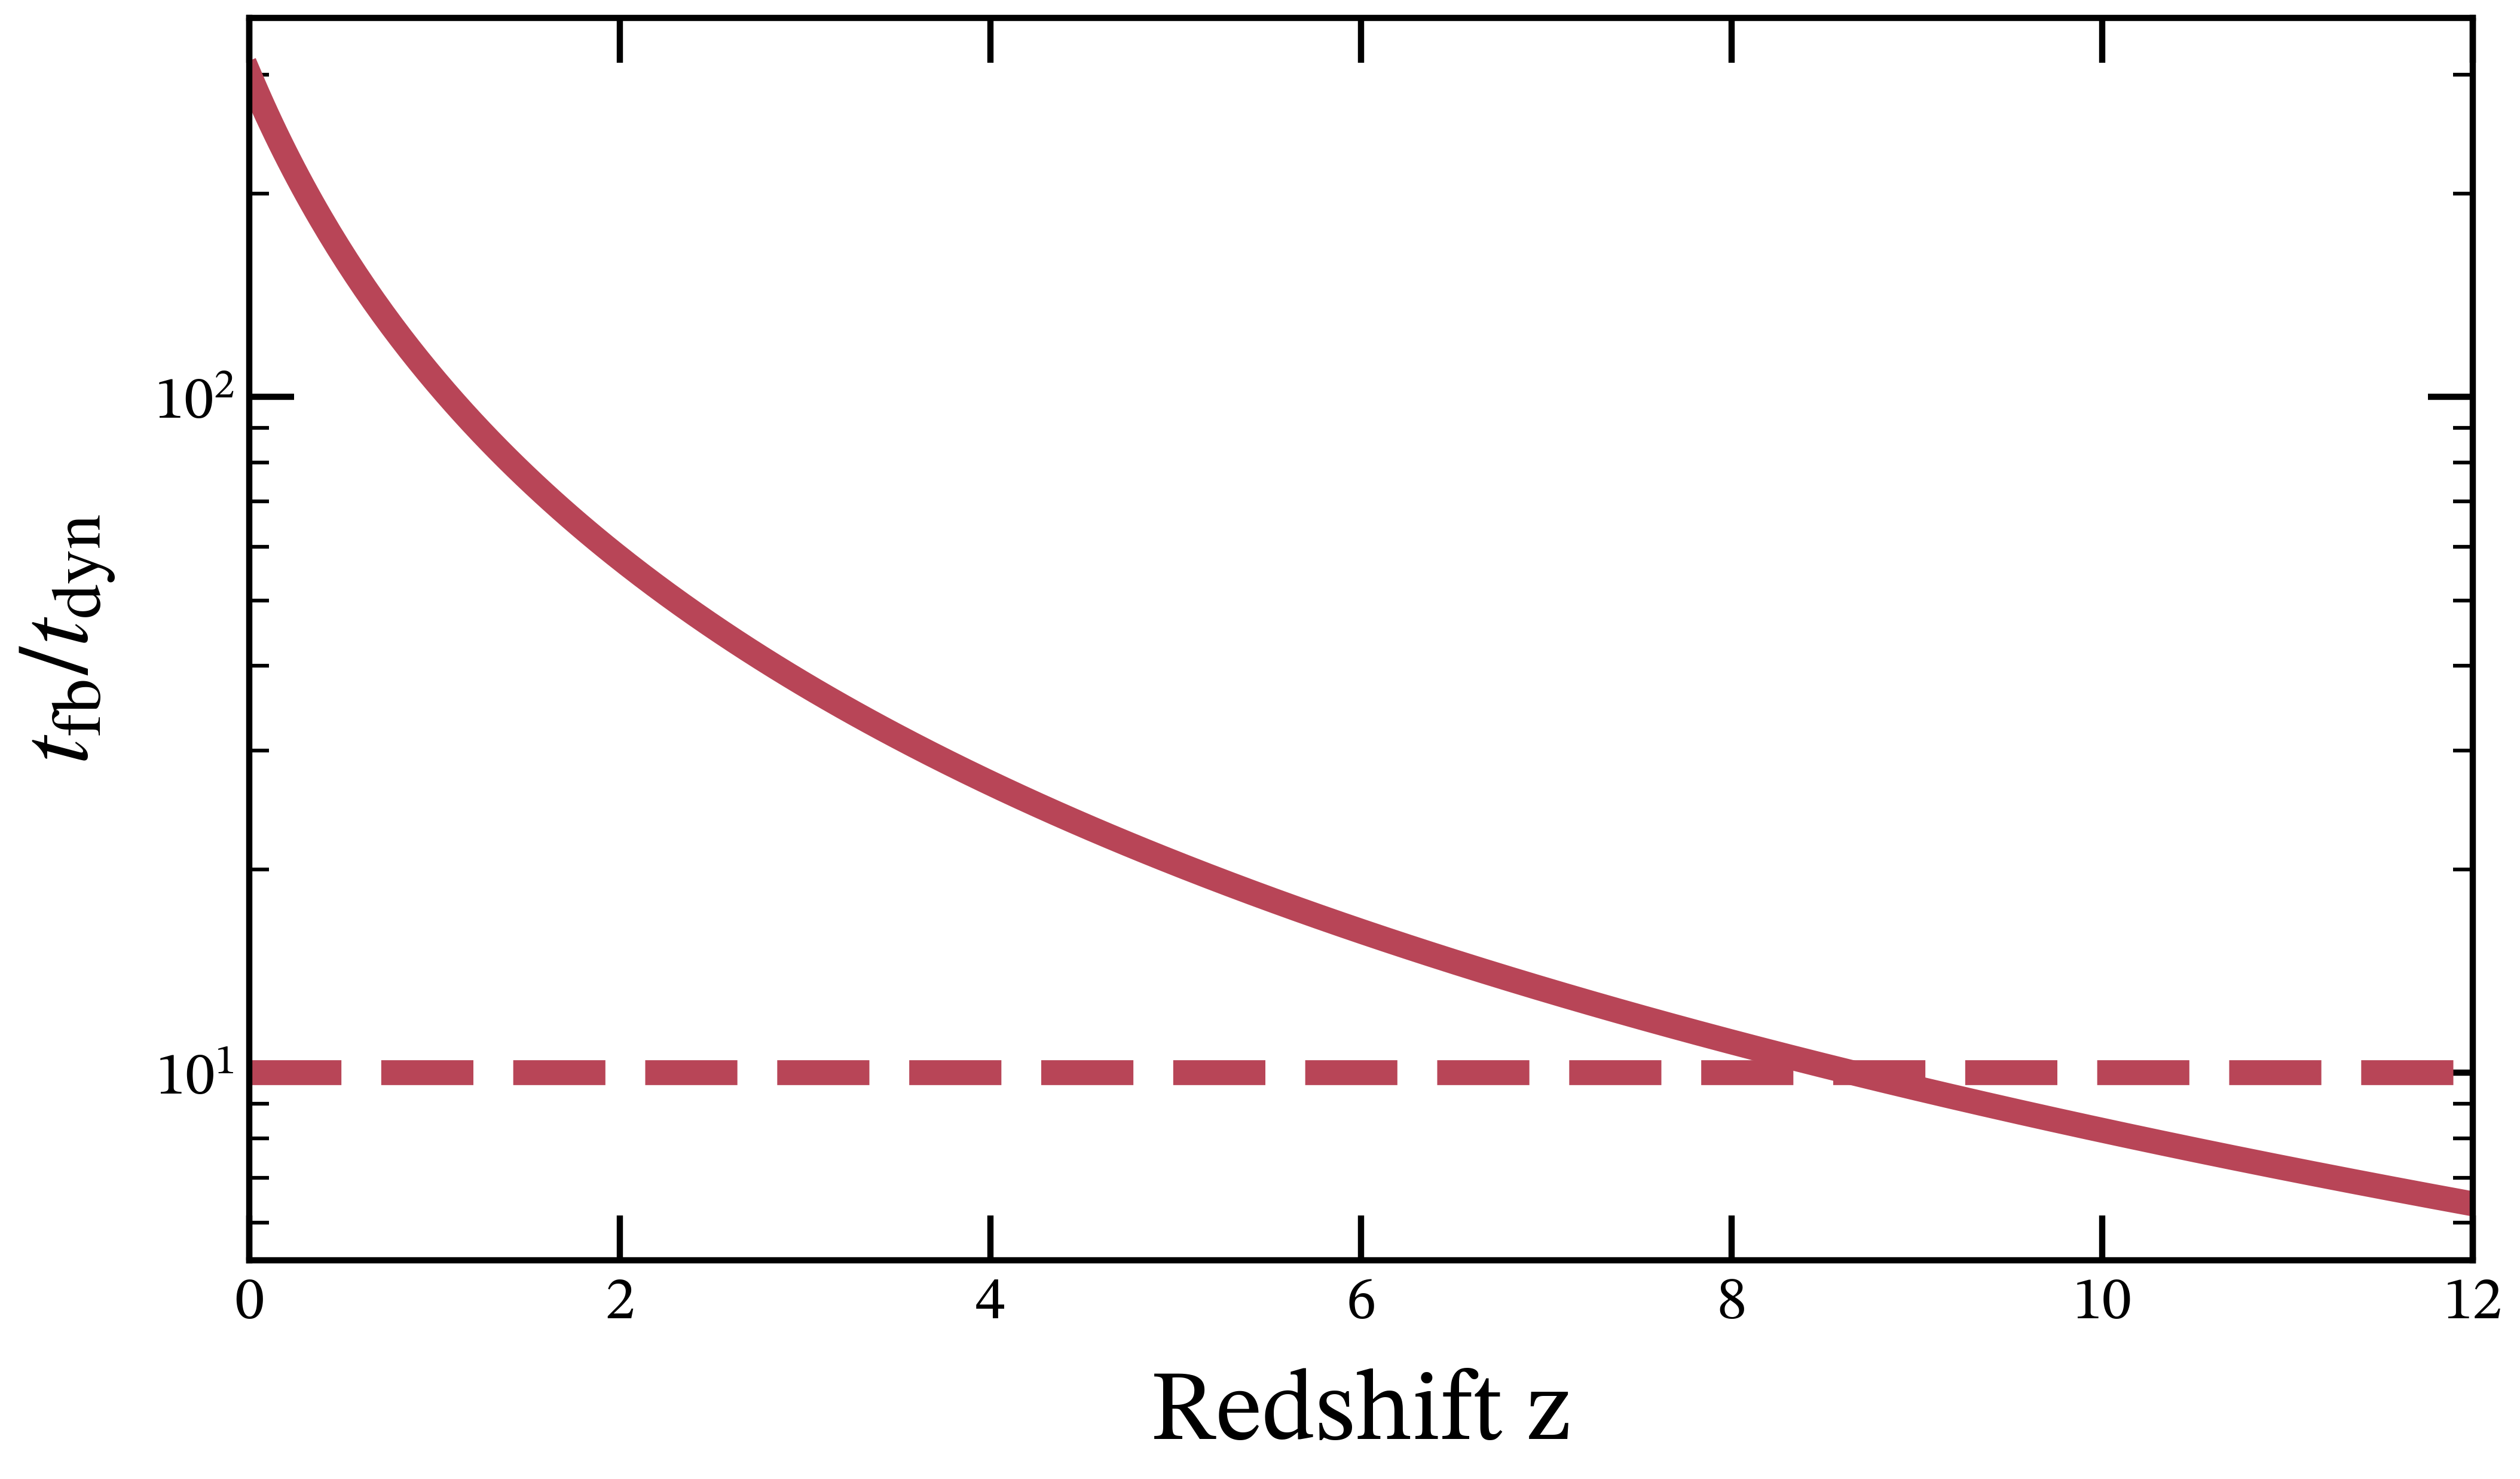

In [287]:
# redshift range
z = np.linspace(0, 12, 500)

# parameters
t_fb = 10.0  # Myr (characteristic feedback delay time)

# normalize t_dyn so that it's ~100 Myr at z=0 (you can tweak this)
t_dyn_z0 = 300.0  # Myr
t_dyn = t_dyn_z0 * (1 + z)**(-3/2)

# ratio

# plot
plt.figure()
plt.plot(z, t_dyn)
plt.axhline(t_fb, linestyle='--')  # transition line

plt.xlabel('Redshift z')
plt.ylabel(r'$t_{\rm fb} / t_{\rm dyn}$')

plt.yscale('log')
plt.xlim(0, 12)

plt.show()